<a href="https://colab.research.google.com/github/Shams200648/CSE303-Research-Paper/blob/main/Retail_Store_Inventory_Forecasting_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas==2.2.2 numpy==1.26.0 tensorflow==2.18.0 tf-keras==2.18.0 numba==0.60 tensorflow-text==2.18.0 pmdarima
# !pip install -upgrade pandas
# !pip install -U numpy
# !pip install -U tensorflow
# !pip install -U tf-keras
# !pip install -U numba
# !pip install -U tensorflow-text
# !pip install -U pmdarima


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.44.0
    Uninstalling llvmlite-0.44.0:
      Successfully uninstalled llvmlite-0.44.0
  Attempting uninstall: numba
    Found existing installation: n

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor




# **Load The dataset**

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "retail_store_inventory.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "anirudhchauhan/retail-store-inventory-forecasting-dataset",
  file_path,
)

print("First 5 records:")
df.head()

<ipython-input-2-68f0bdb30791>:6: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


100%|██████████| 5.90M/5.90M [00:00<00:00, 11.1MB/s]


First 5 records:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

## **Missing Values Check**

In [4]:
missing_values = df.isna().sum()
missing_values_percent = 100 * df.isna().sum()/len(df)
print(missing_values_percent)
print(missing_values)

Date                  0.0
Store ID              0.0
Product ID            0.0
Category              0.0
Region                0.0
Inventory Level       0.0
Units Sold            0.0
Units Ordered         0.0
Demand Forecast       0.0
Price                 0.0
Discount              0.0
Weather Condition     0.0
Holiday/Promotion     0.0
Competitor Pricing    0.0
Seasonality           0.0
dtype: float64
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


<ipython-input-5-557c9a2e8083>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')


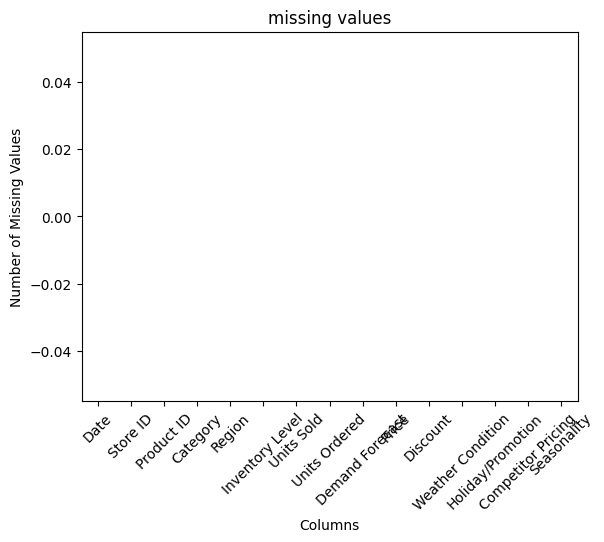

In [5]:
missing_counts = df.isnull().sum()
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')
plt.title("missing values")
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.show()

## **Check and Remove Outliers**

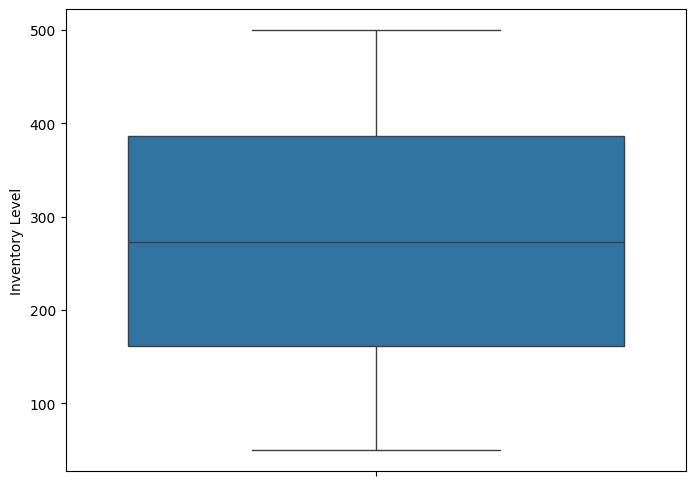

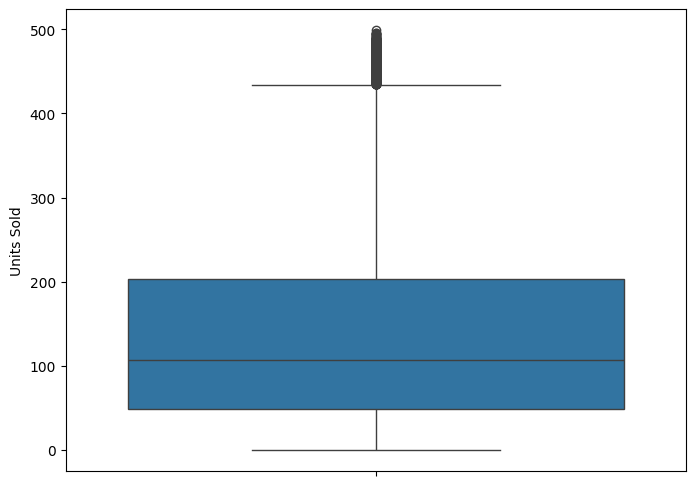

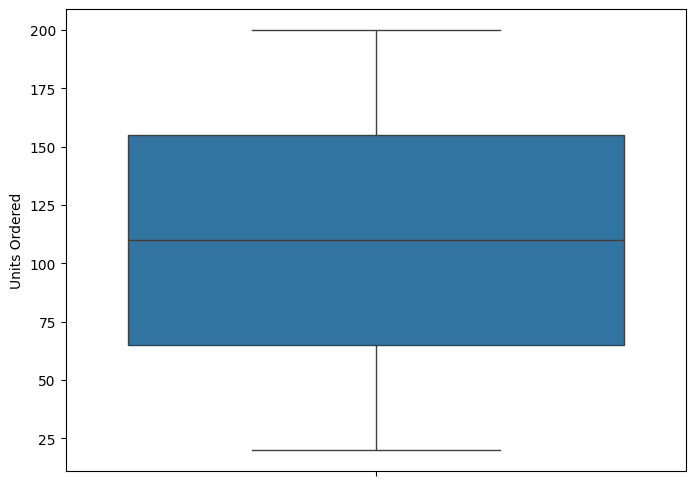

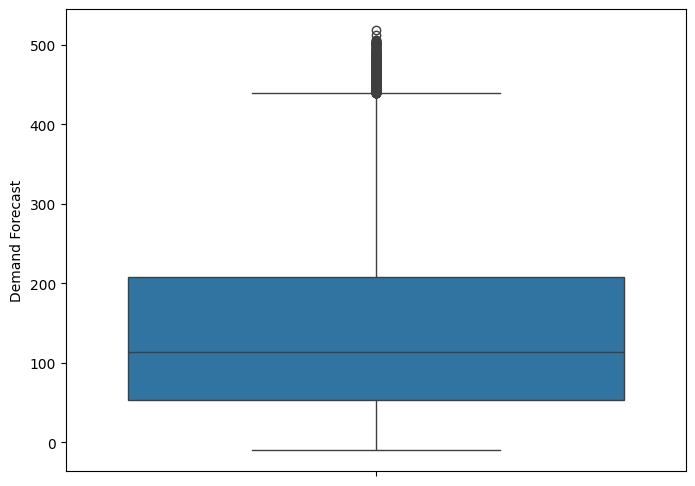

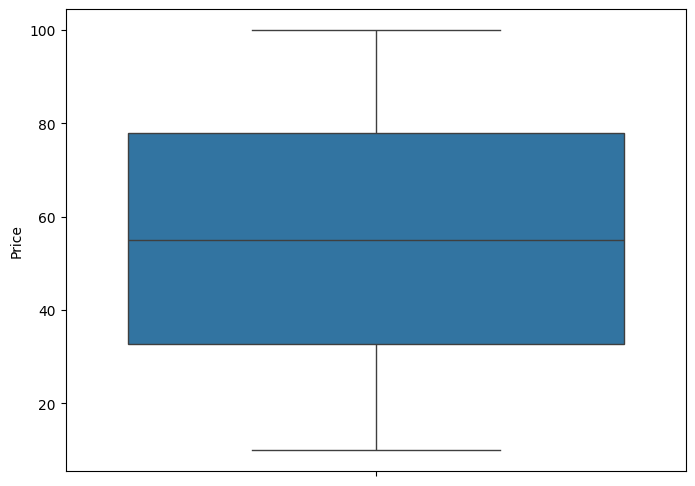

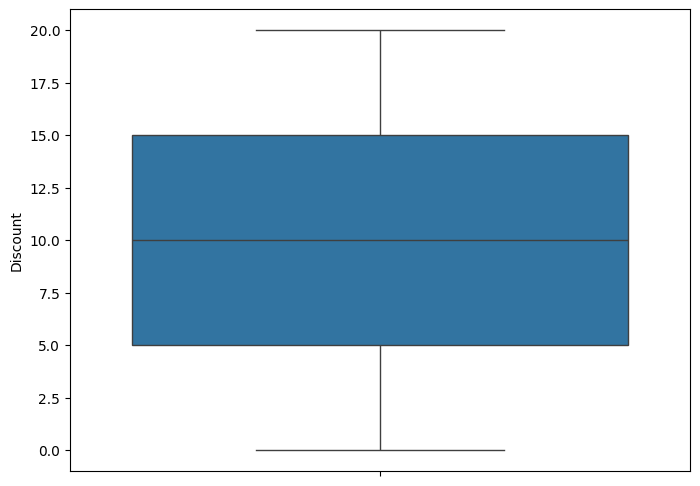

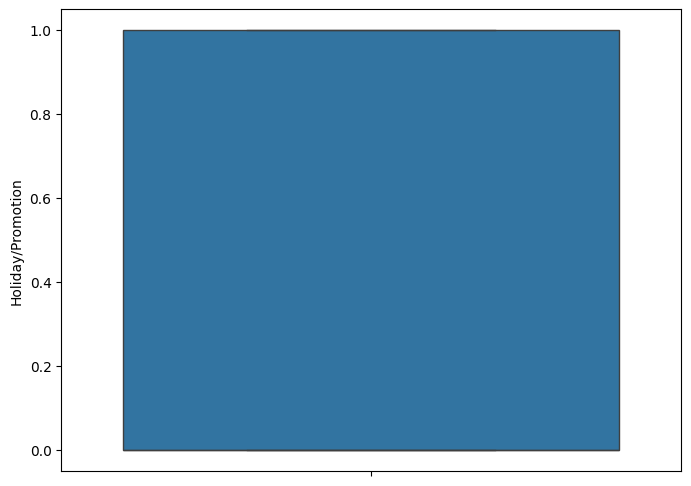

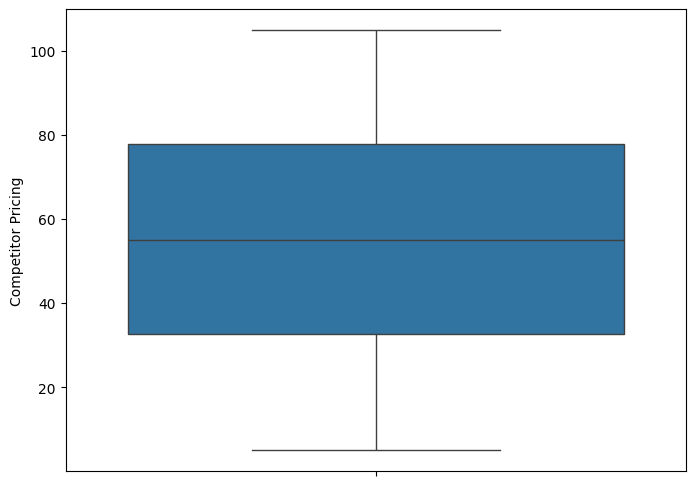

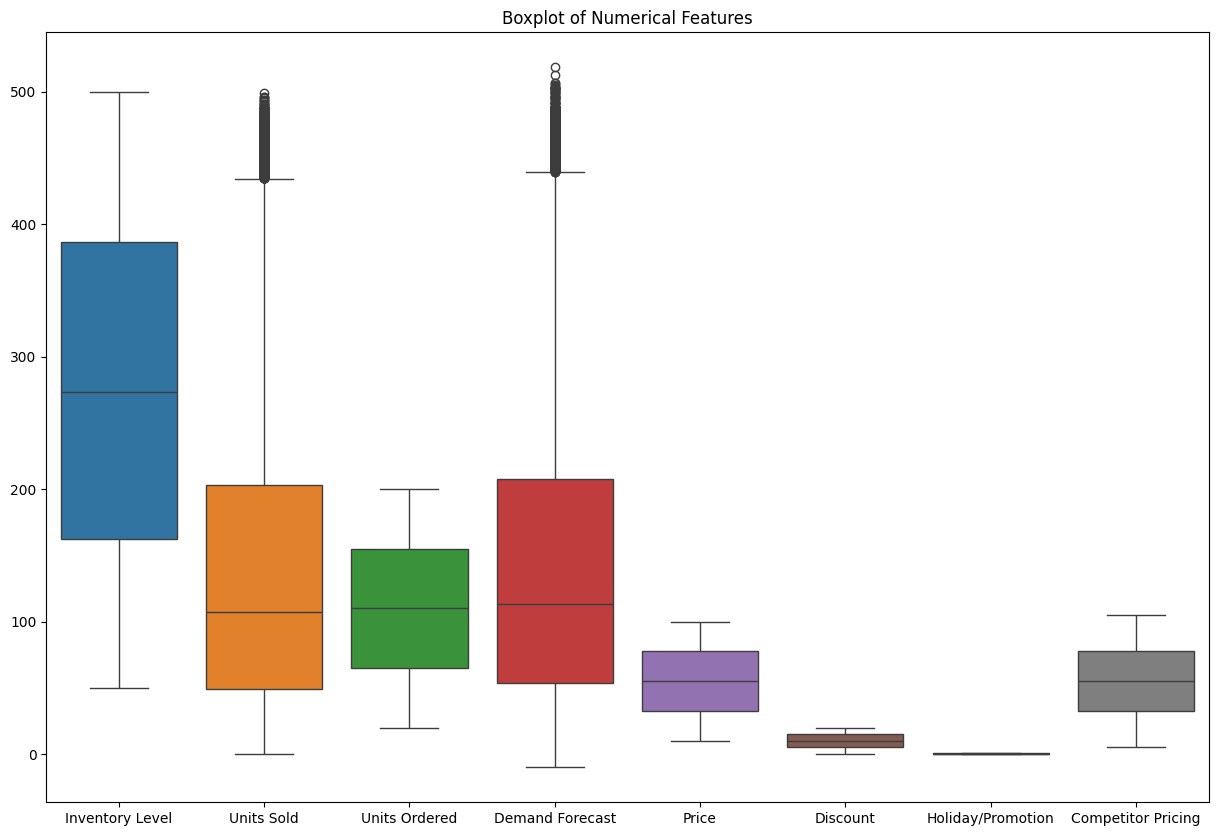

In [6]:
for column in df.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df[column])
    plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.title('Boxplot of Numerical Features')
plt.show()

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Autumn  
1           

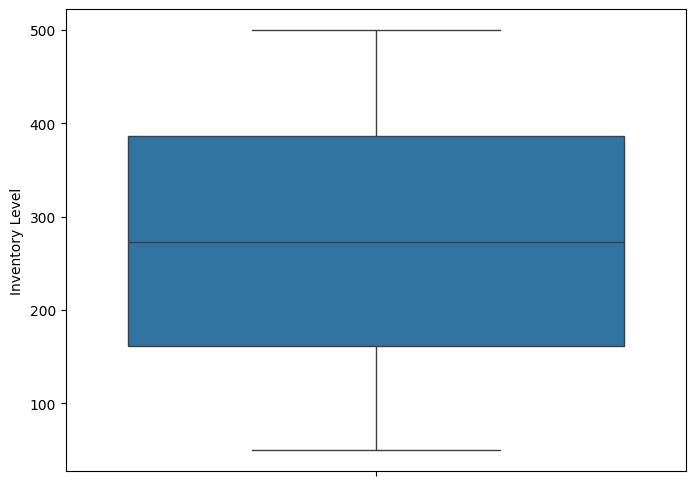

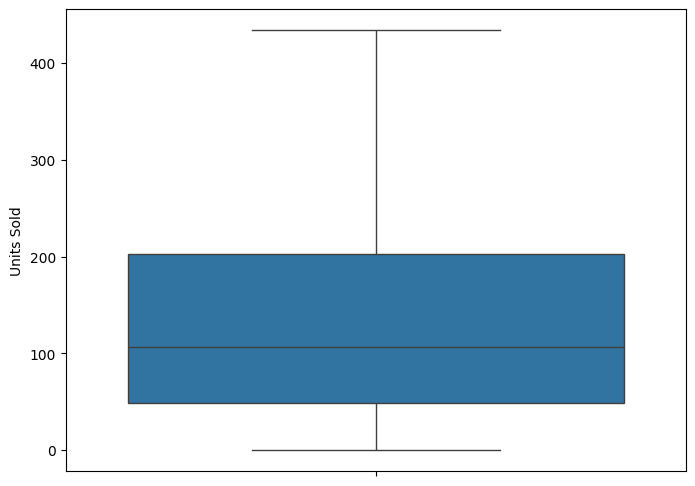

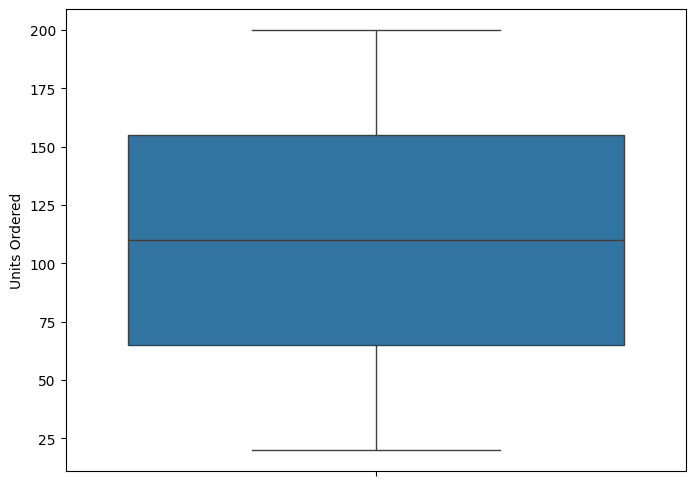

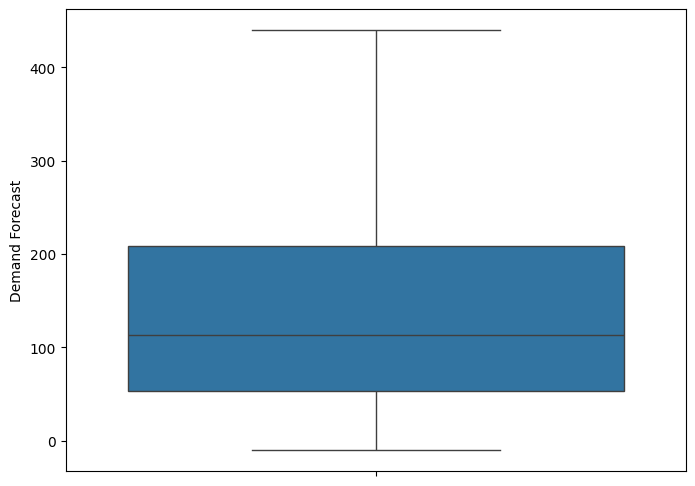

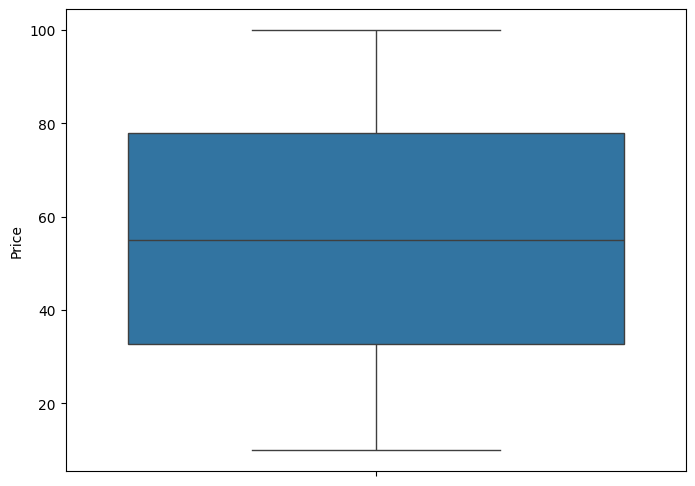

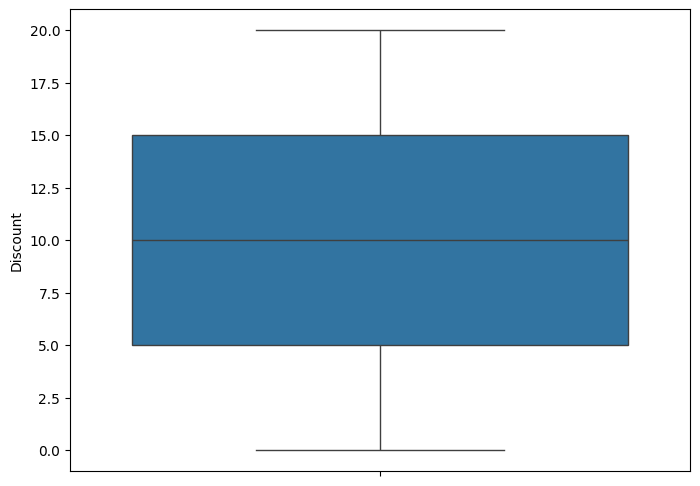

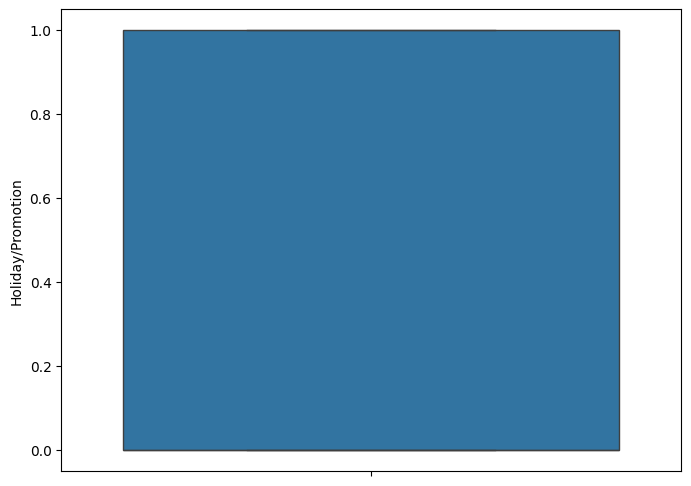

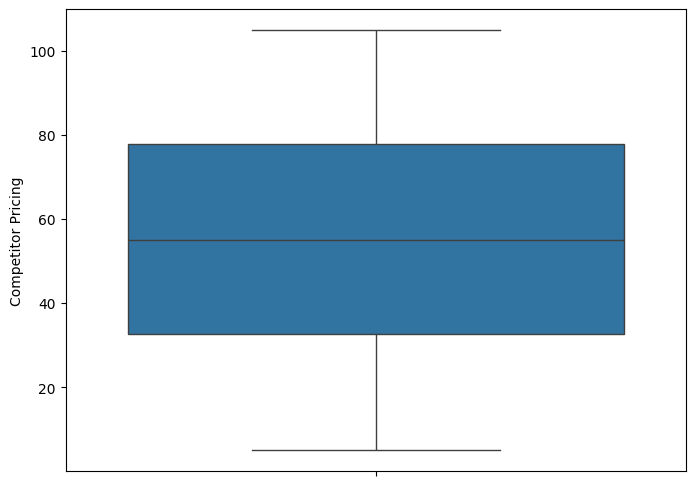

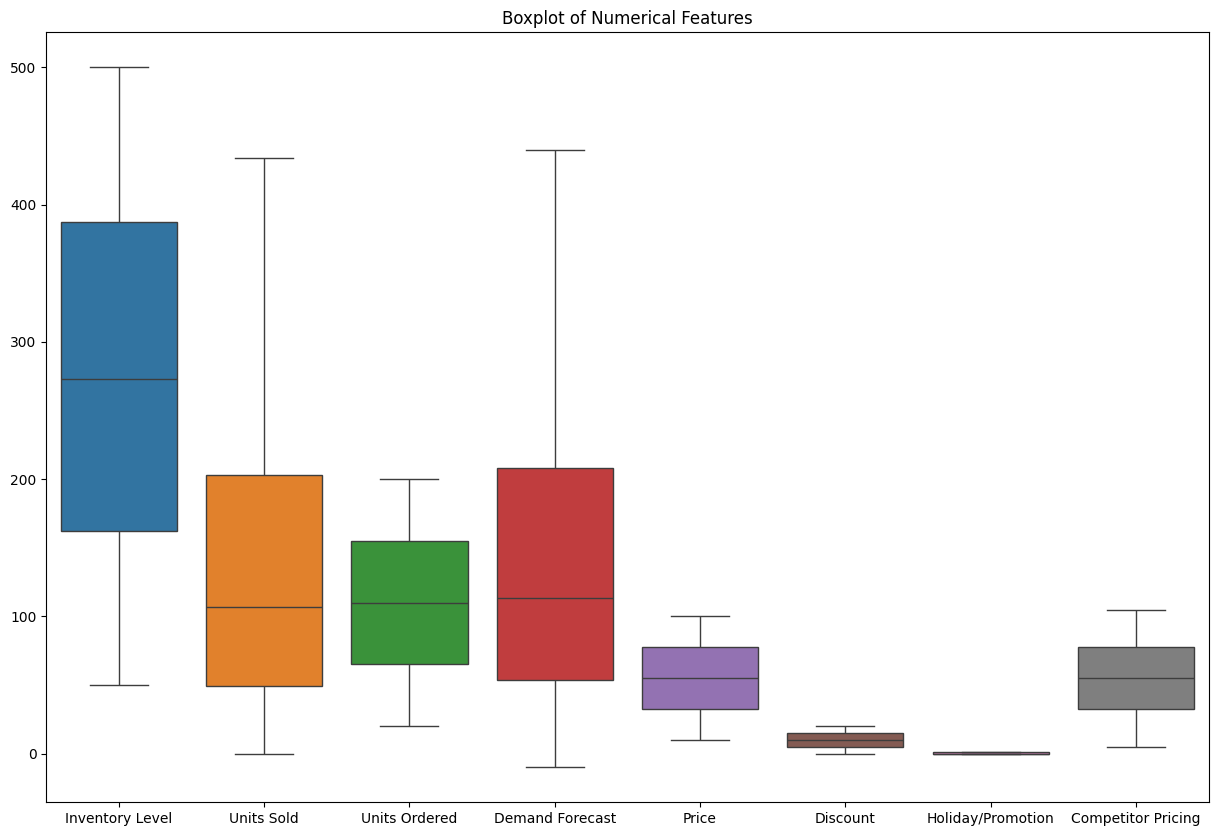

In [7]:
# Function to cap outliers using IQR (Interquartile Range)
def cap_outliers(df, columns):
    for col in columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define the lower and upper bounds for acceptable values
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the bounds to the lower or upper threshold
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df

# List of columns from which to cap outliers
columns_to_cap_outliers = ['Units Sold', 'Demand Forecast']

# Assuming df_rename is your original DataFrame, apply the cap_outliers function
df_capped = cap_outliers(df, columns_to_cap_outliers)

# Display the first few rows of the capped DataFrame
print(df_capped.head())

# Generate individual boxplots for each column after capping outliers
for column in df_capped.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df_capped[column])
    plt.show()

# Generate a combined boxplot for all selected columns after capping outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_capped.select_dtypes(include=['int64','float64']))
plt.title('Boxplot of Numerical Features')
plt.show()


# **Hypothesis Testing**

## **Hypothesis-1**
#### Null Hypothesis (H₀): There is no significant correlation between Inventory Level and Units Sold.
#### Alternative Hypothesis (H₁): There is a significant correlation between Inventory Level and Units Sold.
Method : Pearson Correlation

## **Hypothesis-2**
#### H₀: Demand Forecast does not significantly differ across different regions.
#### H₁: Demand Forecast significantly differs across different regions.
Method : One Way ANOVA test

## **Hypothesis-3**
#### H₀: The effect of Competitor Pricing on Units Sold does not vary across Regions.
#### H₁: The effect of Competitor Pricing on Units Sold varies across Regions.
Method : Two Way ANOVA

## **Hypothesis-4**
#### H₀: The accuracy of Demand Forecast does not improve over time.
#### H₁: The accuracy of Demand Forecast improves over time.
Method : Mean Absolute Error (MAE)

## **Hypothesis-5**
#### H₀: Sales variance is equal across different Stores.
#### H₁: Sales variance differs significantly across Stores.
Method : Levene’s Test

## **Hypothesis-1 (Pearson Correlation)**
H₀ : There is no significant correlation between Inventory Level and Units Sold.

H₁ : There is a significant correlation between Inventory Level and Units Sold.


In [8]:
!pip install scipy
import scipy.stats as stats

# Select the two columns
inventory = df_capped["Inventory Level"]
units_sold = df_capped["Units Sold"]

# Perform Pearson correlation test
correlation, p_value = stats.pearsonr(inventory, units_sold)

# Print results
print(f"Pearson Correlation Coefficient: {correlation}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Reject H₀: Significant correlation exists.")
else:
    print("Fail to reject H₀: No significant correlation.")

Pearson Correlation Coefficient: 0.5901899467262203
P-value: 0.0
Reject H₀: Significant correlation exists.


## **Hypothesis-2 (ANOVA test)**
H₀: Demand Forecast does not significantly differ across different regions.

H₁: Demand Forecast significantly differs across different regions.


In [9]:
from scipy.stats import f_oneway

# Group Demand Forecast by Region
regions = df_capped["Region"].unique()  # Get all unique regions
demand_forecast_groups = [df_capped[df_capped["Region"] == region]["Demand Forecast"] for region in regions]

# Perform ANOVA Test
f_stat, p_value = f_oneway(*demand_forecast_groups)

# Print results
print(f"F-Statistic: {f_stat}")
print(f"P-value: {p_value}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject H₀: Demand Forecast significantly differs across different regions.")
else:
    print("Fail to reject H₀: No significant difference in Demand Forecast across regions.")

F-Statistic: 0.6014816277995594
P-value: 0.6139703158996084
Fail to reject H₀: No significant difference in Demand Forecast across regions.


## **Hypothesis-3 (Two Way ANOVA)**
H₀: The effect of Competitor Pricing on Units Sold does not vary across Regions.

H₁: The effect of Competitor Pricing on Units Sold varies across Regions.

In [10]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_capped.columns = df_capped.columns.str.replace(' ', '_')

# Define the dependent and independent variables
dependent_var = 'Units_Sold'  # Replace with your dependent variable column name
factor1 = 'Region'    # Replace with your first factor column name
factor2 = 'Competitor_Pricing'  # Replace with your second factor column name

# # Ensure the factors are treated as categorical variables
df_capped.tail(1000)[factor1] = df_capped[factor1].astype('category')
# df_capped[factor2] = df_capped[factor2].astype('category')  # Use 'category' instead of 'object'

# Construct the Two-Way ANOVA formula dynamically
formula = f'{dependent_var} ~ C({factor1}) + C({factor2}) + C({factor1}):C({factor2})'

# Fit the model
model = smf.ols(formula, data=df_capped.tail(1000)).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
# Print ANOVA table
print(anova_table)

# Get the p-value for the interaction effect (Region × Competitor Pricing)
interaction_p_value = anova_table.loc[f"C({factor1}):C({factor2})", "PR(>F)"]

# Interpretation
alpha = 0.05  # Significance level
if interaction_p_value < alpha:
    print("Reject H₀: Competitor Pricing affects Units Sold differently across Regions.")
else:
    print("Fail to reject H₀: No significant difference in how Competitor Pricing affects Units Sold across Regions.")

print(interaction_p_value)
df_capped.columns = df_capped.columns.str.replace('_', ' ')

<ipython-input-10-b11ca78369fd>:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_capped.tail(1000)[factor1] = df_capped[factor1].astype('category')
<ipython-input-10-b11ca78369fd>:13: SettingWithCopyWarning: 
A value is trying to be set 

                                       sum_sq      df         F    PR(>F)
C(Region)                        3.565358e+04     3.0  0.502087  0.493328
C(Competitor_Pricing)            1.413143e+07   959.0  0.622536  0.895474
C(Region):C(Competitor_Pricing)  2.876685e+07  2877.0  0.422425  0.992950
Residual                         2.603730e+05    11.0       NaN       NaN
Fail to reject H₀: No significant difference in how Competitor Pricing affects Units Sold across Regions.
0.9929497947058482


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2877, but rank is 768
  warnings.warn('covariance of constraints does not have full '


## **Hypothesis-4 (MAE)**
H₀: The accuracy of Demand Forecast does not improve over time.

H₁: The accuracy of Demand Forecast improves over time.


In [11]:
from sklearn.metrics import mean_absolute_error

# Sort data by Date
df_capped["Date"] = pd.to_datetime(df_capped["Date"])
df_capped = df_capped.sort_values("Date")

# Calculate MAE for the first and last 6 months
first_half = df_capped[df_capped["Date"] < df_capped["Date"].median()]
second_half = df_capped[df_capped["Date"] >= df_capped["Date"].median()]

mae_first = mean_absolute_error(first_half["Units Sold"], first_half["Demand Forecast"])
mae_second = mean_absolute_error(second_half["Units Sold"], second_half["Demand Forecast"])

# Print results
print(f"MAE (First Half): {mae_first}")
print(f"MAE (Second Half): {mae_second}")

# Interpretation
if mae_second < mae_first:
    print("Reject H₀: Forecast accuracy has improved over time.")
else:
    print("Fail to reject H₀: No significant improvement in forecast accuracy.")


MAE (First Half): 8.289878150684931
MAE (Second Half): 8.322941325136613
Fail to reject H₀: No significant improvement in forecast accuracy.


## **Hypothesis-5 ( Levene’s Test)**
H₀: Sales variance is equal across different Stores.

H₁: Sales variance differs significantly across Stores.


In [12]:
from scipy.stats import levene

# Group sales data by store
stores = df_capped.groupby("Store ID")["Units Sold"].apply(list)

# Perform Levene’s test
stat, p_value = levene(*stores)

# Print results
print(f"Levene’s Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("Reject H₀: Sales variance differs significantly across Stores.")
else:
    print("Fail to reject H₀: Sales variance is equal across Stores.")


Levene’s Test Statistic: 1.6337800926686756
P-value: 0.16260354213686695
Fail to reject H₀: Sales variance is equal across Stores.


In [13]:
df_capped.head(30)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,0,Sunny,0,63.92,Autumn
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,5,Rainy,1,18.56,Spring
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,0,Sunny,1,57.76,Spring
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,0,37.15,Summer
68,2022-01-01,S004,P0009,Furniture,North,63,40,73,51.78,59.23,10,Rainy,1,61.10,Summer
67,2022-01-01,S004,P0008,Furniture,South,250,51,137,54.98,85.88,20,Snowy,1,86.14,Winter
66,2022-01-01,S004,P0007,Electronics,West,264,190,139,197.45,67.26,20,Cloudy,0,64.78,Summer
65,2022-01-01,S004,P0006,Electronics,East,470,382,195,396.40,41.35,10,Snowy,0,39.86,Summer
64,2022-01-01,S004,P0005,Groceries,North,397,200,172,196.57,81.72,0,Snowy,1,85.22,Spring


## **Making copies for each Challange**

In [14]:
df_capped_2 = df_capped.copy()    #copy for 2nd challange
df_capped_3 = df_capped.copy()    #copy for 3rd challange
df_capped_4 = df_capped.copy()    #copy for Unsupervised Learning

# **Challange 1. Time Series Demand Forecasting**

1.  Feature Engineering
2.  Null values Fillup, Outliers Removal
3.  Scaling the numerical values
4.  Label Encoding Categorical values
5.  Train Test Split
6.  Model Train

*    Hybrid (ARIMA + LSTM)


## 1. Feature Engineering

In [ ]:
!pip install shap lime prophet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

In [ ]:
# Convert Date column to datetime format & sort by time
df_capped["Date"] = pd.to_datetime(df_capped["Date"])
df = df_capped.sort_values(by=["Store ID", "Product ID", "Date"])

# ------------------ Step 2: Feature Engineering ------------------

# Time-based features
df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

# Lag Features (Past Sales Data)
df["sales_lag_1"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(1)
df["sales_lag_7"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(7)
df["sales_lag_30"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].shift(30)

# Rolling Window Features (Trends)
df["sales_ma_7"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].transform(lambda x: x.rolling(7).mean())
df["sales_ma_30"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].transform(lambda x: x.rolling(30).mean())
df["sales_rolling_std_7"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].transform(lambda x: x.rolling(7).std())
df["sales_rolling_std_30"] = df.groupby(["Store ID", "Product ID"])["Units Sold"].transform(lambda x: x.rolling(30).std())

# External Features
df["discount_percentage"] = df["Discount"] / df["Price"]
df["competitor_price_diff"] = df["Competitor Pricing"] - df["Price"]


df["sales_lag_1"].fillna(0, inplace=True)
df["sales_lag_7"].fillna(0, inplace=True)
df["sales_lag_30"].fillna(0, inplace=True)

df["sales_ma_7"].fillna(0, inplace=True)
df["sales_ma_30"].fillna(0, inplace=True)
df["sales_rolling_std_7"].fillna(0, inplace=True)
df["sales_rolling_std_30"].fillna(0, inplace=True)

df["discount_percentage"] = np.where(df["Price"] == 0, 0, df["Discount"] / df["Price"])



<ipython-input-17-83a4bc19e9b1>:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sales_lag_1"].fillna(0, inplace=True)
<ipython-input-17-83a4bc19e9b1>:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [ ]:
df.head(30)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,is_weekend,sales_lag_1,sales_lag_7,sales_lag_30,sales_ma_7,sales_ma_30,sales_rolling_std_7,sales_rolling_std_30,discount_percentage,competitor_price_diff
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,...,1,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.597015,-3.81
100,2022-01-02,S001,P0001,Groceries,West,116,81,104,92.94,27.95,...,1,127.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.357782,2.94
200,2022-01-03,S001,P0001,Electronics,West,154,5,189,5.36,62.70,...,0,81.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.318979,-4.48
300,2022-01-04,S001,P0001,Groceries,South,85,58,193,52.87,77.88,...,0,5.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.192604,-1.89
400,2022-01-05,S001,P0001,Groceries,South,238,147,37,150.27,28.46,...,0,58.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.702741,0.94
500,2022-01-06,S001,P0001,Electronics,East,198,37,155,39.09,91.05,...,0,147.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.054915,-3.75
600,2022-01-07,S001,P0001,Furniture,North,195,107,106,117.92,53.99,...,0,37.0,0.0,0.0,80.285714,0.000000,50.638307,0.000000,0.185219,4.81
700,2022-01-08,S001,P0001,Furniture,East,231,2,119,0.84,66.30,...,1,107.0,127.0,0.0,62.428571,0.000000,53.384945,0.000000,0.301659,-2.48
800,2022-01-09,S001,P0001,Electronics,South,373,350,178,352.24,41.72,...,1,2.0,81.0,0.0,100.857143,0.000000,121.870736,0.000000,0.000000,-3.04
900,2022-01-10,S001,P0001,Electronics,West,327,36,132,39.50,32.68,...,0,350.0,5.0,0.0,105.285714,0.000000,118.318376,0.000000,0.152999,2.03


## 2. Null values Fillup, Outliers Removal


*   Finding Missing Values
*   Filling the missing values
*   Detect Outliers
*   Remove Outliers



In [ ]:
missing_values = df.isna().sum()
missing_values_percent = 100 * df.isna().sum()/len(df)
print(missing_values_percent)
print(missing_values)

Date                     0.0
Store ID                 0.0
Product ID               0.0
Category                 0.0
Region                   0.0
Inventory Level          0.0
Units Sold               0.0
Units Ordered            0.0
Demand Forecast          0.0
Price                    0.0
Discount                 0.0
Weather Condition        0.0
Holiday/Promotion        0.0
Competitor Pricing       0.0
Seasonality              0.0
day_of_week              0.0
month                    0.0
week_of_year             0.0
is_weekend               0.0
sales_lag_1              0.0
sales_lag_7              0.0
sales_lag_30             0.0
sales_ma_7               0.0
sales_ma_30              0.0
sales_rolling_std_7      0.0
sales_rolling_std_30     0.0
discount_percentage      0.0
competitor_price_diff    0.0
dtype: float64
Date                     0
Store ID                 0
Product ID               0
Category                 0
Region                   0
Inventory Level          0
Units Sold 

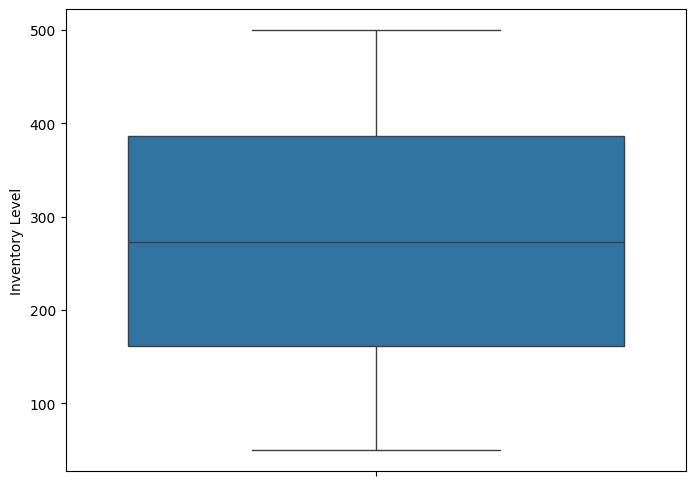

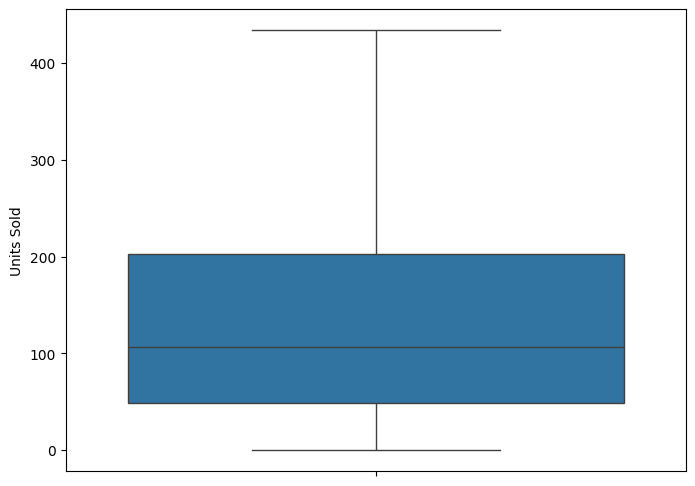

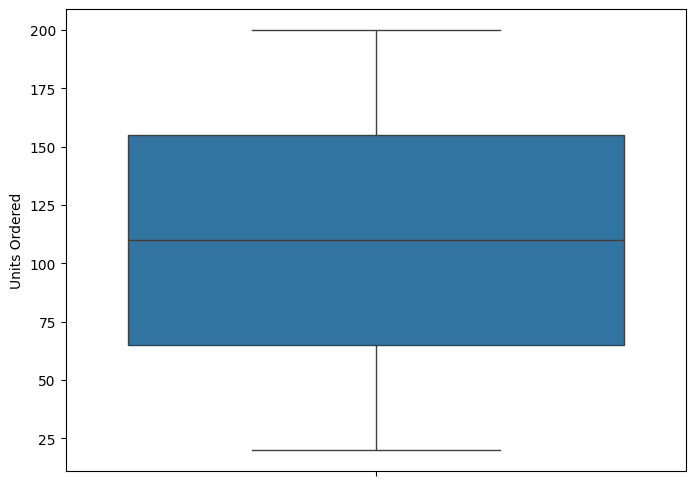

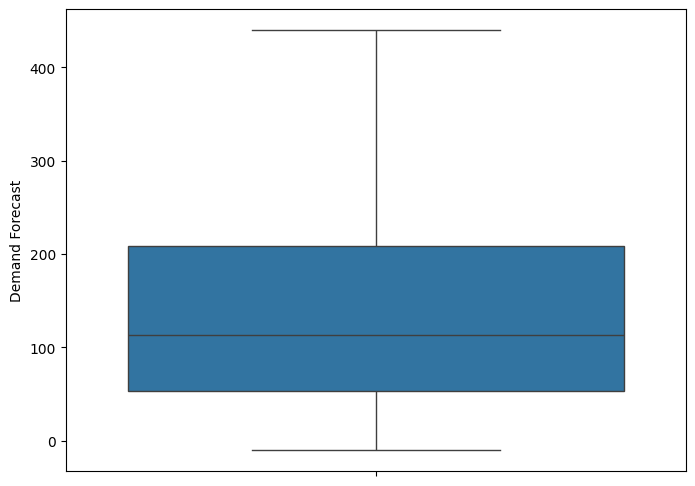

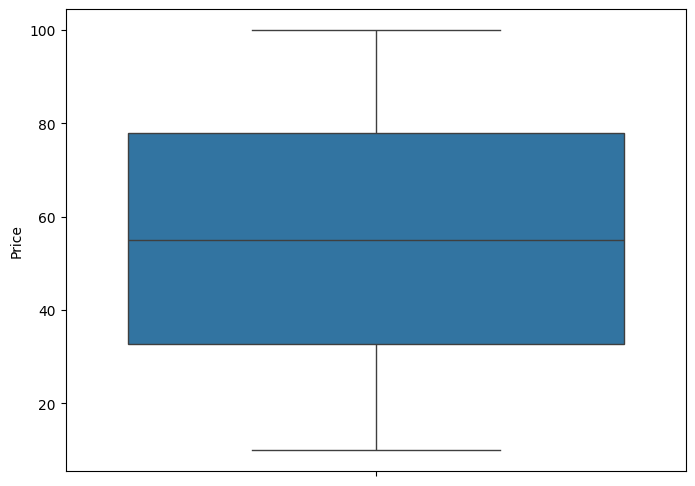

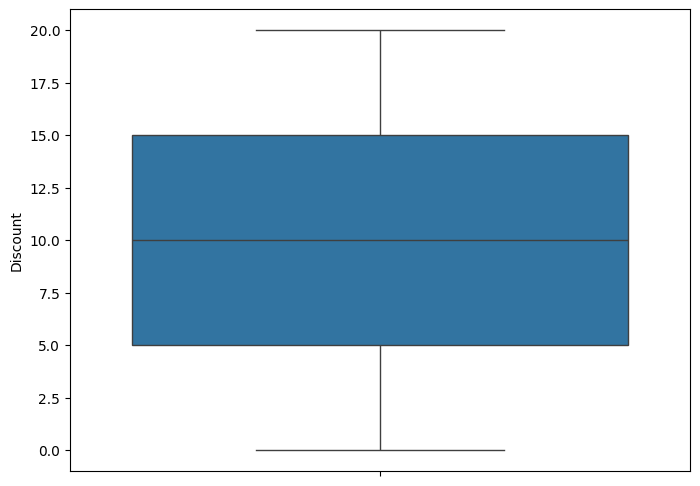

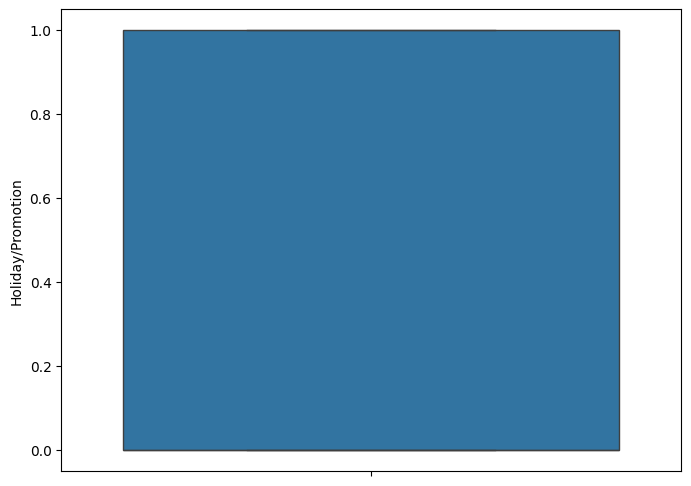

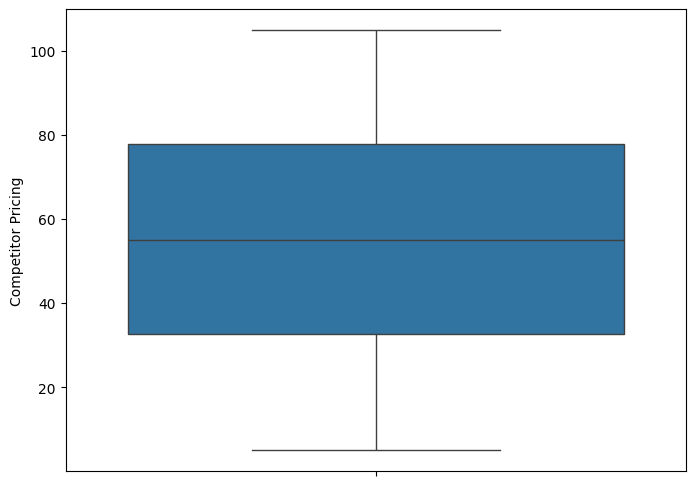

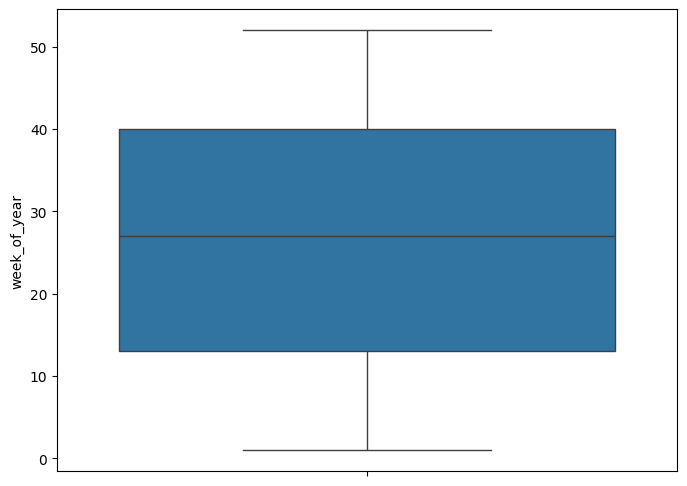

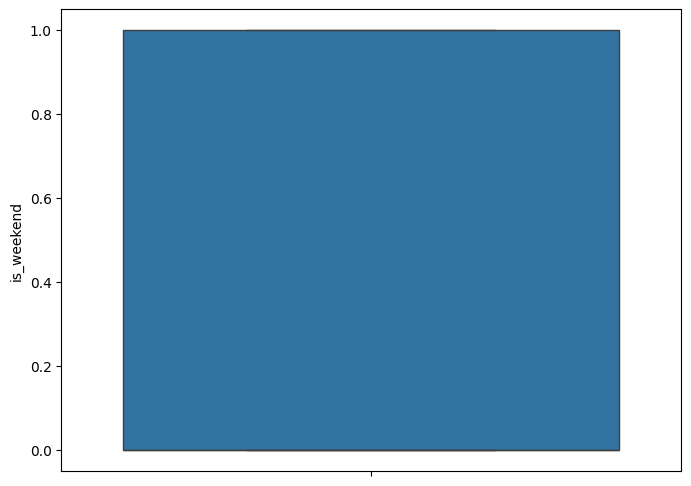

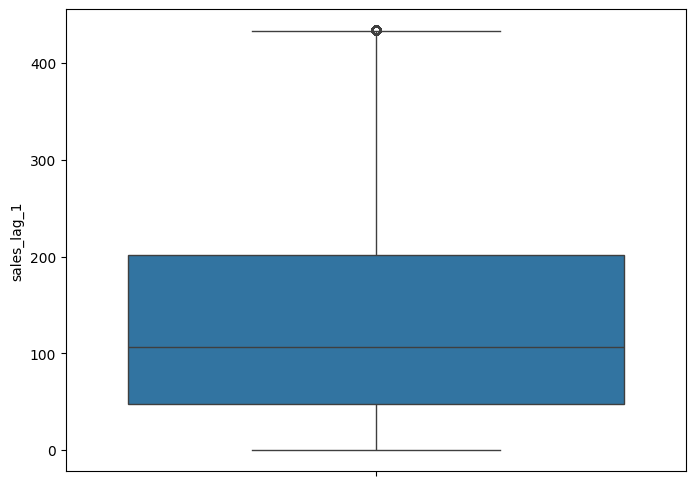

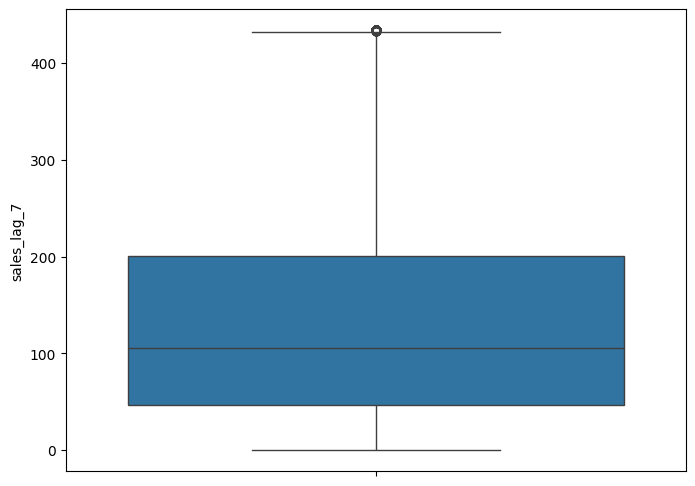

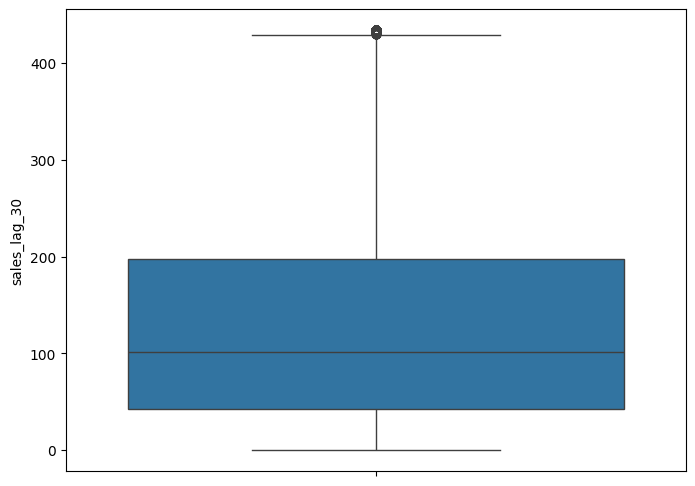

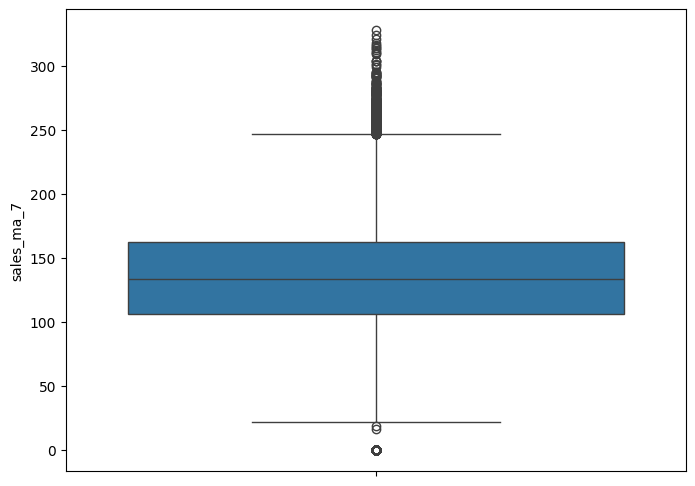

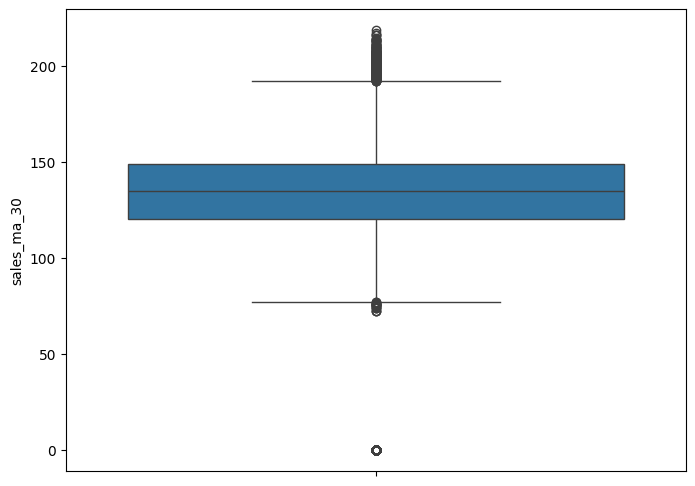

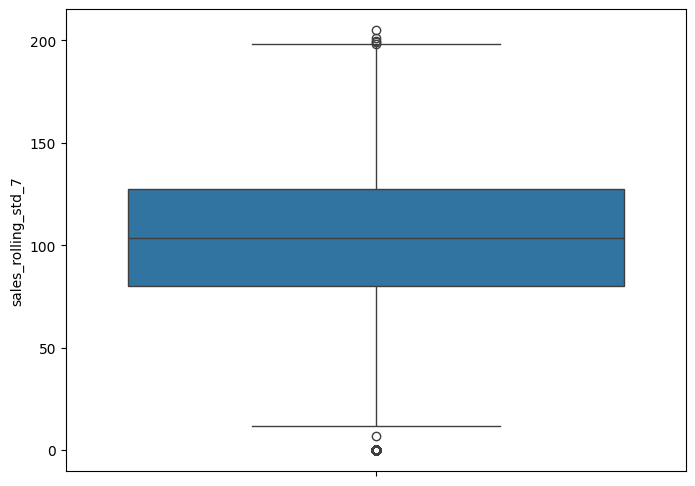

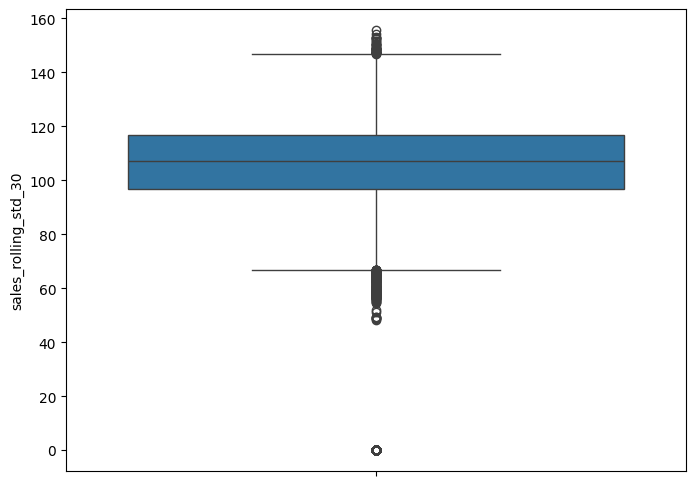

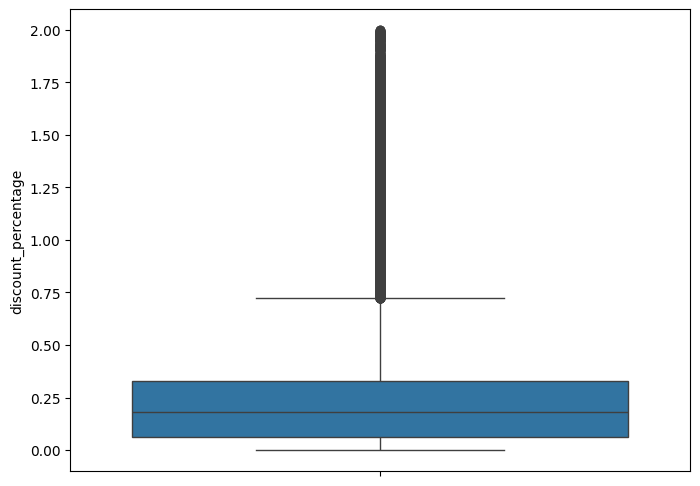

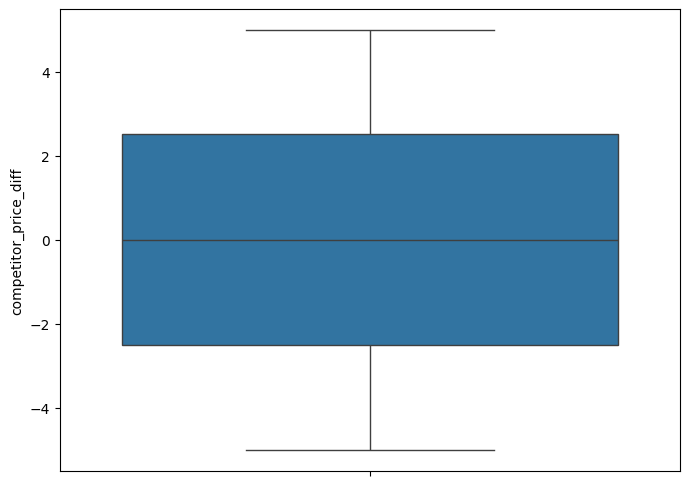

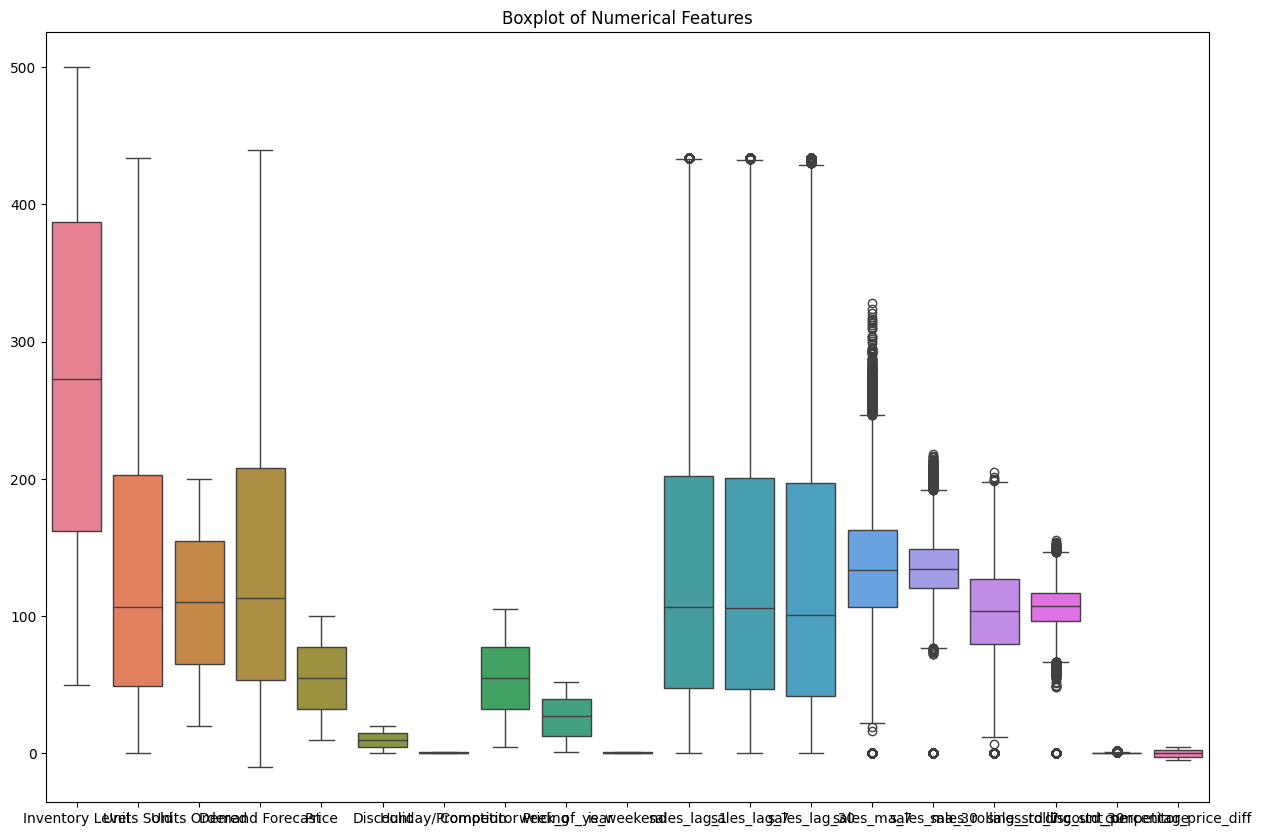

In [ ]:
for column in df.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df[column])
    plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.title('Boxplot of Numerical Features')
plt.show()

          Date Store ID Product ID     Category Region  Inventory Level  \
0   2022-01-01     S001      P0001    Groceries  North              231   
100 2022-01-02     S001      P0001    Groceries   West              116   
200 2022-01-03     S001      P0001  Electronics   West              154   
300 2022-01-04     S001      P0001    Groceries  South               85   
400 2022-01-05     S001      P0001    Groceries  South              238   

     Units Sold  Units Ordered  Demand Forecast  Price  ...  is_weekend  \
0           127             55           135.47  33.50  ...           1   
100          81            104            92.94  27.95  ...           1   
200           5            189             5.36  62.70  ...           0   
300          58            193            52.87  77.88  ...           0   
400         147             37           150.27  28.46  ...           0   

    sales_lag_1  sales_lag_7  sales_lag_30 sales_ma_7  sales_ma_30  \
0           0.0          0.0

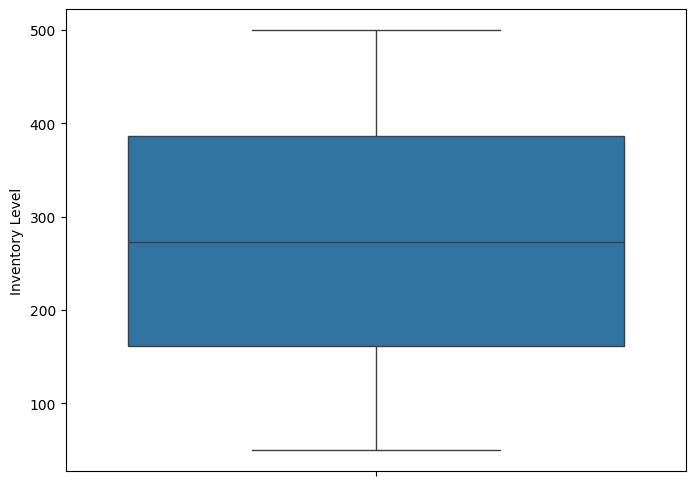

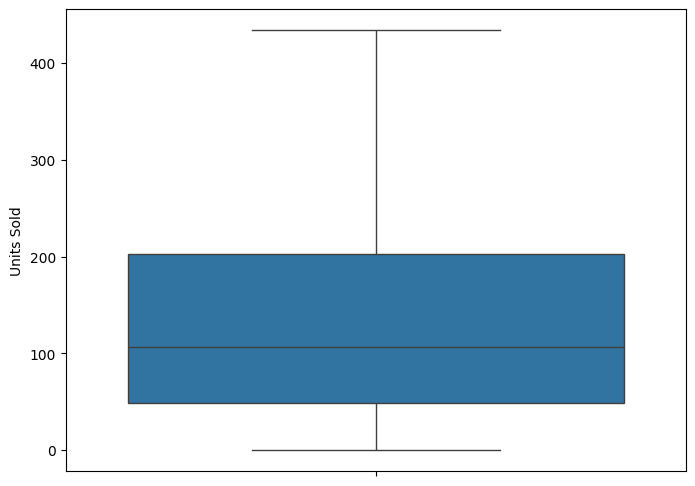

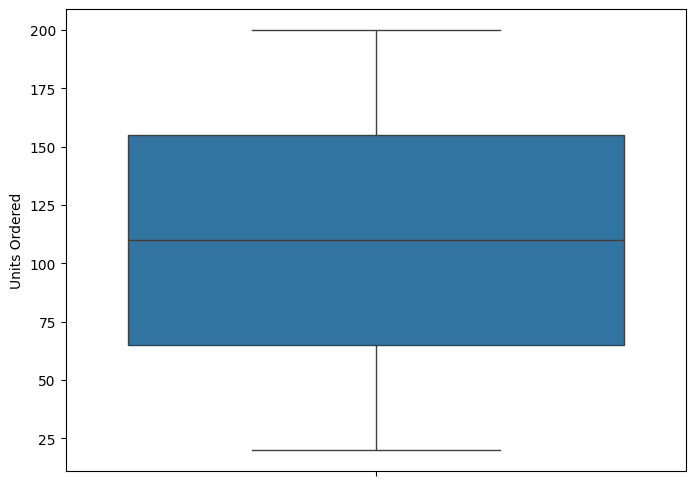

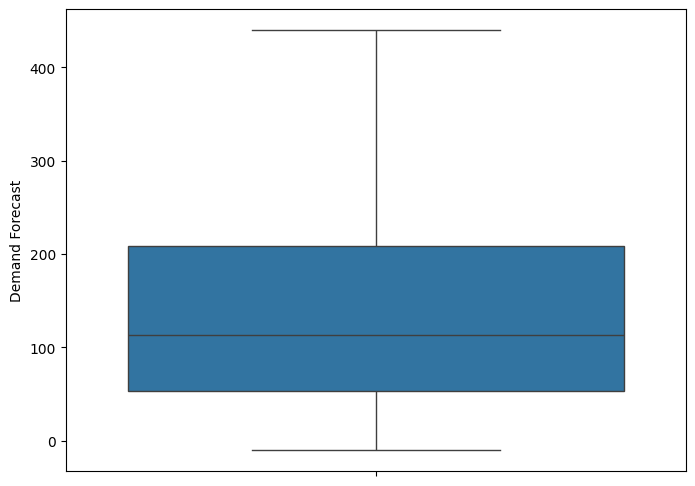

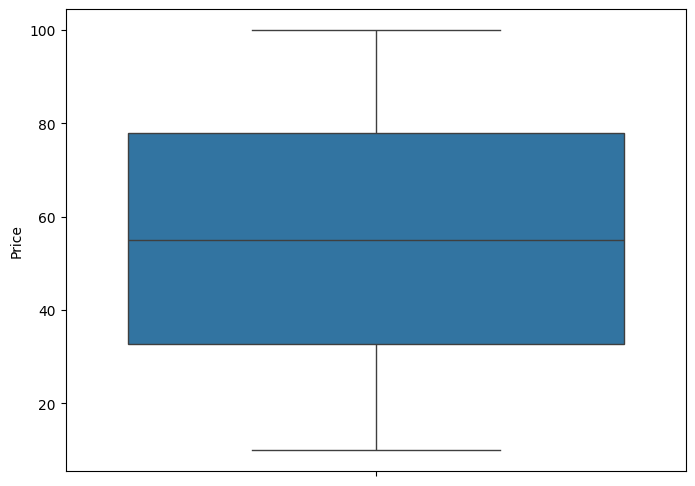

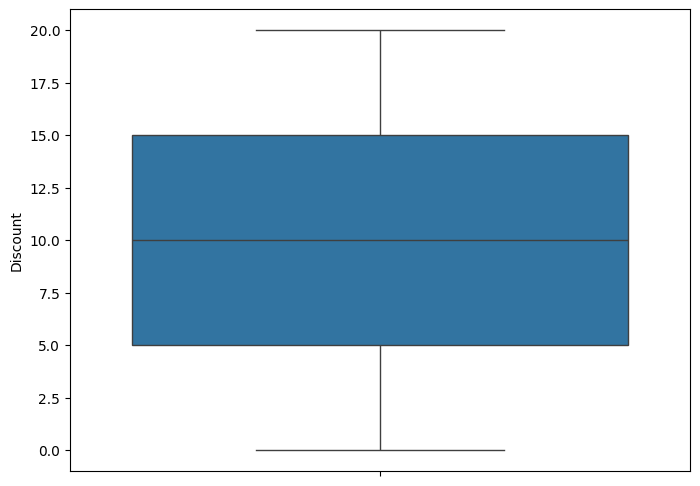

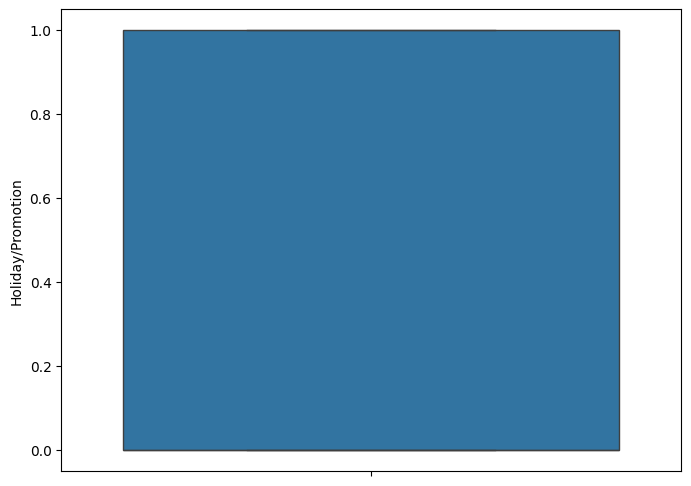

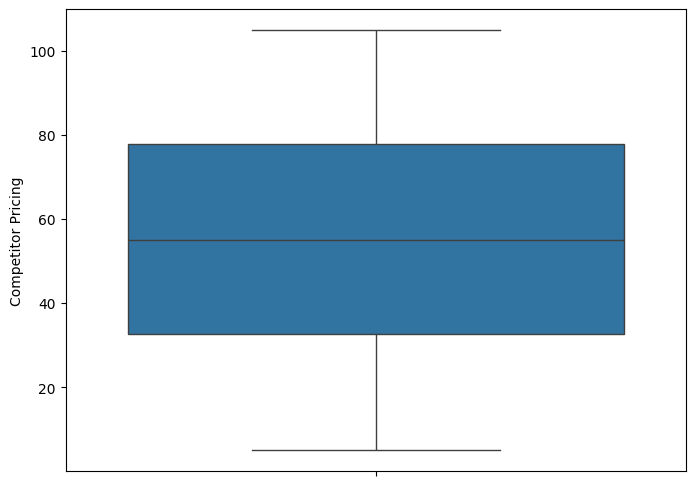

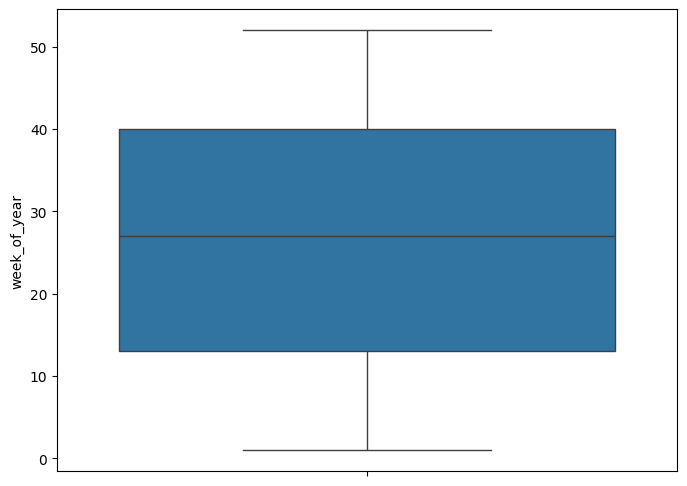

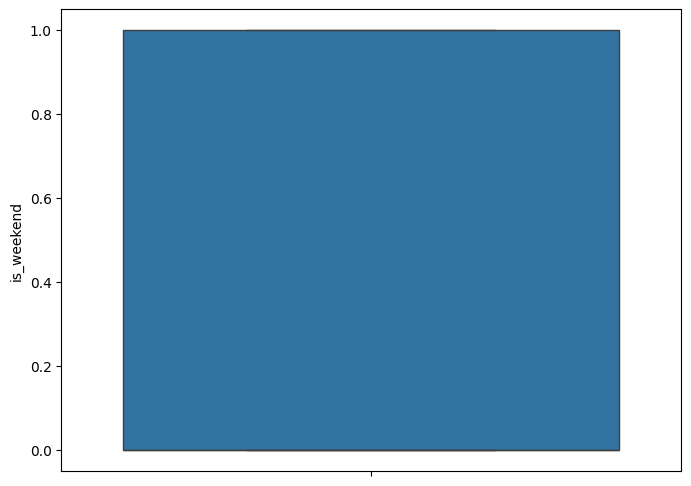

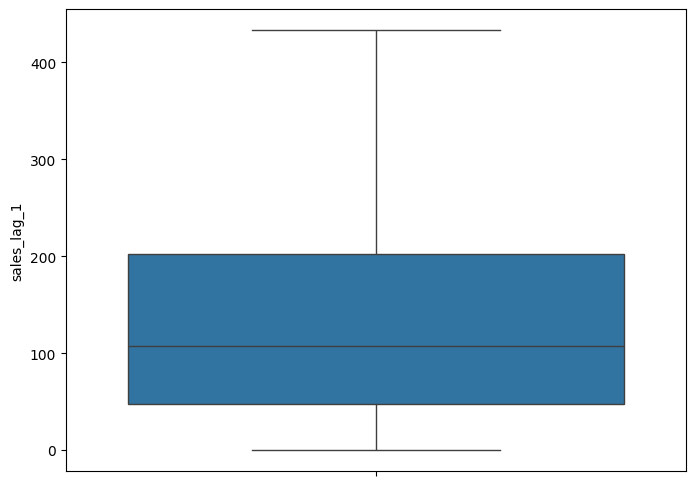

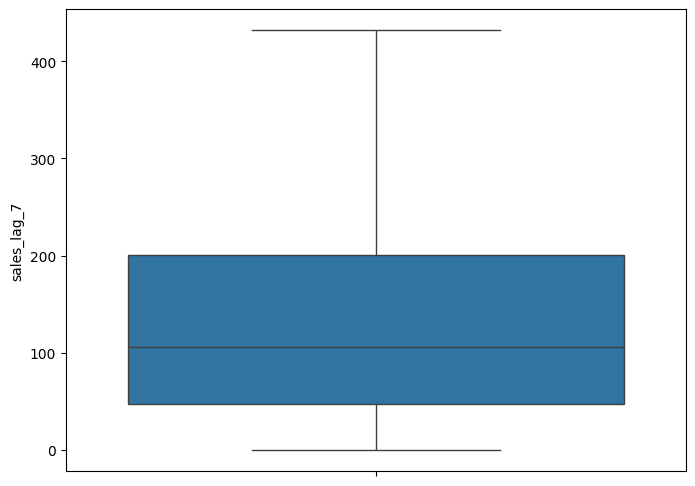

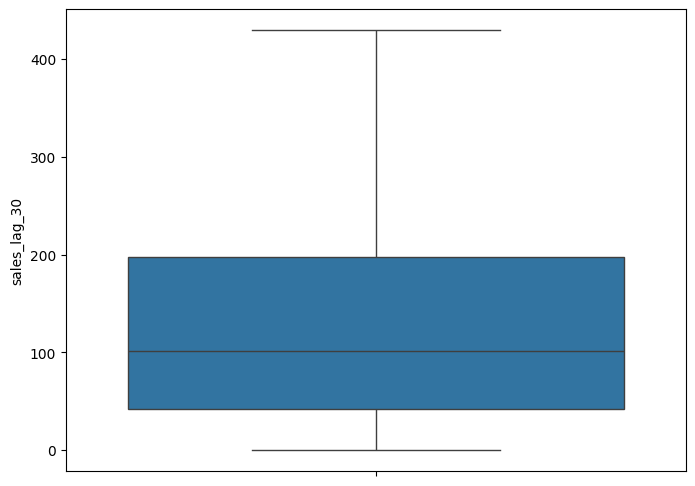

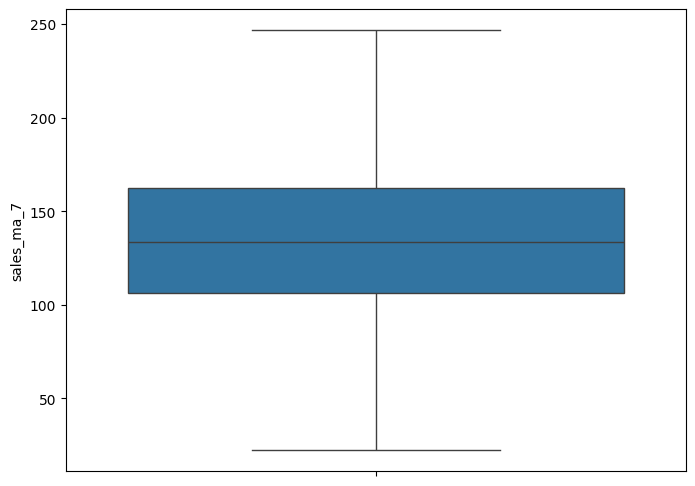

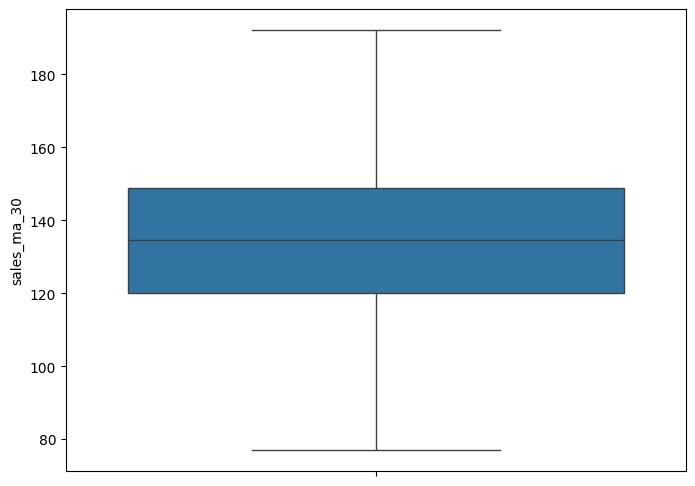

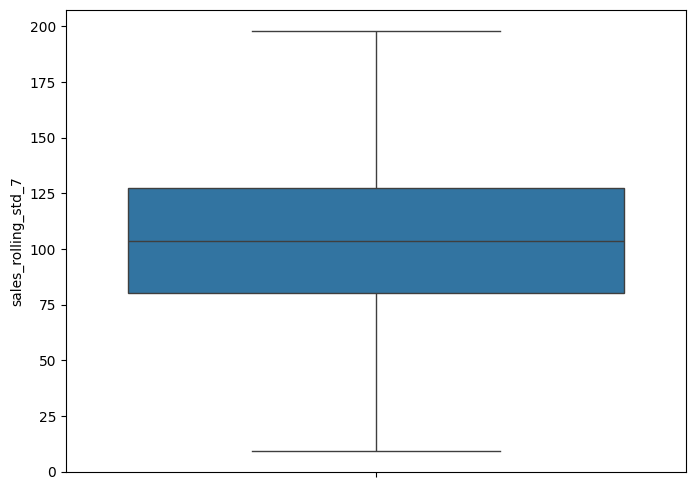

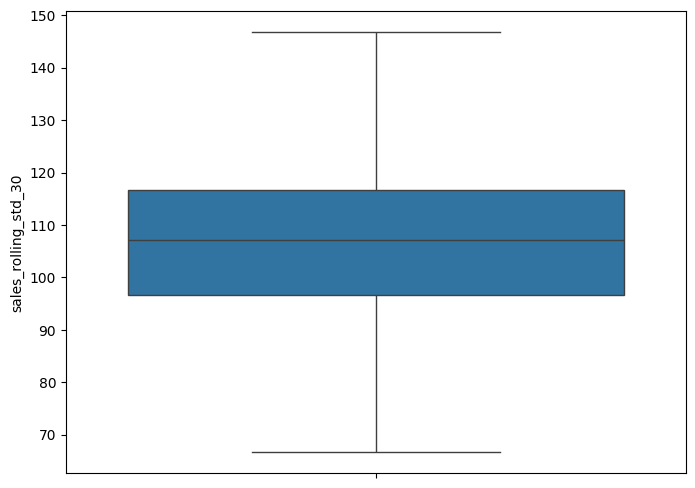

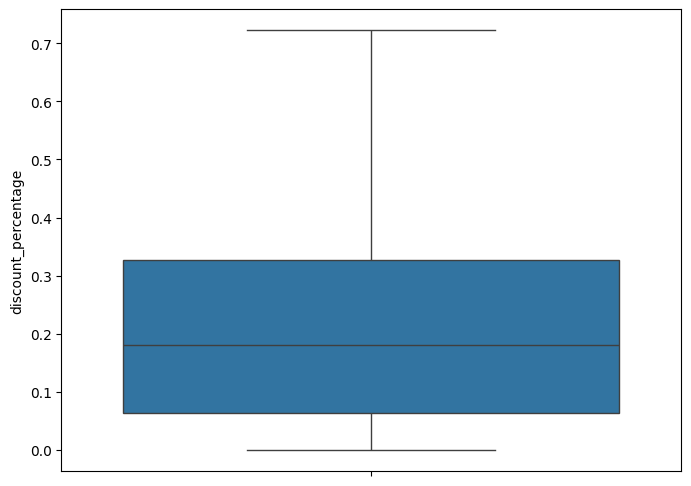

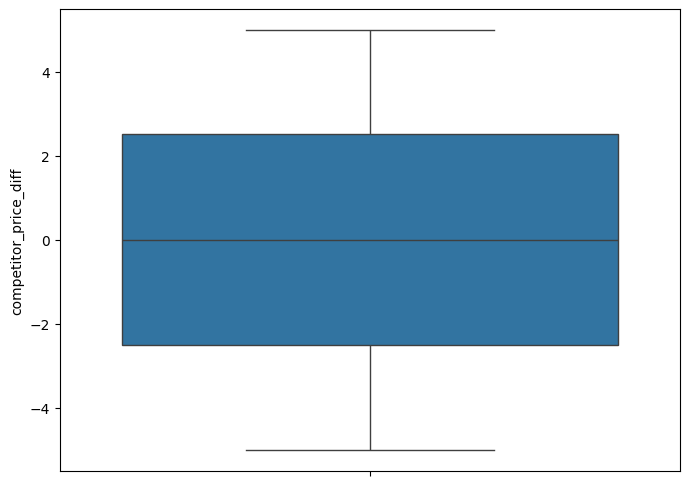

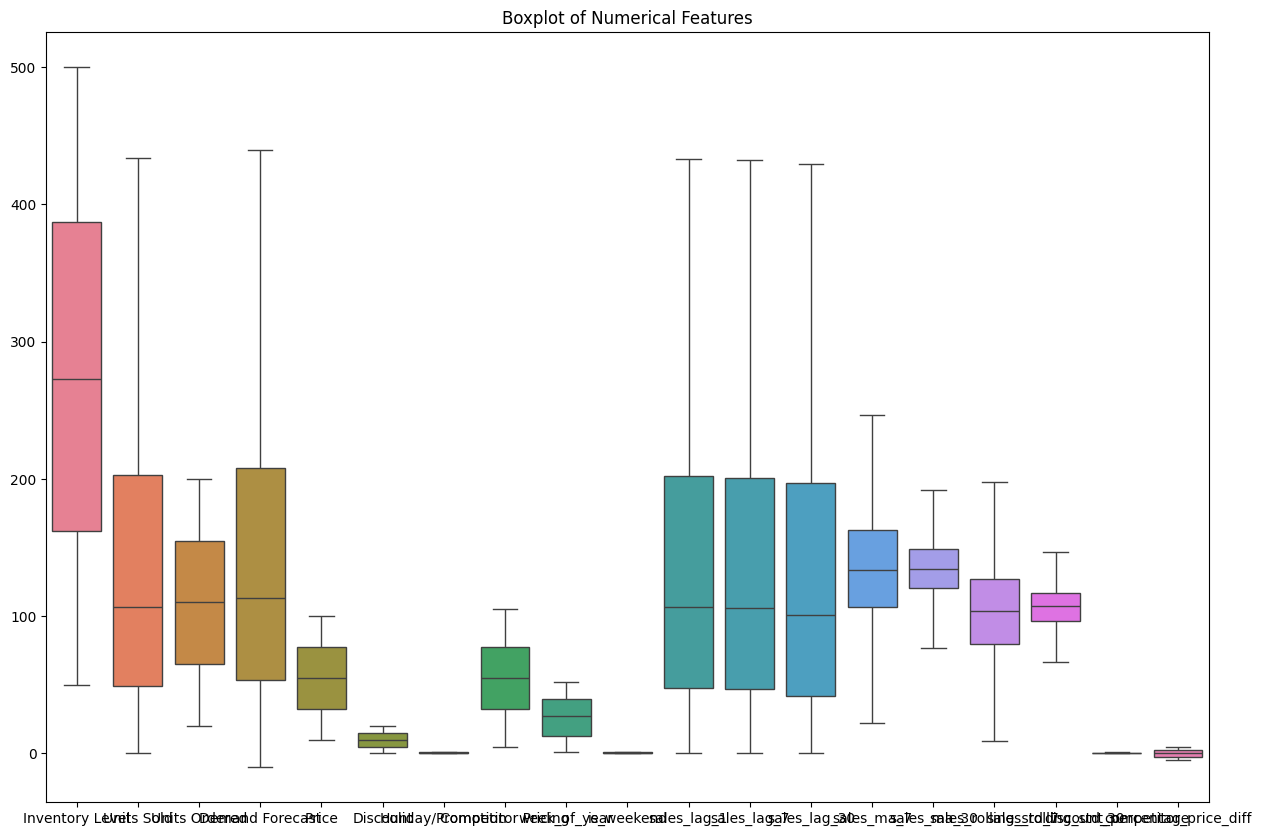

In [ ]:
# Function to cap outliers using IQR (Interquartile Range)
def cap_outliers(df, columns):
    for col in columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define the lower and upper bounds for acceptable values
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the bounds to the lower or upper threshold
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df

# List of columns from which to cap outliers
columns_to_cap_outliers = ["sales_lag_1", "sales_lag_7", "sales_lag_30","sales_ma_7","sales_ma_30","sales_rolling_std_7","sales_rolling_std_30","discount_percentage"]

# Assuming df_rename is your original DataFrame, apply the cap_outliers function
df_capped = cap_outliers(df, columns_to_cap_outliers)

# Display the first few rows of the capped DataFrame
print(df_capped.head())

# Generate individual boxplots for each column after capping outliers
for column in df_capped.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df_capped[column])
    plt.show()

# Generate a combined boxplot for all selected columns after capping outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_capped.select_dtypes(include=['int64','float64']))
plt.title('Boxplot of Numerical Features')
plt.show()


In [ ]:
import numpy as np

def handle_outliers_iqr(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers with median (or clip values within the range)
    df[feature] = np.where((df[feature] < lower_bound) | (df[feature] > upper_bound),
                           df[feature].median(), df[feature])
    return df

# Apply to lag features
features = ["sales_lag_1", "sales_lag_7", "sales_lag_30","sales_ma_7","sales_ma_30","sales_rolling_std_7","sales_rolling_std_30"]
for feature in features:
    df_capped = handle_outliers_iqr(df_capped, feature)

print("Outliers handled using IQR method.")


Outliers handled using IQR method.


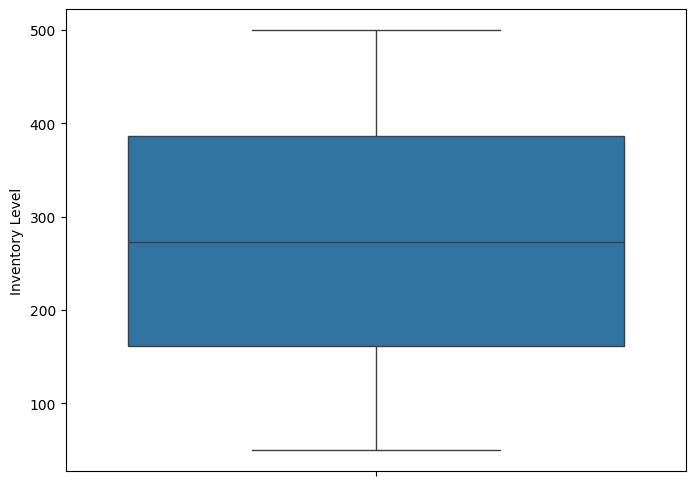

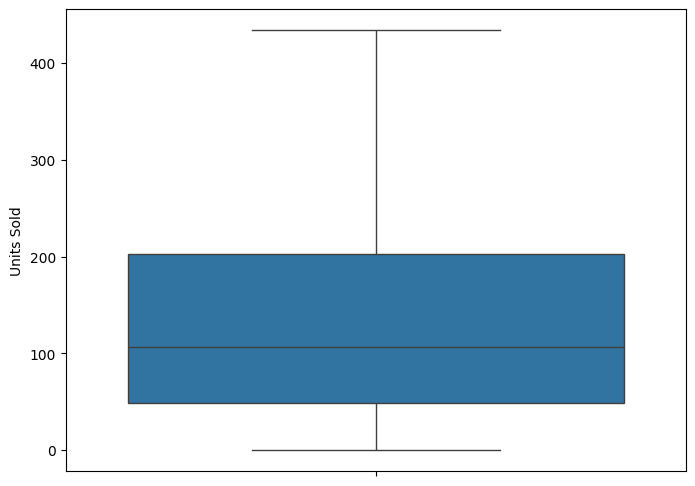

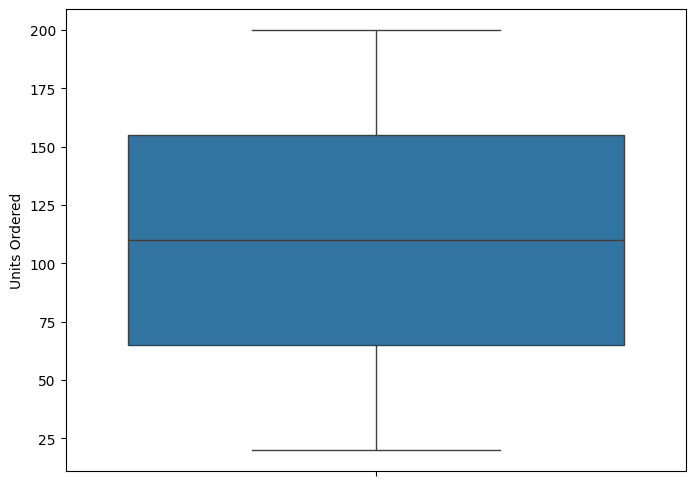

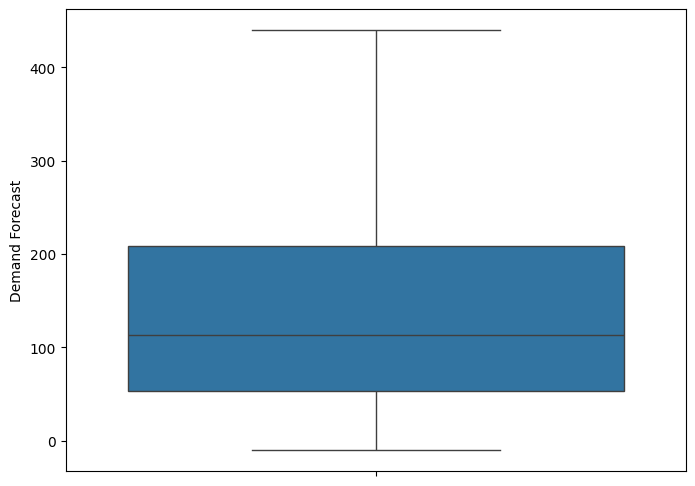

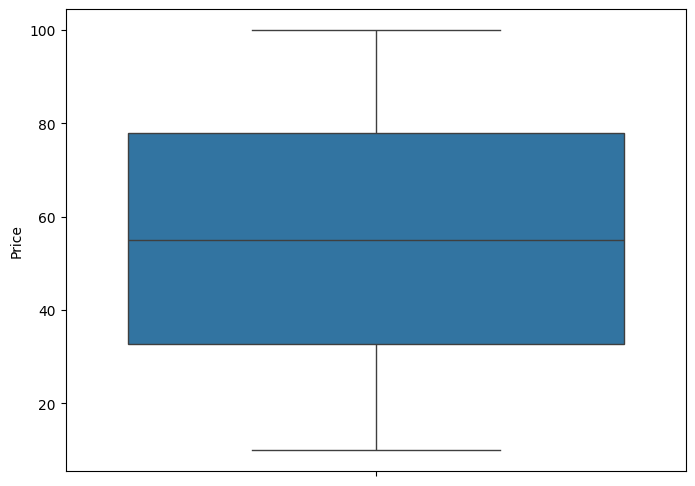

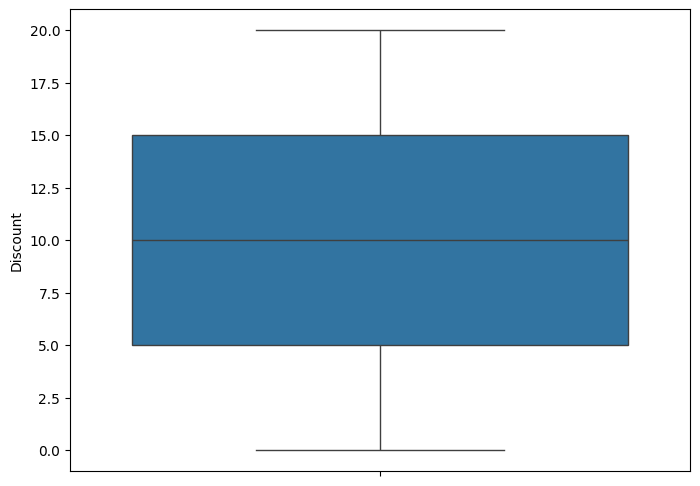

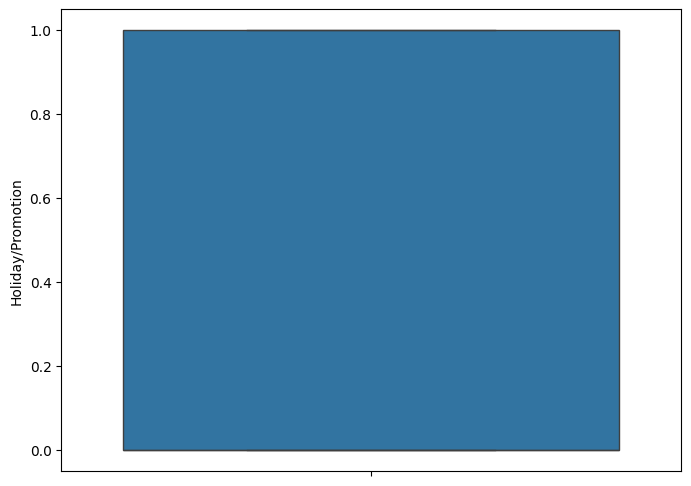

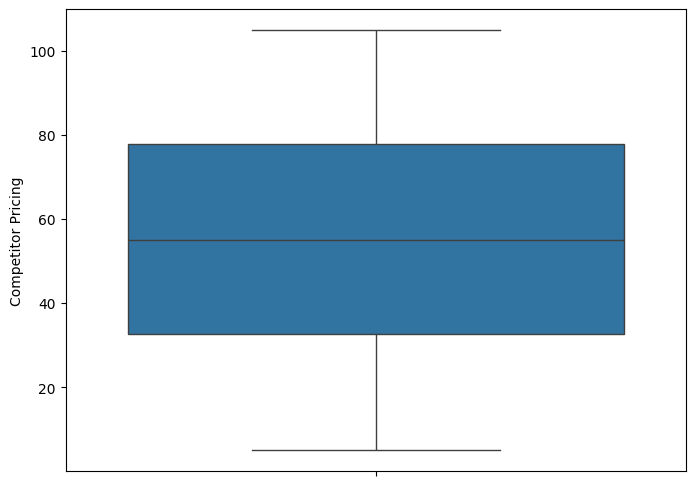

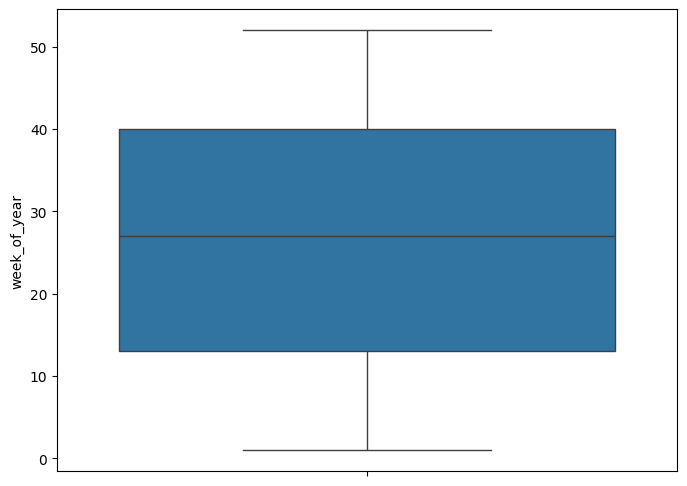

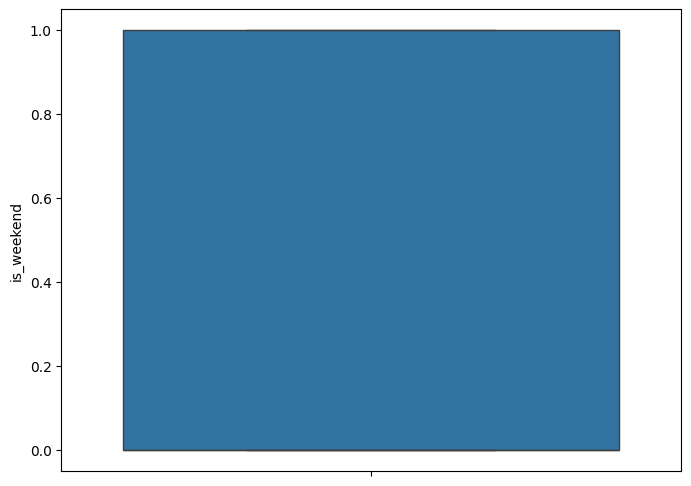

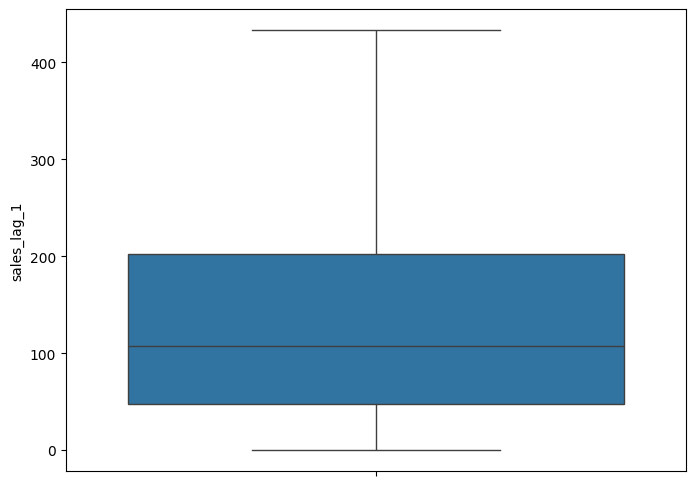

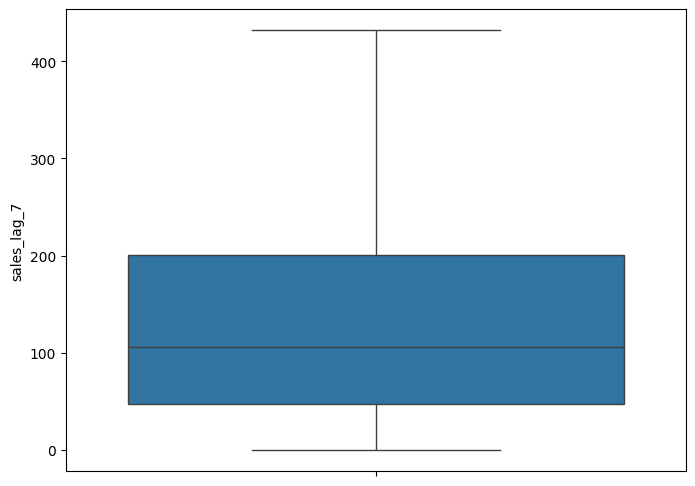

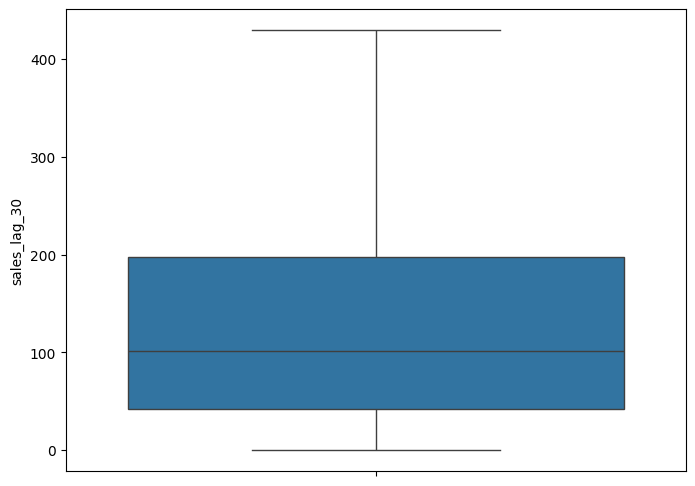

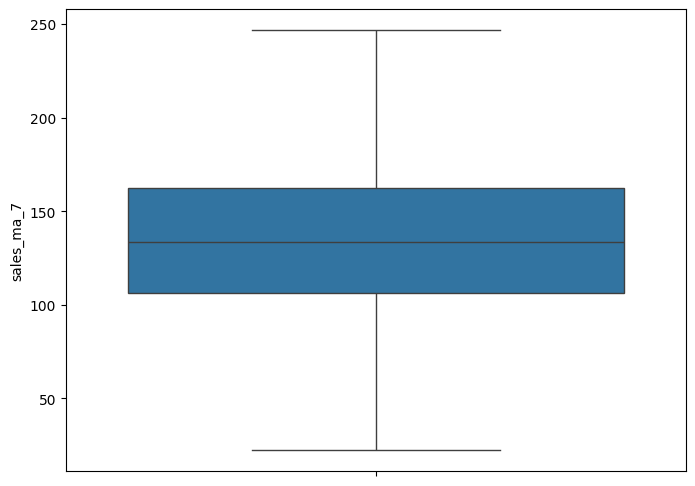

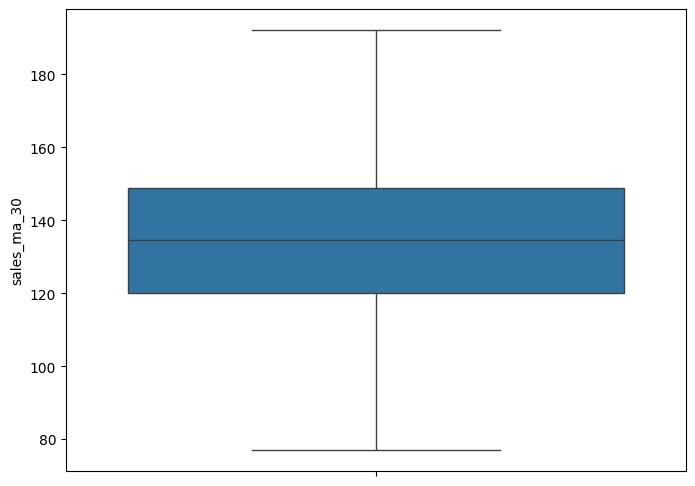

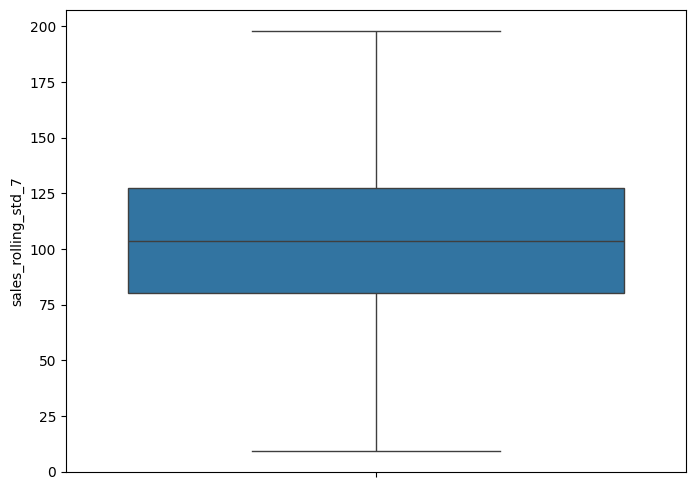

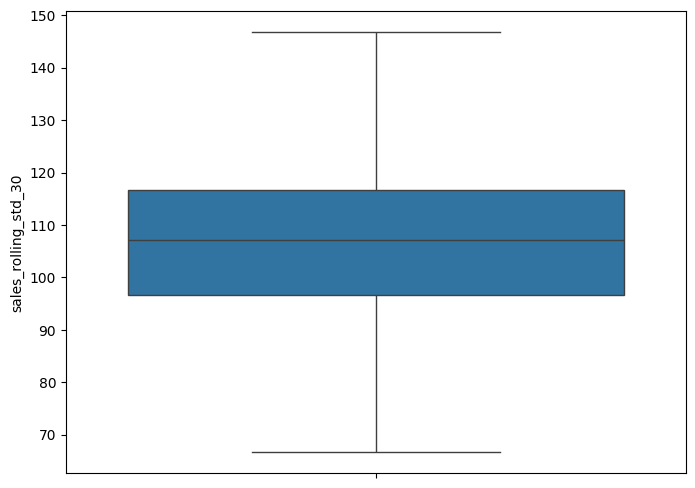

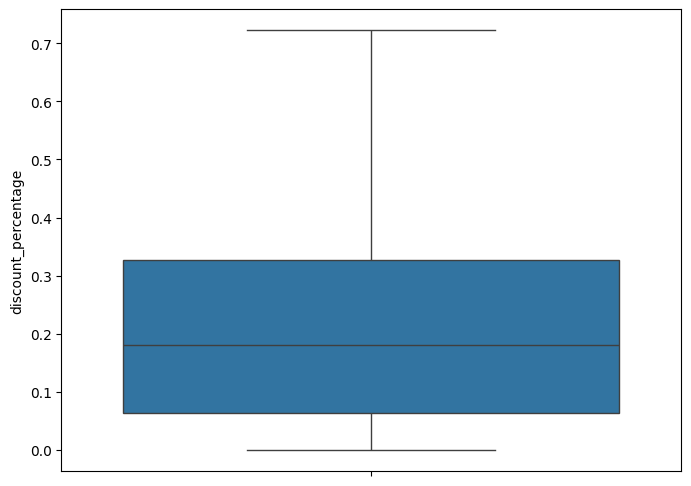

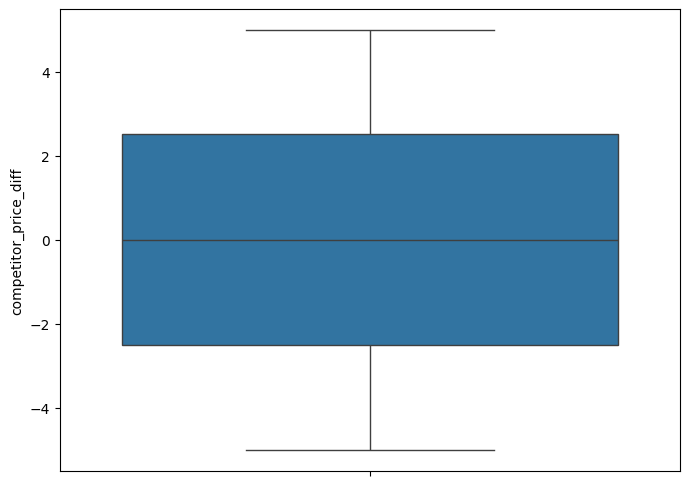

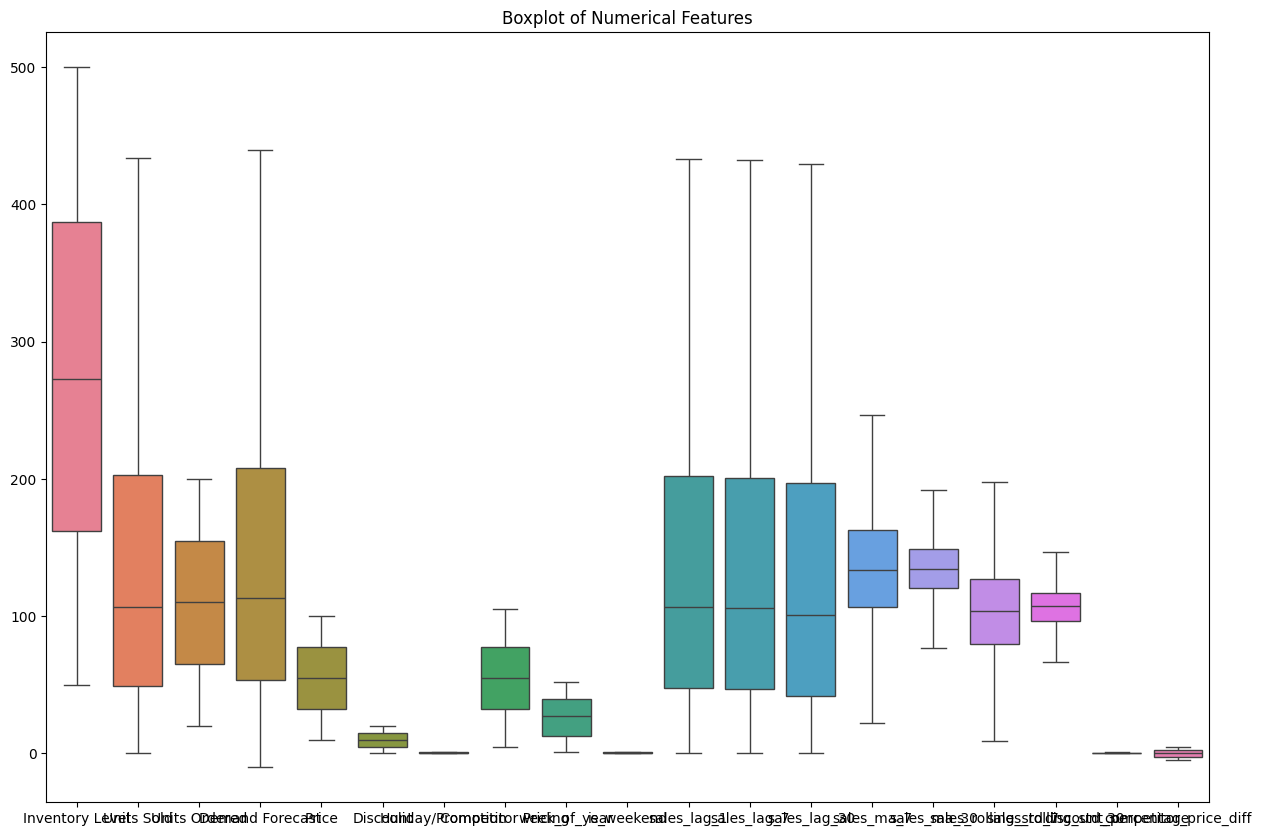

In [ ]:
for column in df_capped.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df_capped[column])
    plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=df_capped.select_dtypes(include=['int64','float64']))
plt.title('Boxplot of Numerical Features')
plt.show()

In [ ]:
def cap_outliers(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[feature] = df[feature].clip(lower=lower_bound, upper=upper_bound)
    return df

lag_features = ["sales_lag_1", "sales_lag_7", "sales_lag_30"]
# Apply to lag features

for feature in lag_features:
    df_capped = cap_outliers(df_capped, feature)

print("Outliers handled using capping.")


Outliers handled using capping.


## 3. Scaling the numerical values

In [ ]:
def apply_min_max_scaler(df, columns_to_scale):
    # """
    # Scales specified columns of a DataFrame using Min-Max Scaling.

    # Parameters:
    #     df (pd.DataFrame): The input DataFrame to scale.
    #     columns_to_scale (list): List of column names to apply Min-Max scaling.

    # Returns:
    #     pd.DataFrame: The DataFrame with scaled columns.
    # """
    from sklearn.preprocessing import MinMaxScaler
    import pandas as pd

    # Create a copy of the input DataFrame to preserve the original
    df_scaled = df.copy()

    # Initialize the scaler
    scaler = MinMaxScaler()

    # Apply scaling to each specified column
    for column in df.select_dtypes(include=['int64','float64']).columns:
        if column in df.columns:
            df_scaled[column] = scaler.fit_transform(df[[column]])


    return df_scaled

columns_to_scale = [df_capped.select_dtypes(include=['int64','float64']).columns]
df_scaled = apply_min_max_scaler(df_capped, columns_to_scale)

df_scaled

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,is_weekend,sales_lag_1,sales_lag_7,sales_lag_30,sales_ma_7,sales_ma_30,sales_rolling_std_7,sales_rolling_std_30,discount_percentage,competitor_price_diff
0,2022-01-01,S001,P0001,Groceries,North,0.402222,0.292627,0.194444,0.323520,0.261111,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.826302,0.119
100,2022-01-02,S001,P0001,Groceries,West,0.146667,0.186636,0.466667,0.228929,0.199444,...,1.0,0.293303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.495190,0.794
200,2022-01-03,S001,P0001,Electronics,West,0.231111,0.011521,0.938889,0.034140,0.585556,...,0.0,0.187067,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.441485,0.052
300,2022-01-04,S001,P0001,Groceries,South,0.077778,0.133641,0.961111,0.139808,0.754222,...,0.0,0.011547,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266575,0.311
400,2022-01-05,S001,P0001,Groceries,South,0.417778,0.338710,0.094444,0.356437,0.205111,...,0.0,0.133949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.972632,0.594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72699,2023-12-28,S005,P0020,Groceries,South,0.328889,0.129032,0.038889,0.133825,0.130556,...,0.0,0.318707,0.370370,0.065192,0.430344,0.616898,0.425025,0.579776,0.318174,0.854
72799,2023-12-29,S005,P0020,Clothing,East,0.880000,0.617512,0.055556,0.617260,0.839778,...,0.0,0.129330,0.527778,0.426077,0.455789,0.641493,0.472487,0.604163,0.323453,0.705
72899,2023-12-30,S005,P0020,Toys,North,0.446667,0.343318,0.894444,0.384572,0.772000,...,1.0,0.618938,0.509259,0.509895,0.410623,0.621238,0.429312,0.595154,0.174139,0.821
72999,2023-12-31,S005,P0020,Furniture,East,0.031111,0.092166,0.438889,0.154977,0.897667,...,1.0,0.344111,0.013889,0.351572,0.432252,0.589120,0.397021,0.616382,0.076223,0.588


## 4. Label Encoding the categorical values

In [ ]:
def Lebel_Encoding(df):
    from sklearn.preprocessing import LabelEncoder
    df_Encoded = df.copy()
    for column in df.select_dtypes(include=['object','category']).columns:


            encoder = LabelEncoder()
            df_Encoded[column] = encoder.fit_transform(df[column])
    return df_Encoded

df_encoded = Lebel_Encoding(df_scaled)
df_encoded

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,is_weekend,sales_lag_1,sales_lag_7,sales_lag_30,sales_ma_7,sales_ma_30,sales_rolling_std_7,sales_rolling_std_30,discount_percentage,competitor_price_diff
0,2022-01-01,0,0,3,1,0.402222,0.292627,0.194444,0.323520,0.261111,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.826302,0.119
100,2022-01-02,0,0,3,3,0.146667,0.186636,0.466667,0.228929,0.199444,...,1.0,0.293303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.495190,0.794
200,2022-01-03,0,0,1,3,0.231111,0.011521,0.938889,0.034140,0.585556,...,0.0,0.187067,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.441485,0.052
300,2022-01-04,0,0,3,2,0.077778,0.133641,0.961111,0.139808,0.754222,...,0.0,0.011547,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266575,0.311
400,2022-01-05,0,0,3,2,0.417778,0.338710,0.094444,0.356437,0.205111,...,0.0,0.133949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.972632,0.594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72699,2023-12-28,4,19,3,2,0.328889,0.129032,0.038889,0.133825,0.130556,...,0.0,0.318707,0.370370,0.065192,0.430344,0.616898,0.425025,0.579776,0.318174,0.854
72799,2023-12-29,4,19,0,0,0.880000,0.617512,0.055556,0.617260,0.839778,...,0.0,0.129330,0.527778,0.426077,0.455789,0.641493,0.472487,0.604163,0.323453,0.705
72899,2023-12-30,4,19,4,1,0.446667,0.343318,0.894444,0.384572,0.772000,...,1.0,0.618938,0.509259,0.509895,0.410623,0.621238,0.429312,0.595154,0.174139,0.821
72999,2023-12-31,4,19,2,0,0.031111,0.092166,0.438889,0.154977,0.897667,...,1.0,0.344111,0.013889,0.351572,0.432252,0.589120,0.397021,0.616382,0.076223,0.588


**Dropping unnecessary columns**

In [ ]:
# Drop non-numeric features for modeling
df_encoded = df_encoded.drop(columns=["Store ID", "Product ID"])
df_encoded

,Date,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,...,is_weekend,sales_lag_1,sales_lag_7,sales_lag_30,sales_ma_7,sales_ma_30,sales_rolling_std_7,sales_rolling_std_30,discount_percentage,competitor_price_diff
0,2022-01-01,3,1,0.402222,0.292627,0.194444,0.323520,0.261111,1.00,1,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.826302,0.119
100,2022-01-02,3,3,0.146667,0.186636,0.466667,0.228929,0.199444,0.50,0,...,1.0,0.293303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.495190,0.794
200,2022-01-03,1,3,0.231111,0.011521,0.938889,0.034140,0.585556,1.00,1,...,0.0,0.187067,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.441485,0.052
300,2022-01-04,3,2,0.077778,0.133641,0.961111,0.139808,0.754222,0.75,0,...,0.0,0.011547,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.266575,0.311
400,2022-01-05,3,2,0.417778,0.338710,0.094444,0.356437,0.205111,1.00,3,...,0.0,0.133949,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.972632,0.594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72699,2023-12-28,3,2,0.328889,0.129032,0.038889,0.133825,0.130556,0.25,3,...,0.0,0.318707,0.370370,0.065192,0.430344,0.616898,0.425025,0.579776,0.318174,0.854
72799,2023-12-29,0,0,0.880000,0.617512,0.055556,0.617260,0.839778,1.00,3,...,0.0,0.129330,0.527778,0.426077,0.455789,0.641493,0.472487,0.604163,0.323453,0.705
72899,2023-12-30,4,1,0.446667,0.343318,0.894444,0.384572,0.772000,0.50,0,...,1.0,0.618938,0.509259,0.509895,0.410623,0.621238,0.429312,0.595154,0.174139,0.821
72999,2023-12-31,2,0,0.031111,0.092166,0.438889,0.154977,0.897667,0.25,2,...,1.0,0.344111,0.013889,0.351572,0.432252,0.589120,0.397021,0.616382,0.076223,0.588


**Correlation Matrix**

In [ ]:
df_encoded.corr()

,Date,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,...,is_weekend,sales_lag_1,sales_lag_7,sales_lag_30,sales_ma_7,sales_ma_30,sales_rolling_std_7,sales_rolling_std_30,discount_percentage,competitor_price_diff
Date,1.000000,-0.003334,-0.002042,-0.001044,-0.002040,-0.000216,-0.002102,-0.009174,-0.002233,0.001079,...,-0.001504,0.001037,0.018469,0.083427,0.034036,0.162942,0.039791,0.168246,0.004092,0.002026
Category,-0.003334,1.000000,0.000841,0.001439,0.000501,-0.001686,0.000459,0.001375,-0.001784,-0.000624,...,0.002317,0.003114,-0.001762,0.002644,-0.002716,-0.002169,-0.009998,-0.006360,-0.000906,-0.003804
Region,-0.002042,0.000841,1.000000,-0.006837,-0.002951,0.003172,-0.002304,-0.003576,-0.002696,0.000209,...,-0.001620,0.001362,-0.003549,0.002194,-0.002283,-0.002698,0.002623,-0.000953,-0.000025,0.001488
Inventory Level,-0.001044,0.001439,-0.006837,1.000000,0.590190,0.001060,0.588762,0.009140,0.004889,0.001898,...,0.002209,-0.004913,-0.000997,-0.008584,0.212987,0.094804,0.122721,0.060254,-0.003437,0.002583
Units Sold,-0.002040,0.000501,-0.002951,0.590190,1.000000,-0.000938,0.996847,0.001284,0.002404,0.004724,...,-0.002374,-0.000467,0.002161,-0.005852,0.365082,0.158396,0.224133,0.108164,-0.000793,0.001494
Units Ordered,-0.000216,-0.001686,0.003172,0.001060,-0.000938,1.000000,-0.001105,0.004212,-0.000938,-0.001064,...,-0.004944,0.000900,-0.011571,-0.003568,-0.002343,-0.000549,-0.003980,-0.004268,-0.005255,0.003727
Demand Forecast,-0.002102,0.000459,-0.002304,0.588762,0.996847,-0.001105,1.000000,0.000866,0.002160,0.004824,...,-0.002356,-0.000290,0.001891,-0.005846,0.363989,0.158344,0.222869,0.107957,-0.000870,0.001362
Price,-0.009174,0.001375,-0.003576,0.009140,0.001284,0.004212,0.000866,1.000000,0.001509,-0.007715,...,-0.001210,0.005374,-0.004103,-0.000864,0.000166,-0.004243,0.002427,-0.003433,-0.550731,0.003357
Discount,-0.002233,-0.001784,-0.002696,0.004889,0.002404,-0.000938,0.002160,0.001509,1.000000,-0.002302,...,0.003032,-0.005904,0.002310,-0.001932,-0.001967,-0.002090,-0.000292,0.002495,0.714418,0.004154
Weather Condition,0.001079,-0.000624,0.000209,0.001898,0.004724,-0.001064,0.004824,-0.007715,-0.002302,1.000000,...,-0.001705,0.000358,0.002422,-0.000032,0.000334,0.003984,0.001309,0.005393,0.001002,0.002036


**Correlation Heatmap**

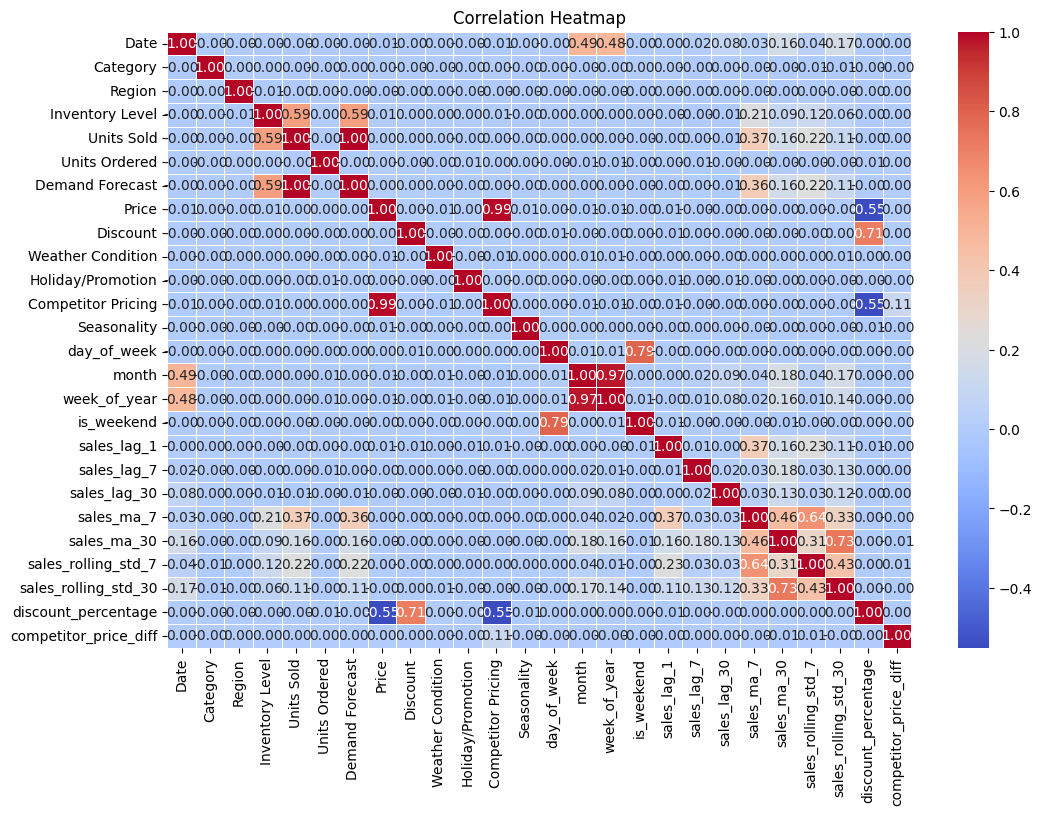

In [ ]:
#Calculate the correlation matrix for numerical features
corr_matrix = df_encoded.corr()

# Step 4: Generate a heatmap to visualize feature relationships
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Time Series Plotting**

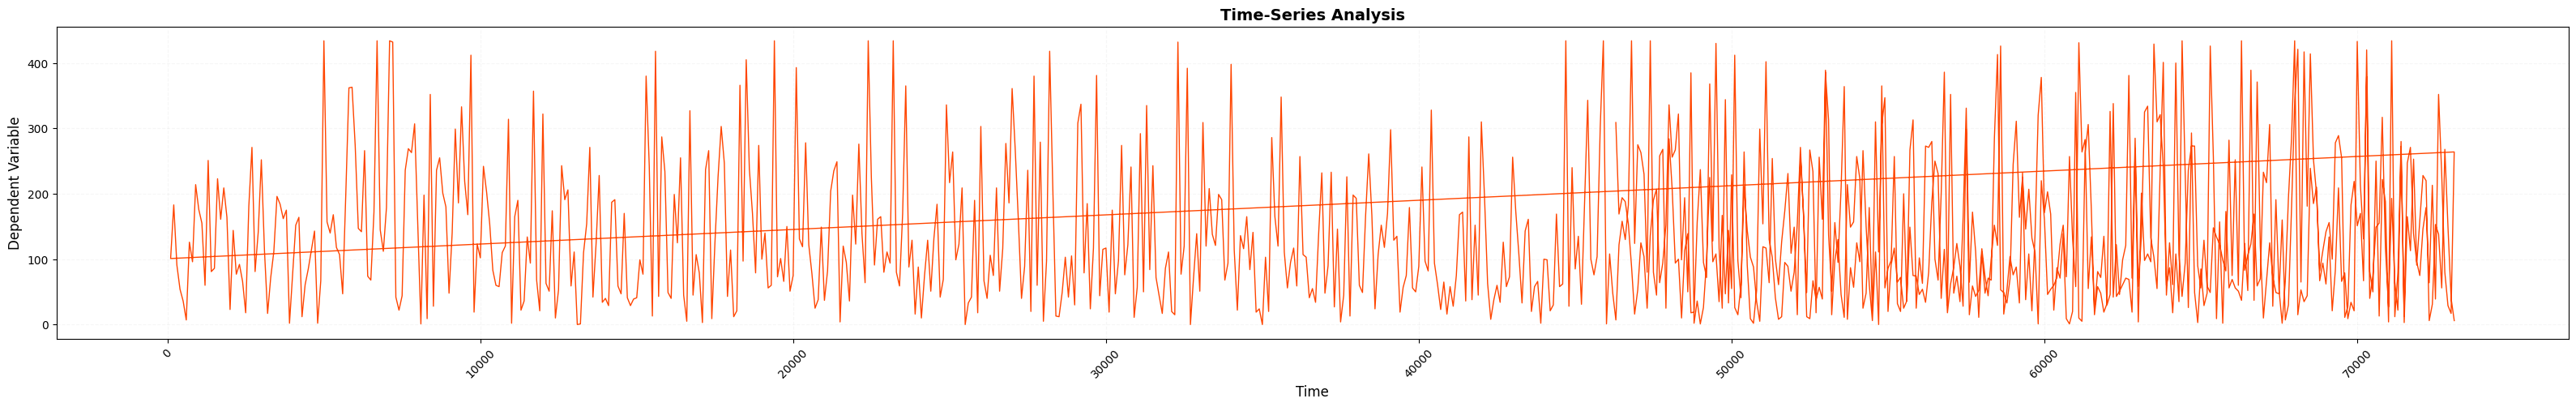

In [ ]:
import matplotlib.pyplot as plt
#  Plot time-series data
plt.figure(figsize=(40, 5))
plt.plot(df_encoded.tail(1000).index, df_capped.tail(1000)["Units Sold"], color="orangered", linewidth=1)

#  Add title and labels
plt.title("Time-Series Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Dependent Variable", fontsize=12)

#  Customize axes
plt.grid(True, linestyle="--", alpha=0.1)
plt.xticks(rotation=45)

#  Show the plot
plt.show()

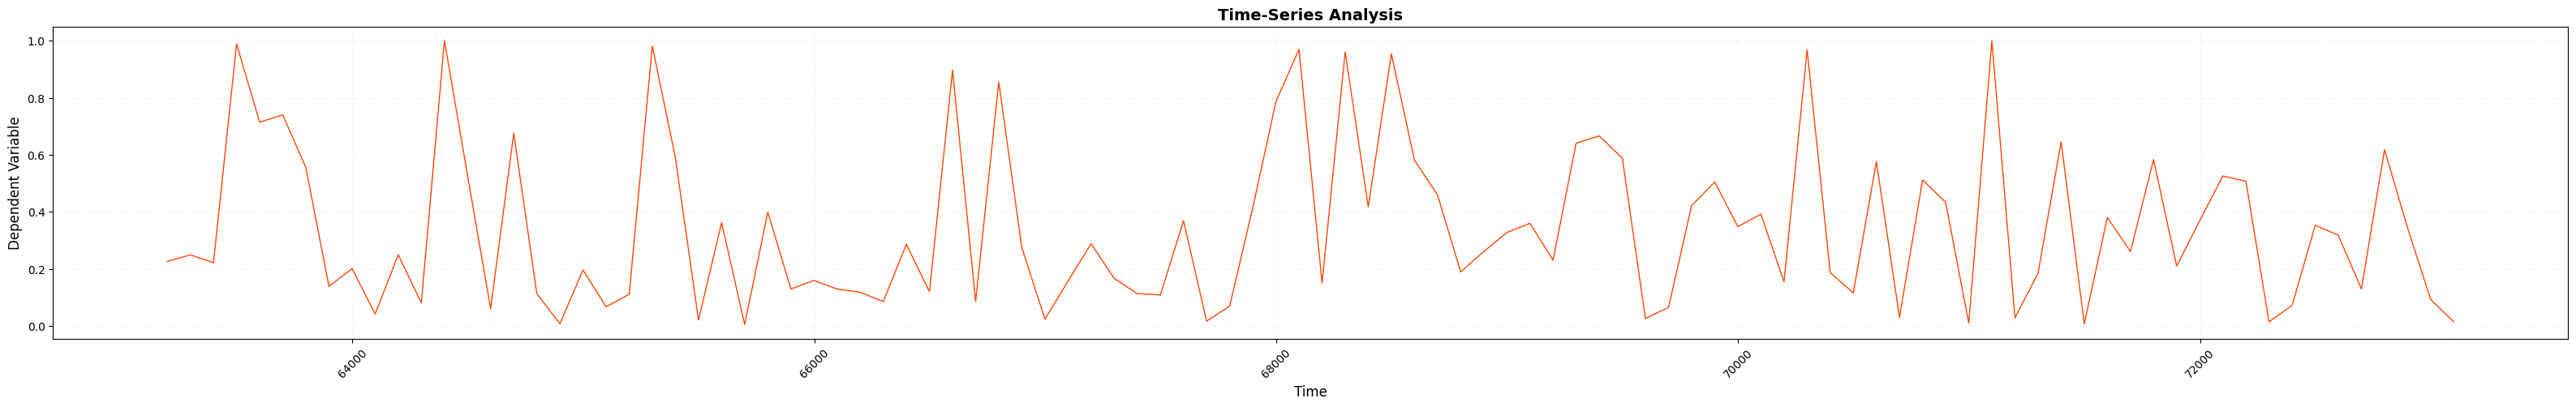

In [ ]:
import matplotlib.pyplot as plt
#  Plot time-series data
plt.figure(figsize=(40, 5))
df_sampled = df_encoded.tail(100)  # Take every 100th row
plt.plot(df_sampled.index, df_sampled["Units Sold"], color="orangered", linewidth=1)

#  Add title and labels
plt.title("Time-Series Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Dependent Variable", fontsize=12)

#  Customize axes
plt.grid(True, linestyle="--", alpha=0.1)
plt.xticks(rotation=45)

#  Show the plot
plt.show()


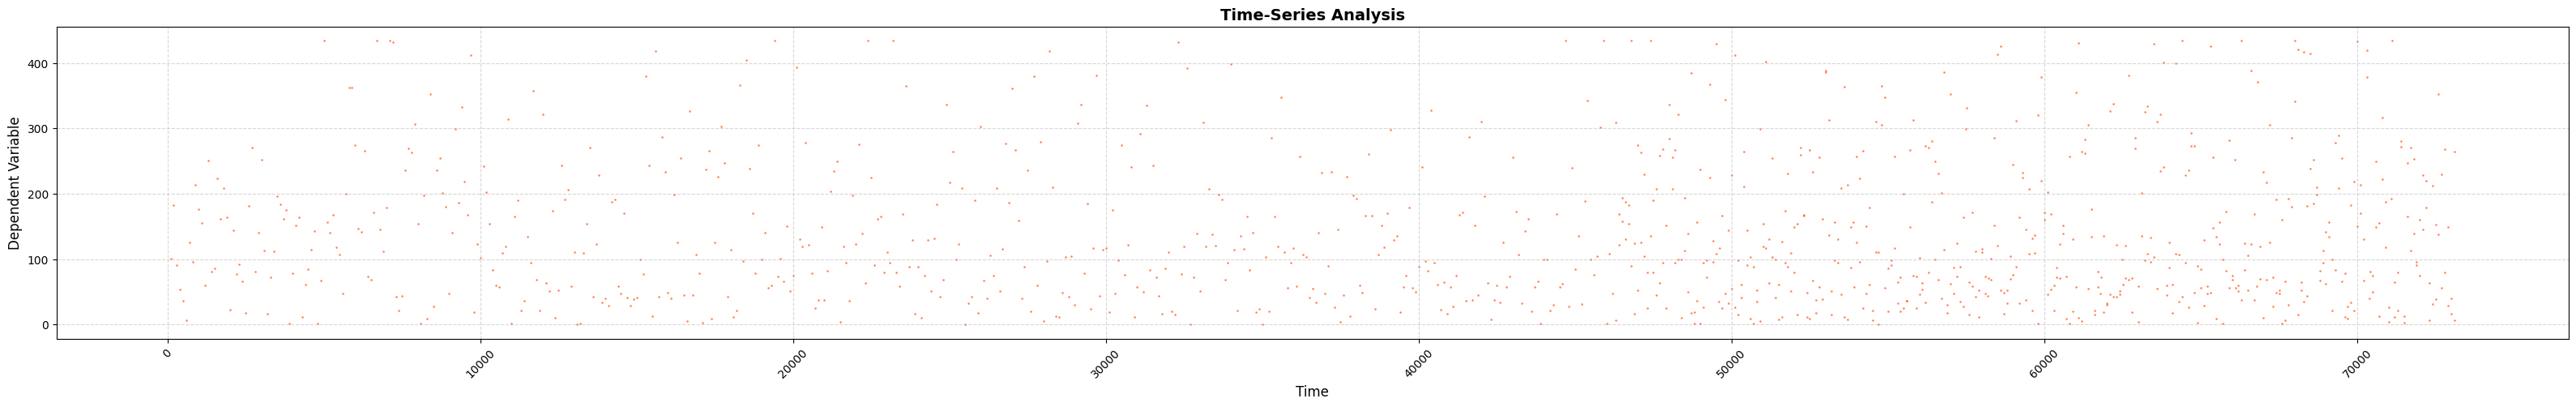

In [ ]:
import matplotlib.pyplot as plt
#  Plot time-series data
plt.figure(figsize=(40, 5))
plt.scatter(df_encoded.tail(1000).index, df_capped.tail(1000)["Units Sold"], color="orangered", s=1, alpha=0.5)

#  Add title and labels
plt.title("Time-Series Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Dependent Variable", fontsize=12)

#  Customize axes
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)

#  Show the plot
plt.show()


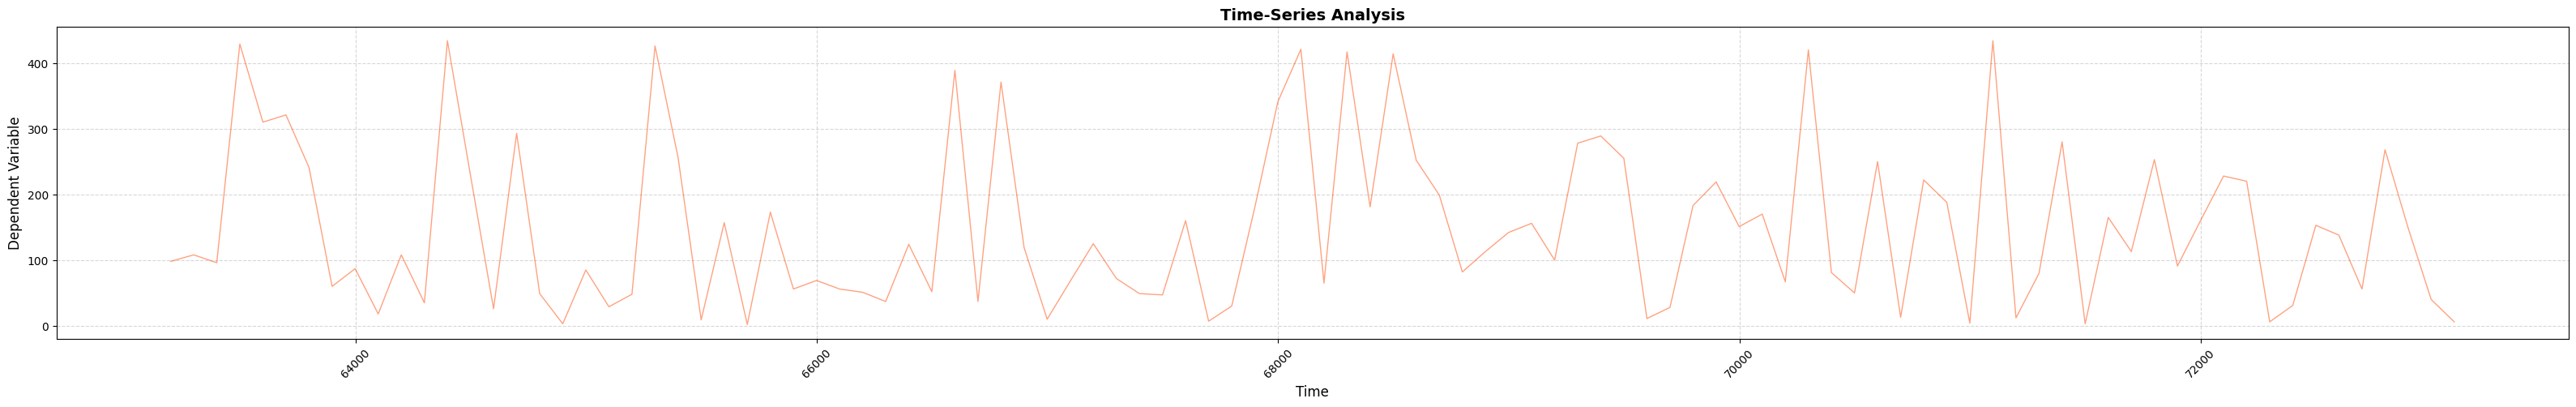

In [ ]:
import matplotlib.pyplot as plt
#  Plot time-series data
plt.figure(figsize=(40, 5))
plt.plot(df_capped.tail(100).index, df_capped.tail(100)["Units Sold"], color="orangered", linewidth=1, alpha=0.5)


#  Add title and labels
plt.title("Time-Series Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Dependent Variable", fontsize=12)

#  Customize axes
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)

#  Show the plot
plt.show()


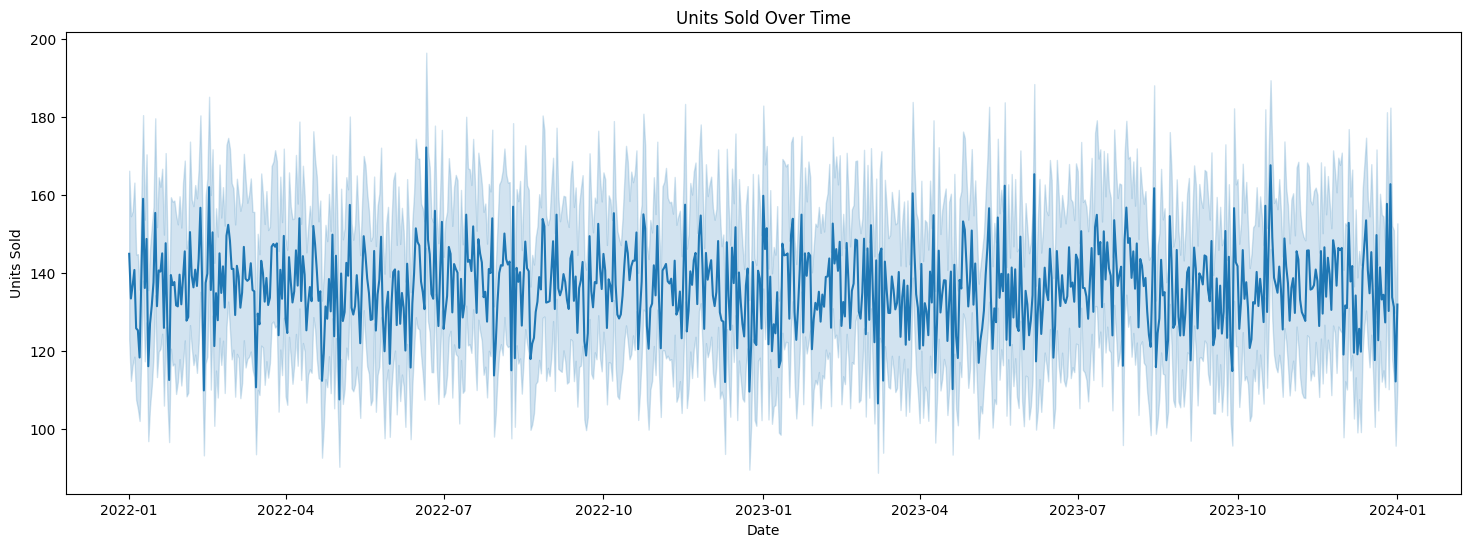

In [ ]:
plt.figure(figsize=(18, 6))
sns.lineplot(x='Date', y='Units Sold', data=df_capped)
plt.title('Units Sold Over Time')
plt.show()

## 5. Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df_encoded = df_encoded.sort_values(by="Date")  # Ensure chronological order

# Normalize target variable
scaler = MinMaxScaler()
df_encoded["Units Sold"] = scaler.fit_transform(df_encoded[["Units Sold"]])

# Train-Test Split
def train_test_splitting(df, target_column):
    X = df.drop(columns=[target_column, "Date"])
    y = df[target_column]
    return train_test_split(X, y, test_size=0.2, shuffle=False)

X_train, X_test, y_train, y_test = train_test_splitting(df_encoded, "Units Sold")


## 6. Model Train


*   Hybrid_ARIMA_LSTM



In [ ]:
from pmdarima import auto_arima

# Automatically find optimal (p, d, q) for ARIMA
auto_arima_model = auto_arima(df_encoded["Units Sold"], seasonal=True, m=6, trace=True)
print(auto_arima_model.summary())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[6] intercept   : AIC=4483.534, Time=152.94 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(0,0,0)[6] intercept   : AIC=4471.595, Time=9.01 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,0,0)(0,0,0)[6] intercept   : AIC=4473.527, Time=4.02 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,1)(0,0,0)[6] intercept   : AIC=4473.527, Time=7.47 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(0,0,0)[6] intercept   : AIC=4475.529, Time=6.51 sec

Best model:  ARIMA(0,0,0)(0,0,0)[6] intercept
Total fit time: 419.439 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                73100
Model:                        SARIMAX   Log Likelihood               -2233.797
Date:                Fri, 21 Mar 2025   AIC                           4471.595
Time:                        05:55:18   BIC                           4489.994
Sample:                             0   HQIC                          4477.258
                              - 73100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3139      0.001    264.218      0.000       0.31


 Training Hybrid ARIMA + LSTM Model...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Epoch 1, Loss: 0.0361
Epoch 2, Loss: 0.0063
Epoch 3, Loss: 0.0005
Epoch 4, Loss: 0.0004
Epoch 5, Loss: 0.0014
Epoch 6, Loss: 0.0004
Epoch 7, Loss: 0.0007
Epoch 8, Loss: 0.0010
Epoch 9, Loss: 0.0007
Epoch 10, Loss: 0.0004

 Model: Hybrid_ARIMA_LSTM
Mean Absolute Error (MAE): 0.0218
Mean Squared Error (MSE): 0.0007
Root Mean Squared Error (RMSE): 0.0267
R² Score: 0.9884


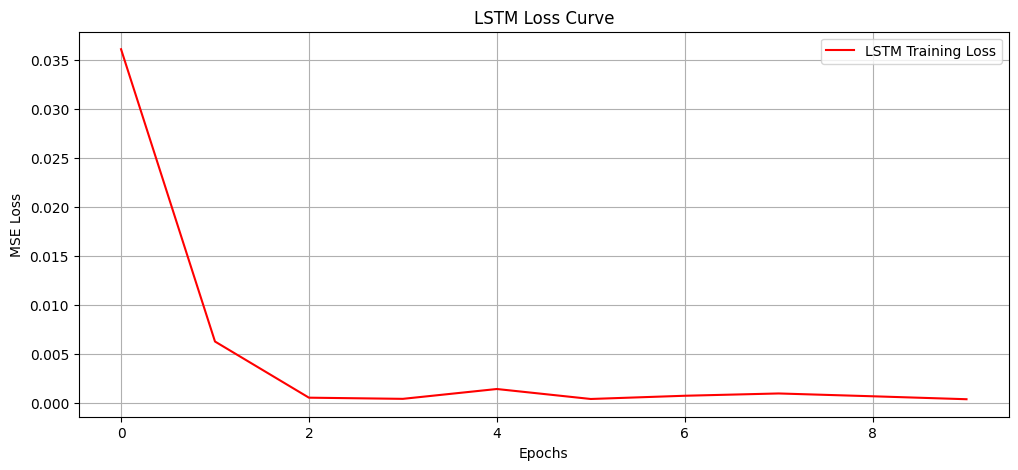

In [ ]:
!pip install shap lime torch statsmodels pmdarima
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from statsmodels.tsa.arima.model import ARIMA
import shap
from lime.lime_tabular import LimeTabularExplainer
import torch.nn as nn
import torch.optim as optim


# Function to evaluate models
def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n Model: {model_name}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])  # Get the last time step

# Train Hybrid ARIMA + LSTM
def train_hybrid_arima_lstm(y_train, X_train, y_test, X_test):
    print("\n Training Hybrid ARIMA + LSTM Model...")

    # Step 1: Train ARIMA
    p, d, q = auto_arima(y_train, seasonal=False).order
    arima_model = ARIMA(y_train, order=(p, d, q)).fit()

    # ARIMA Predictions
    arima_pred_train = arima_model.fittedvalues
    arima_pred_test = arima_model.forecast(steps=len(y_test))

    # Step 2: Compute Residuals (Errors)
    residuals_train = y_train - arima_pred_train

    # Step 3: Train LSTM on Residuals
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Convert to PyTorch tensors
    X_train_lstm = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(-1)
    X_test_lstm = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(-1)
    y_train_residuals = torch.tensor(residuals_train.values, dtype=torch.float32)

    # Create DataLoader
    train_loader = DataLoader(TensorDataset(X_train_lstm, y_train_residuals), batch_size=32, shuffle=True)

    # Initialize LSTM Model
    lstm_model = LSTMModel()
    optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    # Train LSTM Model
    epochs = 10
    loss_history = []
    for epoch in range(epochs):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = lstm_model(batch_x)
            loss = loss_fn(output.squeeze(), batch_y)
            loss.backward()
            optimizer.step()
        loss_history.append(loss.item())
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # Predict LSTM residuals
    lstm_model.eval()
    with torch.no_grad():
        lstm_pred_test = lstm_model(X_test_lstm).squeeze().numpy()

    # Step 4: Final Prediction = ARIMA + LSTM Residuals
    y_pred = arima_pred_test + lstm_pred_test

    # Evaluate
    evaluate_model(y_test, y_pred, "Hybrid_ARIMA_LSTM")

    # Plot LSTM Loss Curve
    plt.figure(figsize=(12, 5))
    plt.plot(loss_history, label="LSTM Training Loss", color='red')
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.title("LSTM Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    return (arima_model, lstm_model), y_pred
# Call train_test_splitting to create X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_splitting(df_encoded, 'Units Sold') # Assuming 'Units Sold' is your target column

# Call Hybrid Model Training
hybrid_model, hybrid_pred = train_hybrid_arima_lstm(y_train, X_train, y_test, X_test)

# **Challange 3. Dynamic Pricing**

1.  Feature Engineering
2.  Null values Fillup, Outliers Removal
3.  Scaling the numerical values
4.  Label Encoding Categorical values
5.  Train Test Split
6.  Model Train

*   Linear Regression
*   Decision Tree
*   Random Forest
*   Gradient Boosting
*   XGBoost
*   LightGBM

7.  HyperParameter Tuning
8.  X-AI

*   SHAP
*   LIME

In [15]:
missing_values = df_capped_3.isna().sum()
missing_values_percent = 100 * df_capped_3.isna().sum()/len(df_capped_3)
print(missing_values_percent)
print(missing_values)

Date                  0.0
Store ID              0.0
Product ID            0.0
Category              0.0
Region                0.0
Inventory Level       0.0
Units Sold            0.0
Units Ordered         0.0
Demand Forecast       0.0
Price                 0.0
Discount              0.0
Weather Condition     0.0
Holiday/Promotion     0.0
Competitor Pricing    0.0
Seasonality           0.0
dtype: float64
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [16]:
!pip install shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b198193a43400daf99f5a64458838d029104f6316e4c2034bf93f6e129799029
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


## 1. Feature Engineering

In [17]:
# Convert Date column to datetime
df_capped_3["Date"] = pd.to_datetime(df_capped_3["Date"])
df_capped_3["Year"] = df_capped_3["Date"].dt.year
df_capped_3["Month"] = df_capped_3["Date"].dt.month
df_capped_3["Day"] = df_capped_3["Date"].dt.day
df_capped_3["Weekday"] = df_capped_3["Date"].dt.weekday
df_capped_3["Is_Weekend"] = (df_capped_3["Weekday"] >= 5).astype(int)

# df_capped_3.drop(columns=["Date"], inplace=True)

# Feature Engineering
## Demand-based features
df_capped_3["Demand_to_Inventory_Ratio"] = df_capped_3["Units Sold"] / (df_capped_3["Inventory Level"] + 1)
df_capped_3["Demand_Variation"] = df_capped_3["Demand Forecast"] - df_capped_3["Units Sold"]

## Pricing-based features
df_capped_3["Price_Discounted"] = df_capped_3["Price"] * (1 - df_capped_3["Discount"] / 100)
df_capped_3["Price_Diff_Competitor"] = df_capped_3["Price"] - df_capped_3["Competitor Pricing"]
df_capped_3["Historical_Discount_Impact"] = df_capped_3["Discount"] / (df_capped_3["Price"] + 1)

## Seasonality-based features
df_capped_3["Seasonal_Impact"] = df_capped_3["Seasonality"].map({"Winter": 0.8, "Spring": 1.0, "Summer": 1.3, "Autumn": 1.0})
df_capped_3["Holiday_Influence"] = df_capped_3["Holiday/Promotion"] * df_capped_3["Seasonal_Impact"]

df_capped_3["Weather_Impact"] = df_capped_3["Weather Condition"].map({"Sunny": 1.3, "Rainy": 0.9, "Cloudy": 1.0})


In [18]:
df_capped_3.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Weekday,Is_Weekend,Demand_to_Inventory_Ratio,Demand_Variation,Price_Discounted,Price_Diff_Competitor,Historical_Discount_Impact,Seasonal_Impact,Holiday_Influence,Weather_Impact
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,...,5,1,0.547414,8.47,26.8000,3.81,0.579710,1.0,0.0,0.9
72,2022-01-01,S004,P0013,Furniture,East,191,56,65,54.47,61.81,...,5,1,0.291667,-1.53,61.8100,-2.11,0.000000,1.0,0.0,1.3
71,2022-01-01,S004,P0012,Electronics,North,349,9,165,0.95,14.25,...,5,1,0.025714,-8.05,13.5375,-4.31,0.327869,1.0,1.0,0.9
70,2022-01-01,S004,P0011,Electronics,West,205,46,27,46.65,54.84,...,5,1,0.223301,0.65,54.8400,-2.92,0.000000,1.0,1.0,1.3
69,2022-01-01,S004,P0010,Groceries,East,447,104,96,115.03,33.48,...,5,1,0.232143,11.03,28.4580,-3.67,0.435035,1.3,0.0,1.0


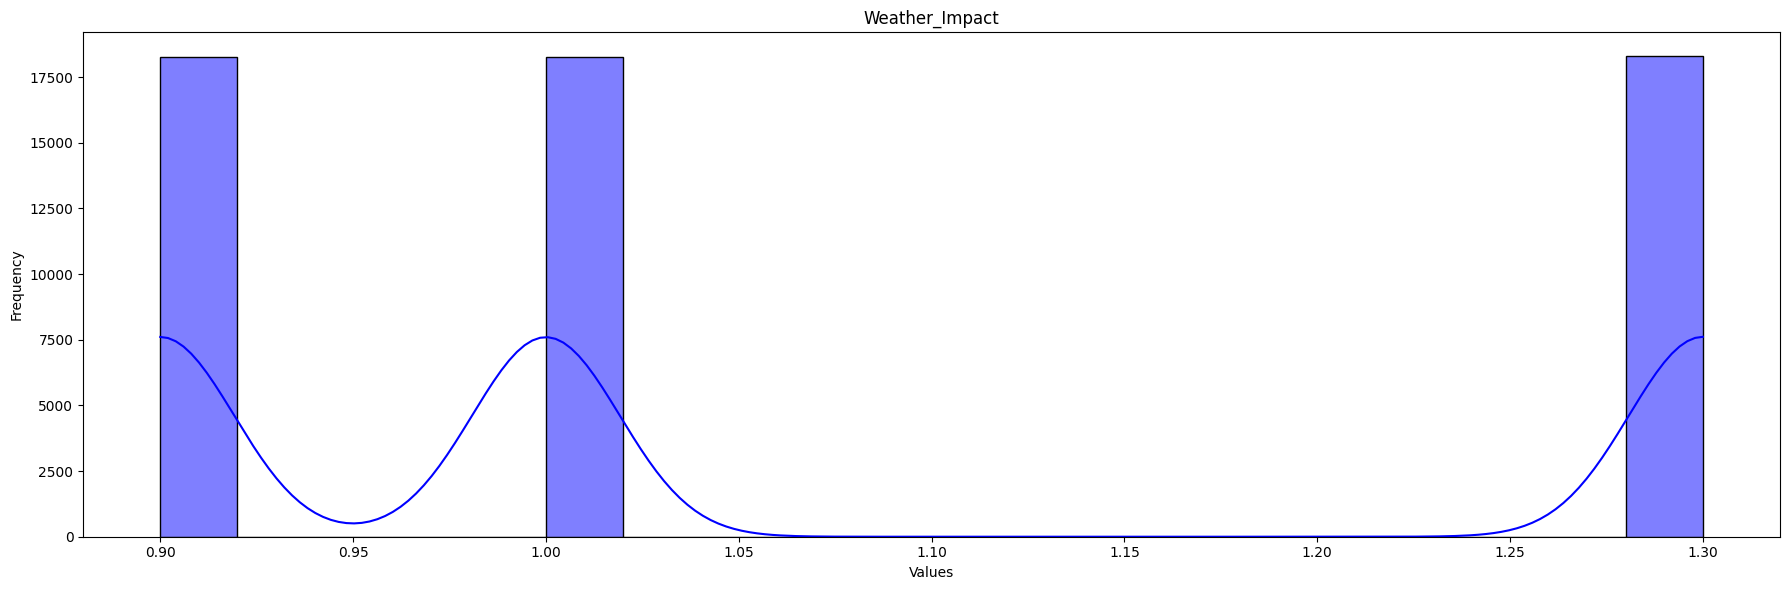

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

#Prepare data,
Weather_Impact = df_capped_3['Weather_Impact']

#Create the figure
fig, axs = plt.subplots(1,1, figsize=(18, 6), sharey=True)

#Plot WBC COUNT histogram
sns.histplot( Weather_Impact , bins=20, color='blue', edgecolor='black',kde = True, ax=axs)
axs.set_title('Weather_Impact')
axs.set_xlabel('Values')
axs.set_ylabel('Frequency')

#Adjust layout and show the plot
plt.tight_layout()
plt.show()

## 2. Null values Fillup, Outliers Removal


*   Finding Missing Values
*   Filling the missing values
*   Detect Outliers
*   Remove Outliers

In [20]:
missing_values = df_capped_3.isna().sum()
missing_values_percent = 100 * df_capped_3.isna().sum()/len(df_capped_3)
print(missing_values_percent)
print(missing_values)

Date                           0.000000
Store ID                       0.000000
Product ID                     0.000000
Category                       0.000000
Region                         0.000000
Inventory Level                0.000000
Units Sold                     0.000000
Units Ordered                  0.000000
Demand Forecast                0.000000
Price                          0.000000
Discount                       0.000000
Weather Condition              0.000000
Holiday/Promotion              0.000000
Competitor Pricing             0.000000
Seasonality                    0.000000
Year                           0.000000
Month                          0.000000
Day                            0.000000
Weekday                        0.000000
Is_Weekend                     0.000000
Demand_to_Inventory_Ratio      0.000000
Demand_Variation               0.000000
Price_Discounted               0.000000
Price_Diff_Competitor          0.000000
Historical_Discount_Impact     0.000000


In [21]:
df_capped_3["Weather_Impact"] = df_capped_3.groupby("Seasonality")["Weather_Impact"].transform(lambda x: x.fillna(x.median()))


In [22]:
missing_values = df_capped_2.isna().sum()
missing_values_percent = 100 * df_capped_2.isna().sum()/len(df_capped_2)
print(missing_values_percent)
print(missing_values)

Date                  0.0
Store ID              0.0
Product ID            0.0
Category              0.0
Region                0.0
Inventory Level       0.0
Units Sold            0.0
Units Ordered         0.0
Demand Forecast       0.0
Price                 0.0
Discount              0.0
Weather Condition     0.0
Holiday/Promotion     0.0
Competitor Pricing    0.0
Seasonality           0.0
dtype: float64
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


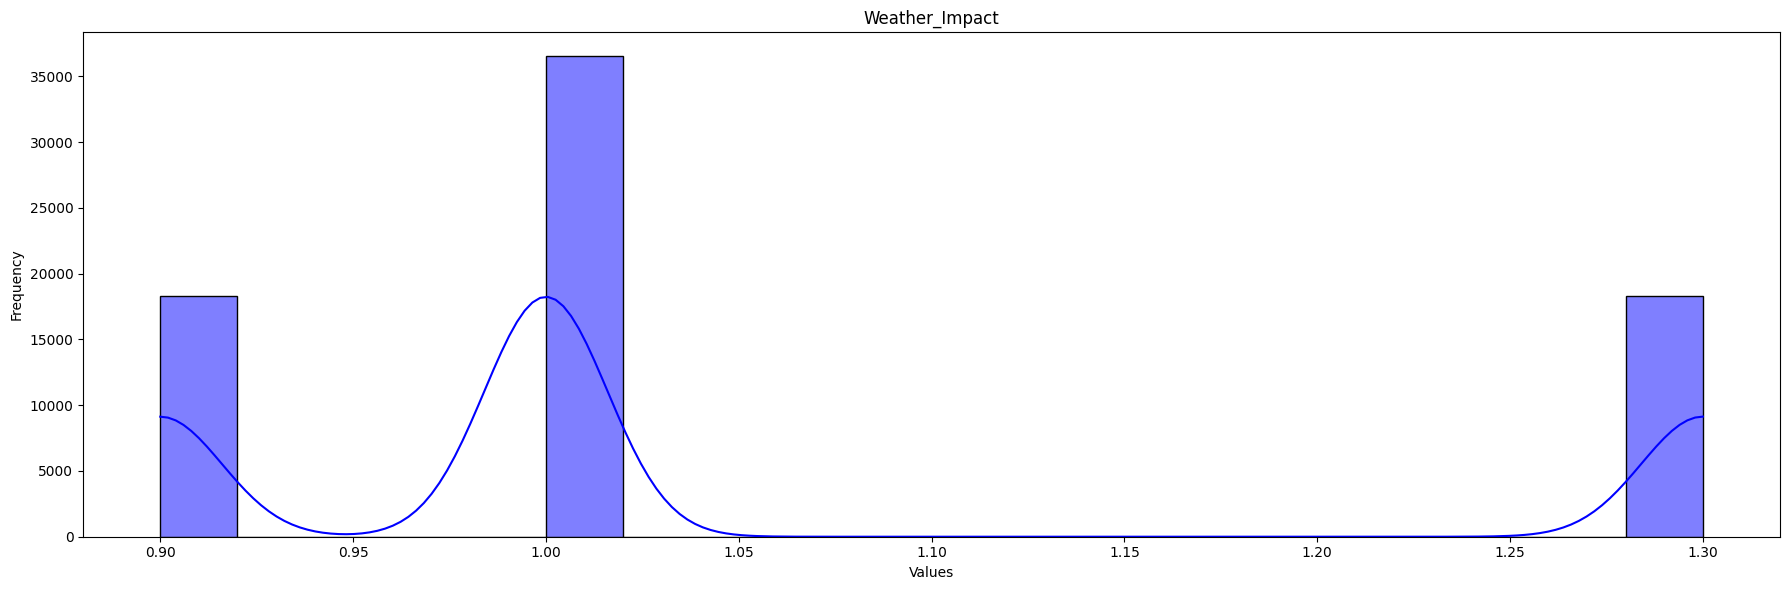

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

#Prepare data,
Weather_Impact = df_capped_3['Weather_Impact']

#Create the figure
fig, axs = plt.subplots(1,1, figsize=(18, 6), sharey=True)

#Plot WBC COUNT histogram
sns.histplot( Weather_Impact , bins=20, color='blue', edgecolor='black',kde = True, ax=axs)
axs.set_title('Weather_Impact')
axs.set_xlabel('Values')
axs.set_ylabel('Frequency')

#Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [24]:
# Drop non-numeric features for modeling
df_capped = df_capped_3.drop(columns=["Store ID", "Product ID"])
df_capped

,Date,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,...,Weekday,Is_Weekend,Demand_to_Inventory_Ratio,Demand_Variation,Price_Discounted,Price_Diff_Competitor,Historical_Discount_Impact,Seasonal_Impact,Holiday_Influence,Weather_Impact
0,2022-01-01,Groceries,North,231,127,55,135.47,33.50,20,Rainy,...,5,1,0.547414,8.47,26.8000,3.81,0.579710,1.0,0.0,0.9
72,2022-01-01,Furniture,East,191,56,65,54.47,61.81,0,Sunny,...,5,1,0.291667,-1.53,61.8100,-2.11,0.000000,1.0,0.0,1.3
71,2022-01-01,Electronics,North,349,9,165,0.95,14.25,5,Rainy,...,5,1,0.025714,-8.05,13.5375,-4.31,0.327869,1.0,1.0,0.9
70,2022-01-01,Electronics,West,205,46,27,46.65,54.84,0,Sunny,...,5,1,0.223301,0.65,54.8400,-2.92,0.000000,1.0,1.0,1.3
69,2022-01-01,Groceries,East,447,104,96,115.03,33.48,15,Cloudy,...,5,1,0.232143,11.03,28.4580,-3.67,0.435035,1.3,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73027,2024-01-01,Furniture,North,218,43,144,51.52,90.38,10,Sunny,...,0,0,0.196347,8.52,81.3420,-4.49,0.109433,1.0,0.0,1.3
73026,2024-01-01,Toys,West,53,2,40,-6.08,63.66,20,Snowy,...,0,0,0.037037,-8.08,50.9280,1.29,0.309310,1.0,1.0,1.0
73025,2024-01-01,Toys,East,160,159,78,151.48,19.06,20,Rainy,...,0,0,0.987578,-7.52,15.2480,3.47,0.997009,1.0,1.0,0.9
73035,2024-01-01,Toys,North,258,110,197,107.61,41.30,5,Cloudy,...,0,0,0.424710,-2.39,39.2350,-3.66,0.118203,1.0,0.0,1.0


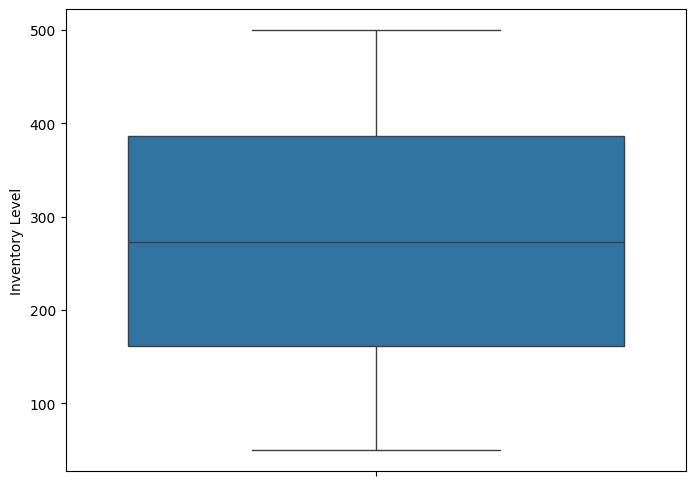

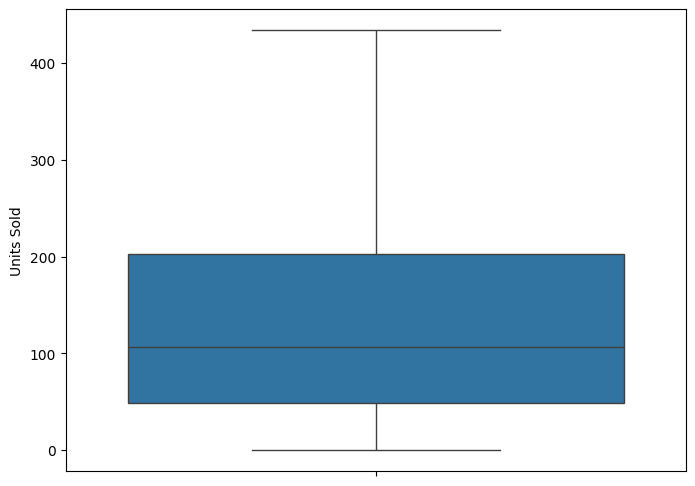

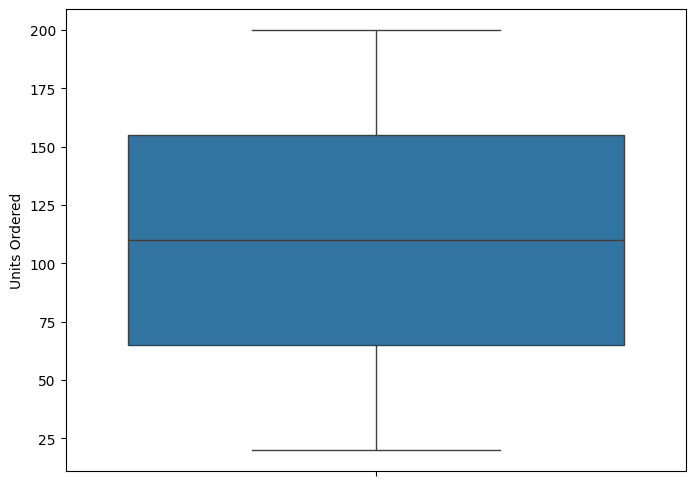

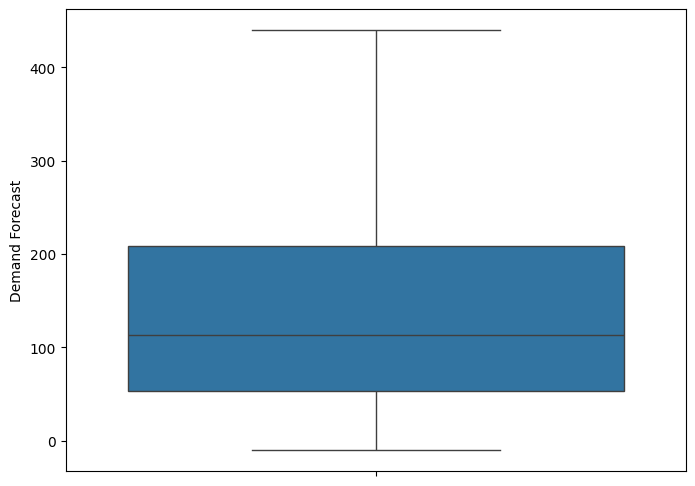

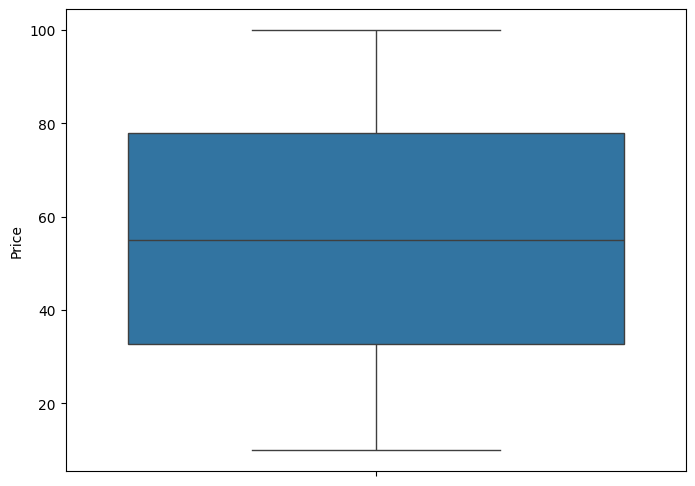

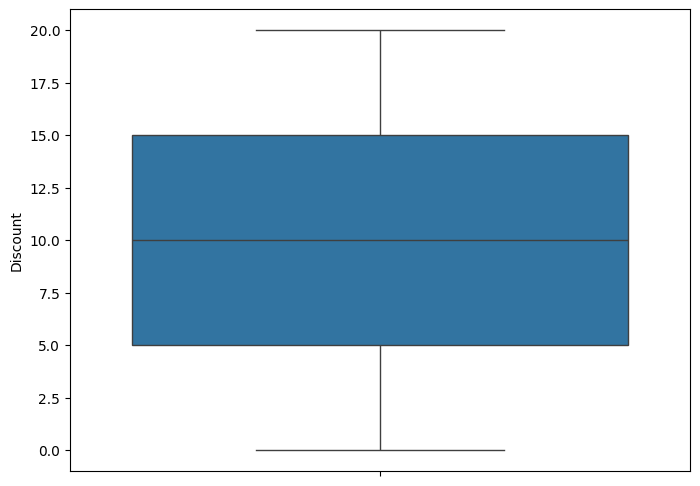

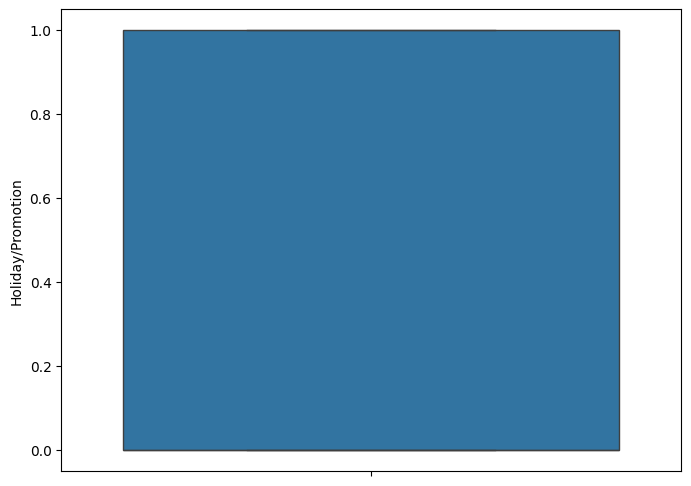

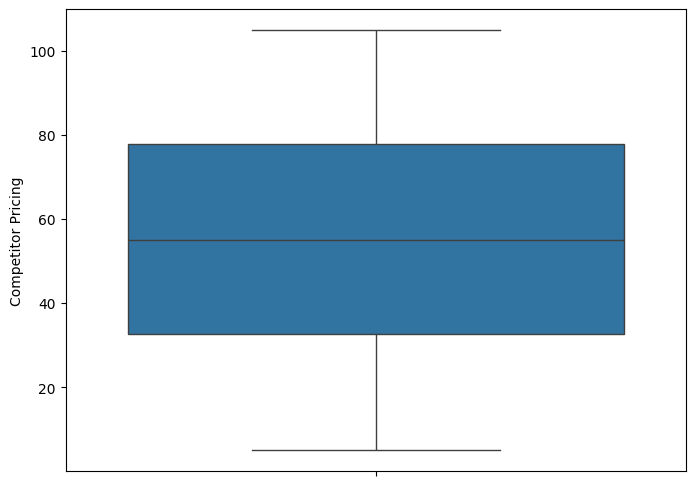

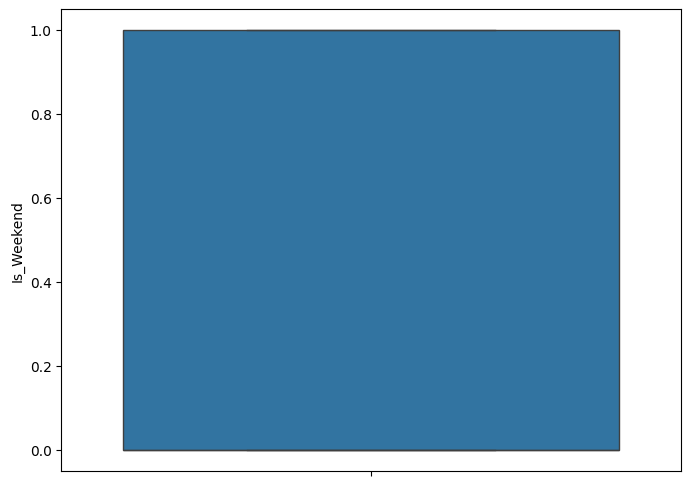

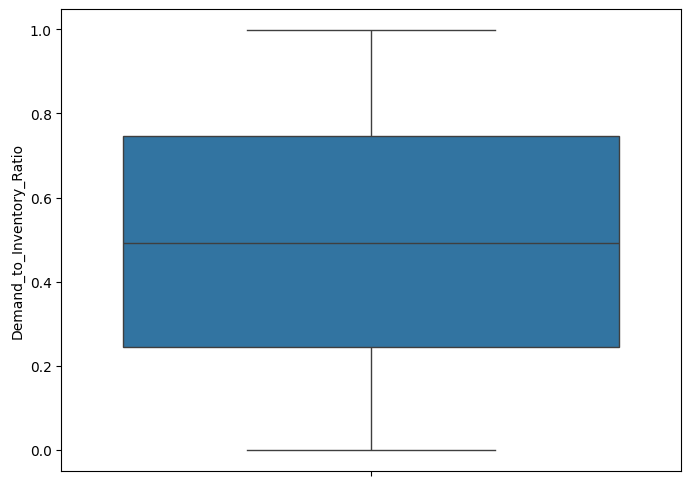

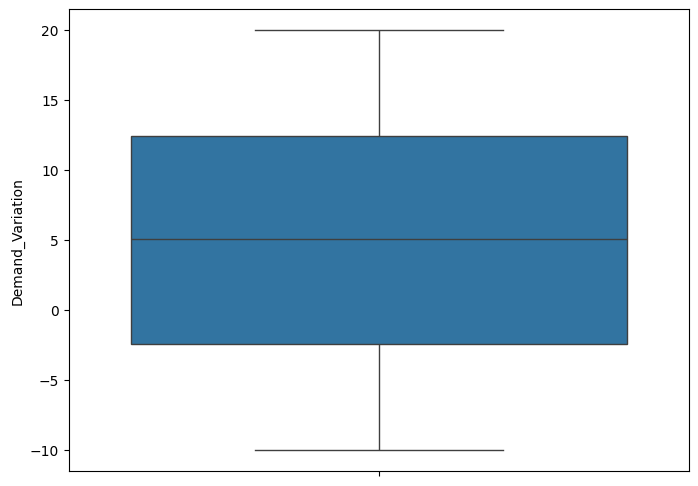

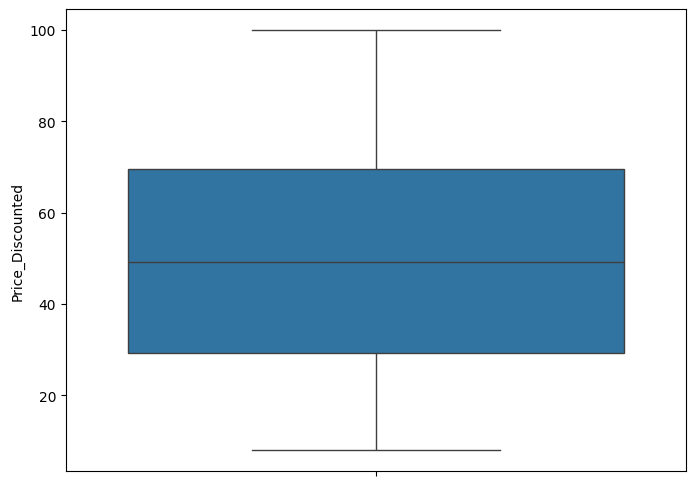

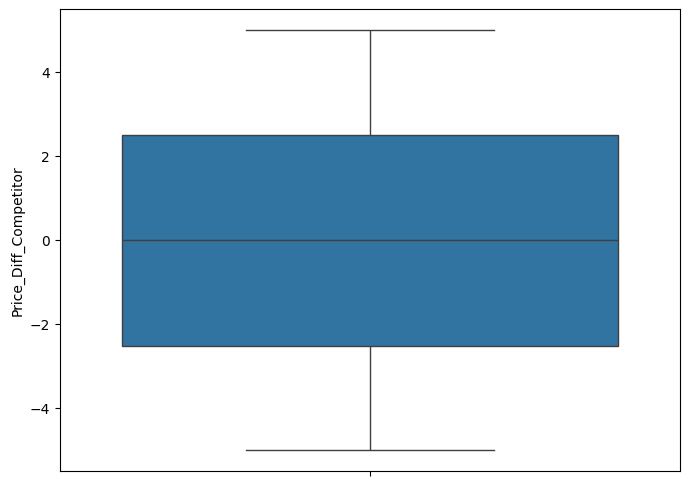

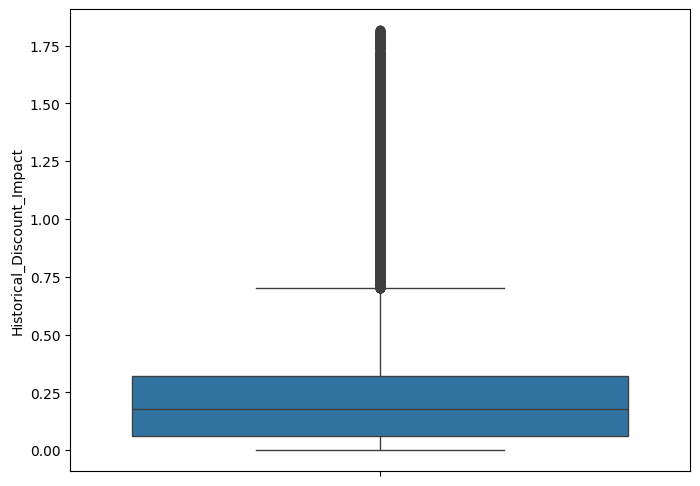

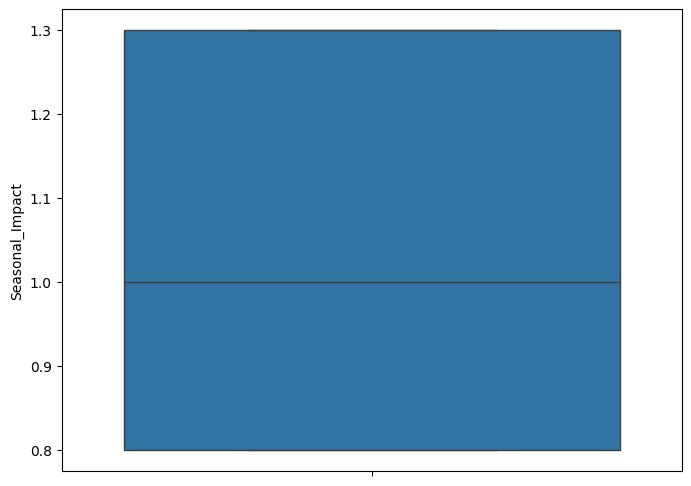

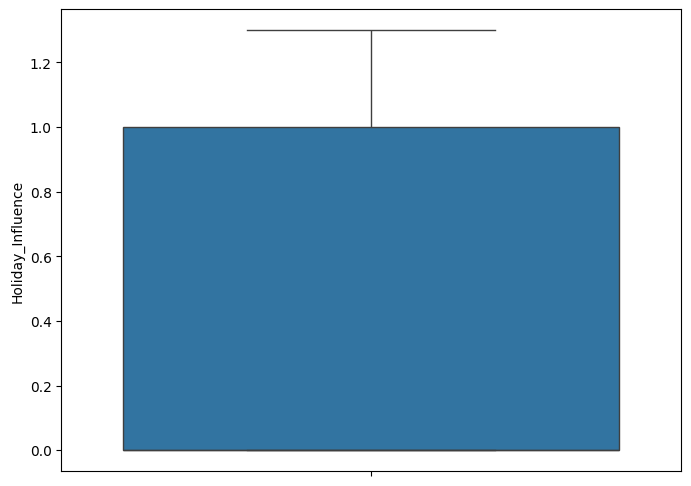

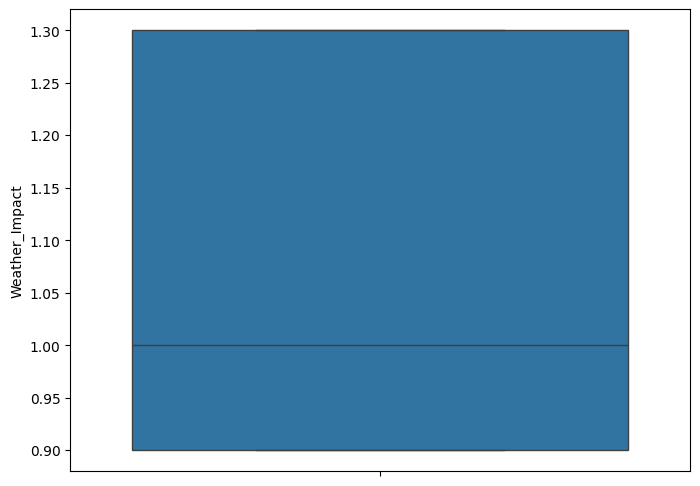

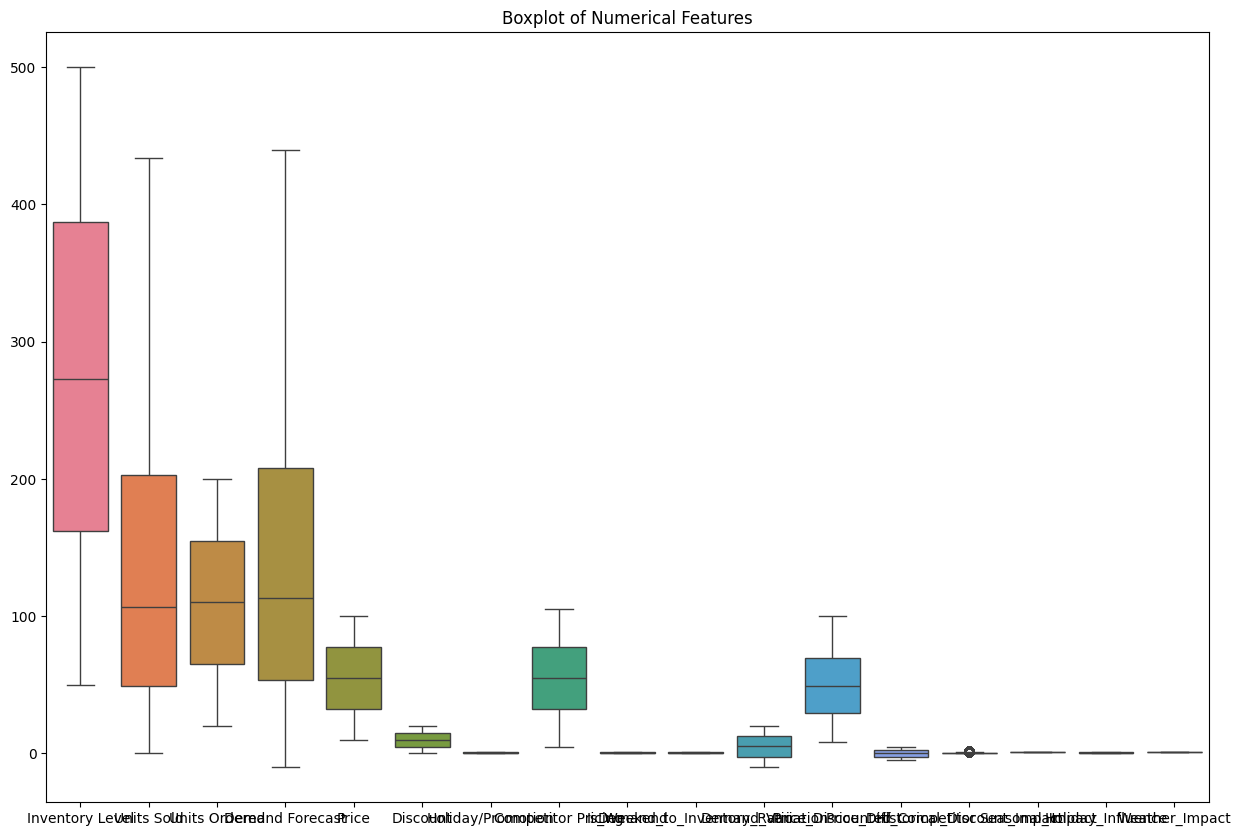

In [25]:
for column in df_capped_3.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df_capped_3[column])
    plt.show()

plt.figure(figsize=(15, 10))
sns.boxplot(data=df_capped_3.select_dtypes(include=['int64','float64']))
plt.title('Boxplot of Numerical Features')
plt.show()

         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
72 2022-01-01     S004      P0013    Furniture   East              191   
71 2022-01-01     S004      P0012  Electronics  North              349   
70 2022-01-01     S004      P0011  Electronics   West              205   
69 2022-01-01     S004      P0010    Groceries   East              447   

    Units Sold  Units Ordered  Demand Forecast  Price  ...  Weekday  \
0          127             55           135.47  33.50  ...        5   
72          56             65            54.47  61.81  ...        5   
71           9            165             0.95  14.25  ...        5   
70          46             27            46.65  54.84  ...        5   
69         104             96           115.03  33.48  ...        5   

   Is_Weekend  Demand_to_Inventory_Ratio  Demand_Variation Price_Discounted  \
0           1                   0.547414         

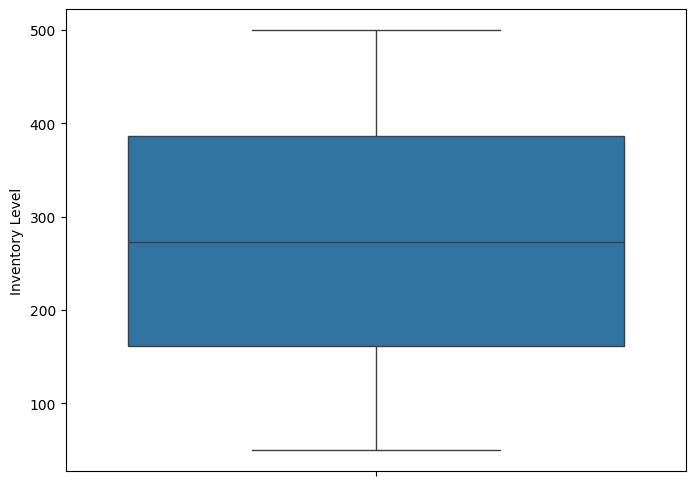

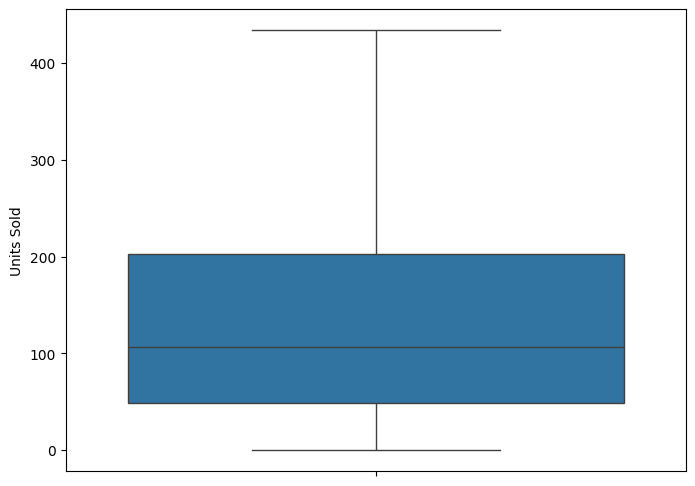

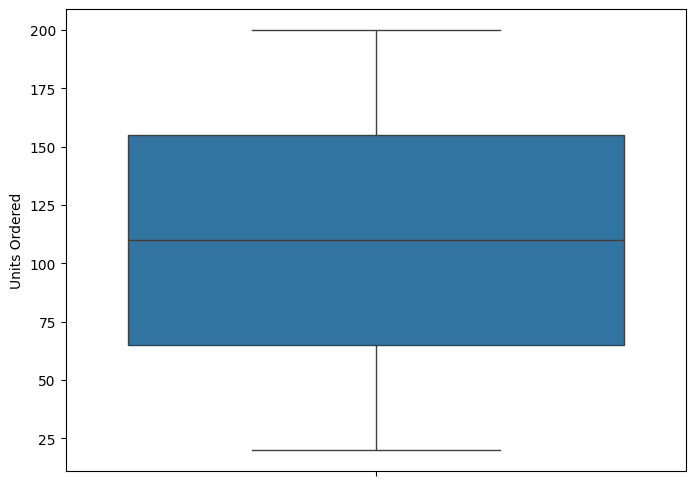

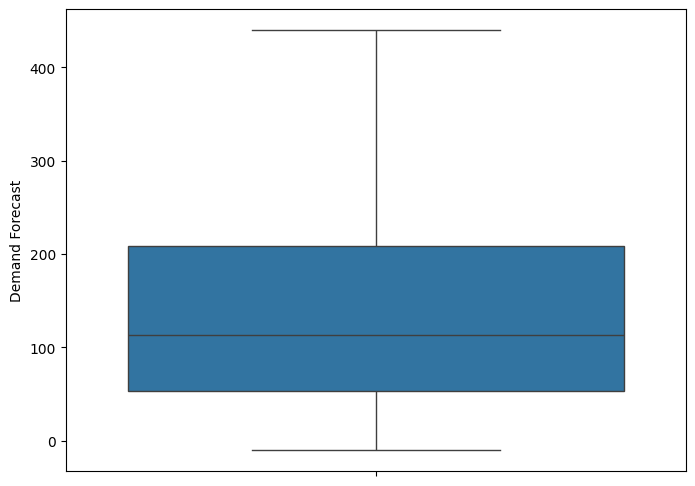

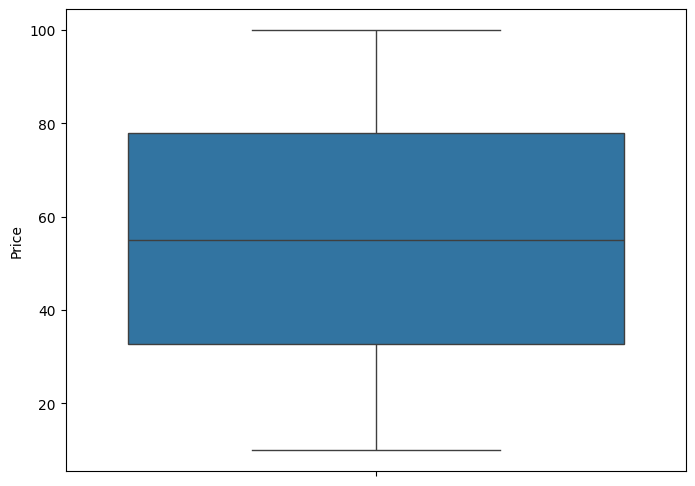

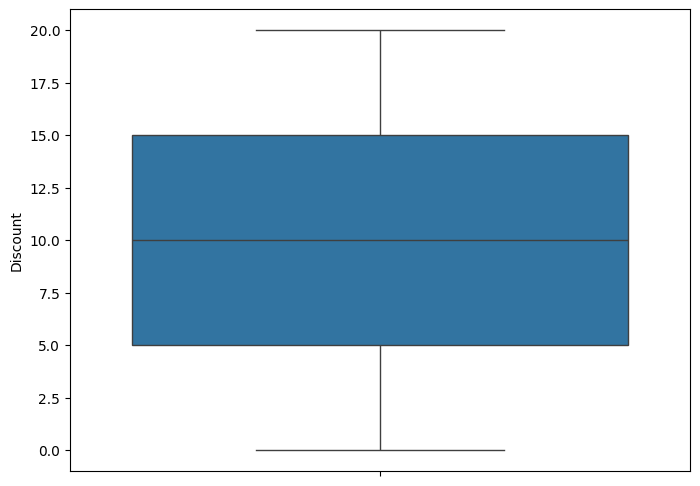

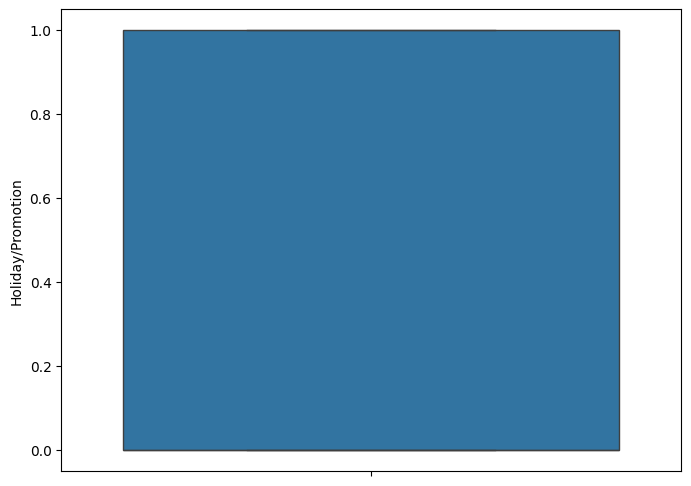

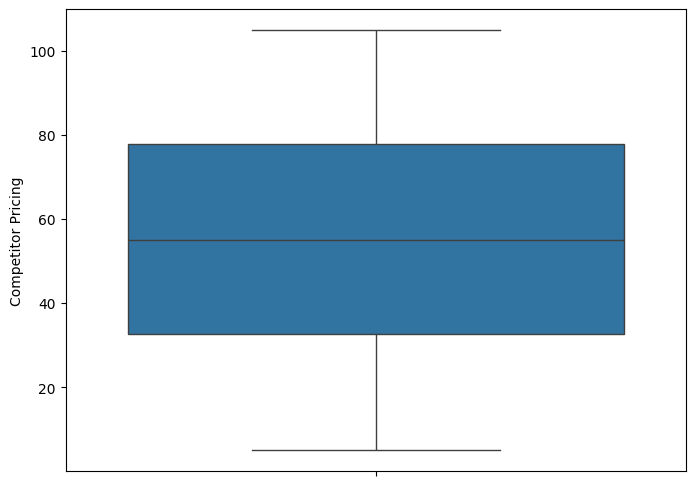

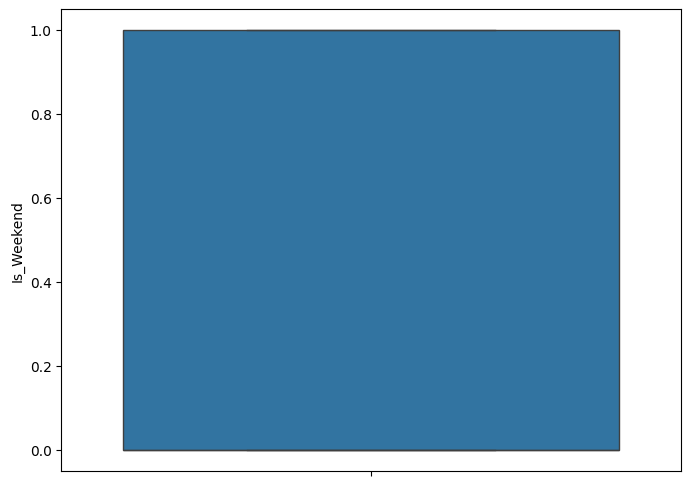

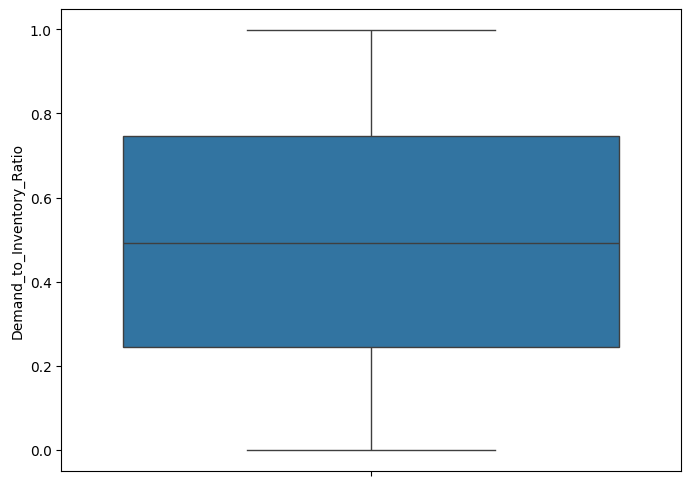

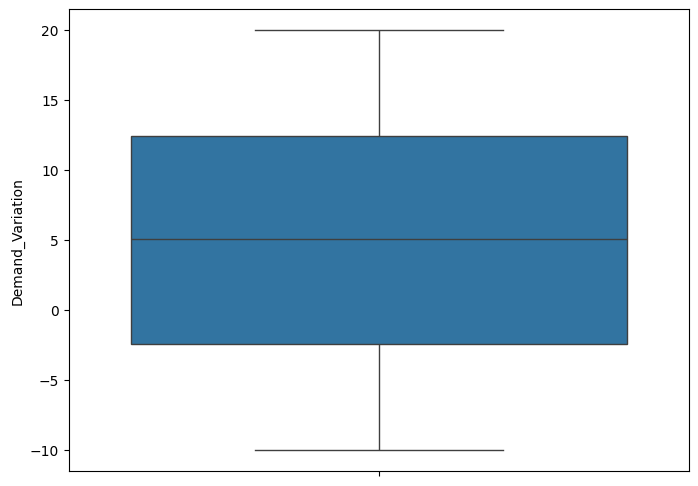

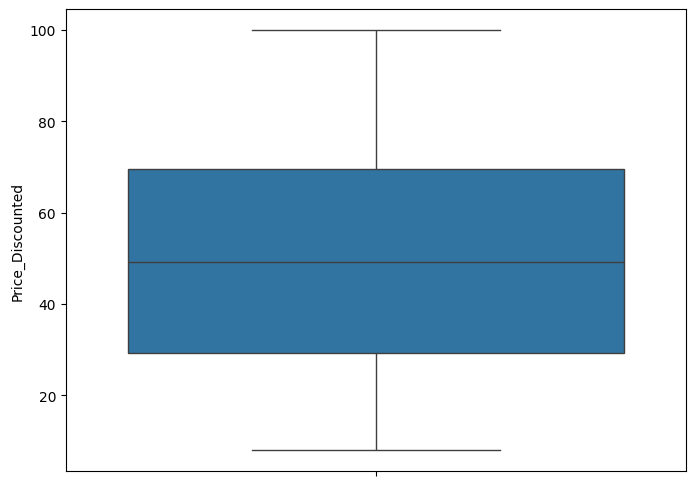

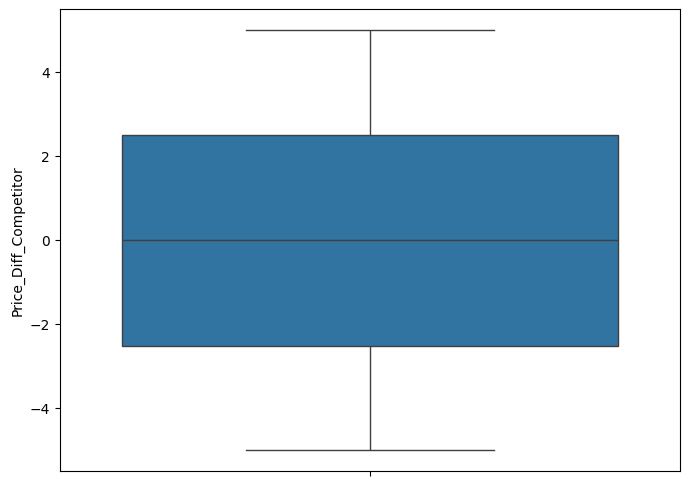

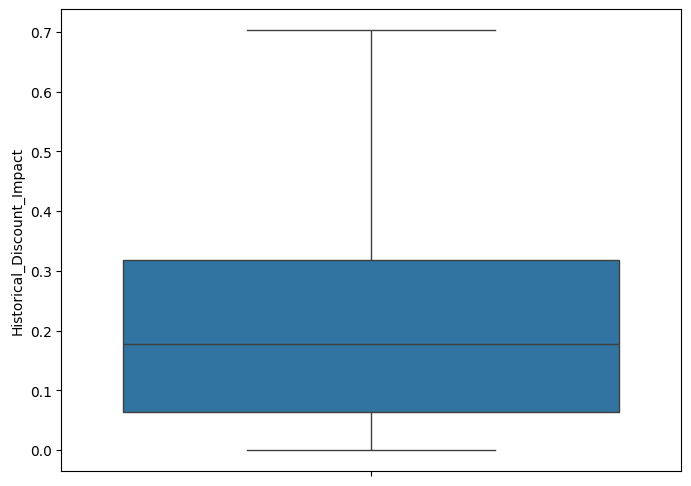

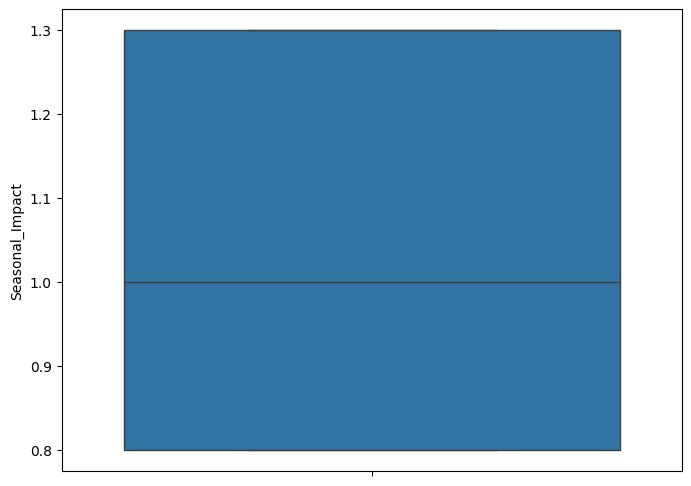

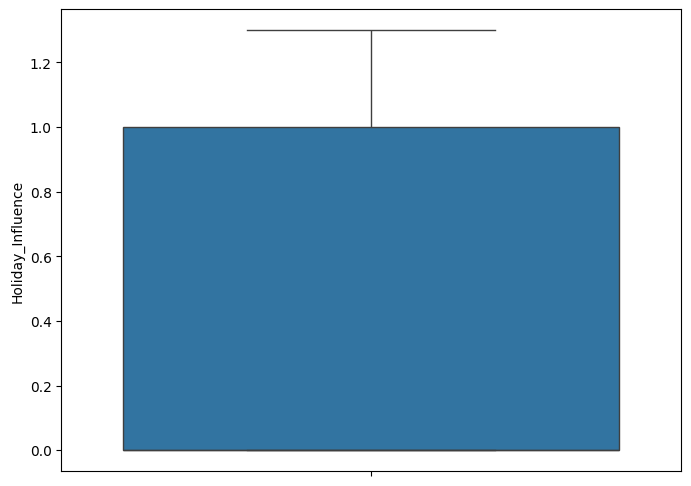

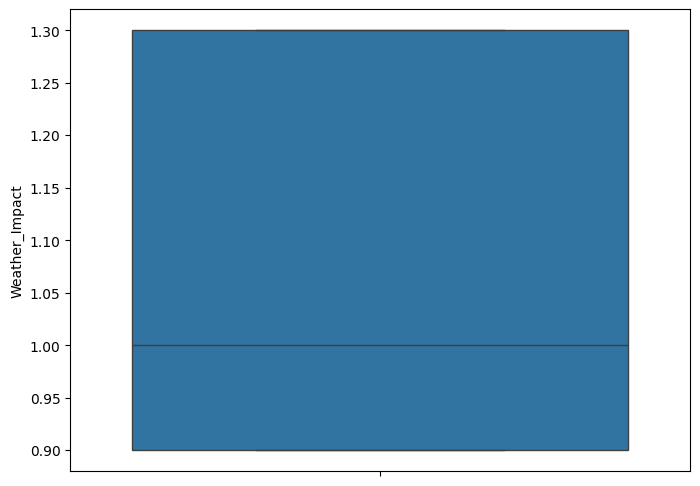

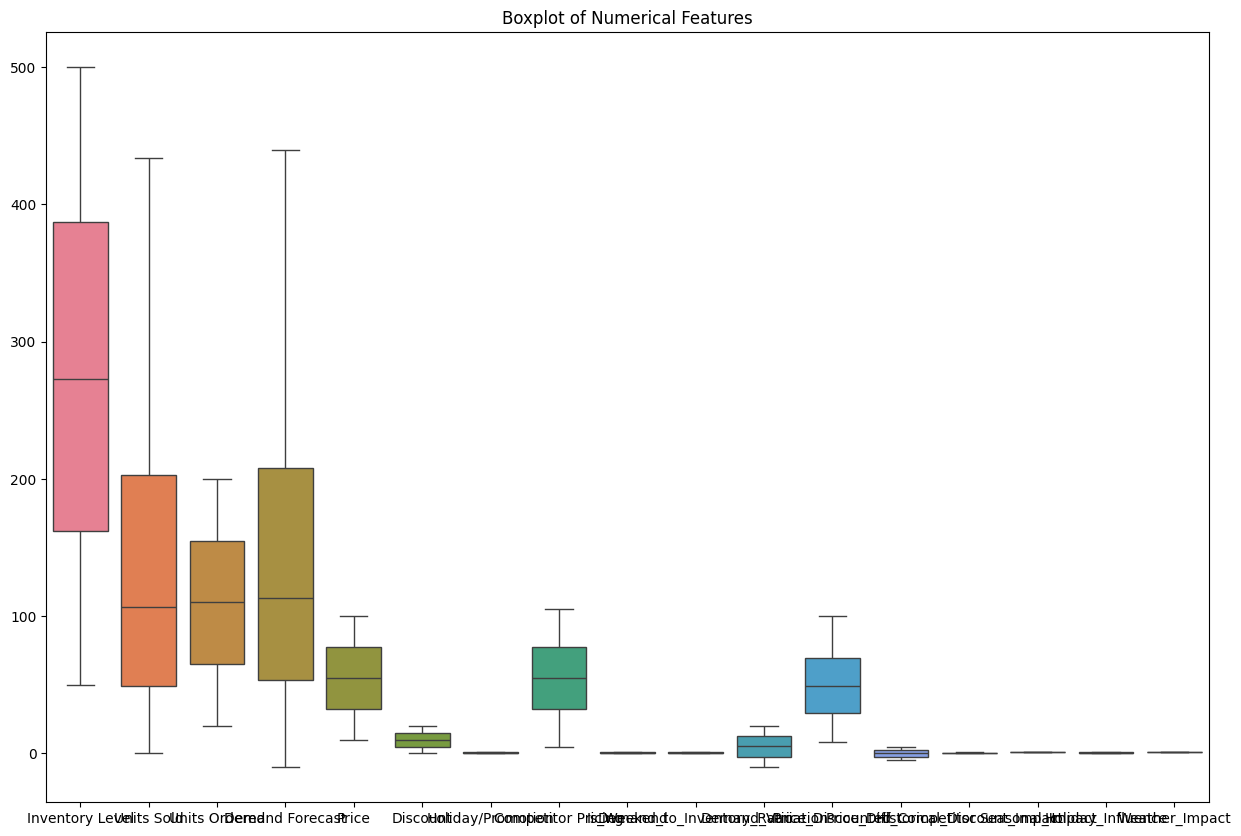

In [26]:
# Function to cap outliers using IQR (Interquartile Range)
def cap_outliers(df, columns):
    for col in columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define the lower and upper bounds for acceptable values
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap values outside the bounds to the lower or upper threshold
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df

# List of columns from which to cap outliers
columns_to_cap_outliers = ["Historical_Discount_Impact"]

# Assuming df_rename is your original DataFrame, apply the cap_outliers function
df_capped_3 = cap_outliers(df_capped_3, columns_to_cap_outliers)

# Display the first few rows of the capped DataFrame
print(df_capped_3.head())

# Generate individual boxplots for each column after capping outliers
for column in df_capped_3.select_dtypes(include=['int64','float64']).columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df_capped_3[column])
    plt.show()

# Generate a combined boxplot for all selected columns after capping outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_capped_3.select_dtypes(include=['int64','float64']))
plt.title('Boxplot of Numerical Features')
plt.show()


## 3. Scaling the numerical values

In [27]:
def apply_min_max_scaler(df, columns_to_scale):
    # """
    # Scales specified columns of a DataFrame using Min-Max Scaling.

    # Parameters:
    #     df (pd.DataFrame): The input DataFrame to scale.
    #     columns_to_scale (list): List of column names to apply Min-Max scaling.

    # Returns:
    #     pd.DataFrame: The DataFrame with scaled columns.
    # """
    from sklearn.preprocessing import MinMaxScaler
    import pandas as pd

    # Create a copy of the input DataFrame to preserve the original
    df_scaled = df.copy()

    # Initialize the scaler
    scaler = MinMaxScaler()

    # Apply scaling to each specified column
    for column in df.select_dtypes(include=['int64','float64']).columns:
        if column in df.columns:
          # Replace infinite values with NaN
            df_scaled[column] = df_scaled[column].replace([np.inf, -np.inf], np.nan)

            # Fill NaN values with the column's median
            df_scaled[column] = df_scaled[column].fillna(df_scaled[column].median())
            # Clip values to a reasonable range before scaling
            # For example, between the 1st and 99th percentiles
            lower_bound = df_scaled[column].quantile(0.01)
            upper_bound = df_scaled[column].quantile(0.99)
            df_scaled[column] = df_scaled[column].clip(lower=lower_bound, upper=upper_bound)

            df_scaled[column] = scaler.fit_transform(df_scaled[[column]]) # Changed this line: scaling the clipped and filled df_scaled
    return df_scaled

columns_to_scale = [df_capped_3.select_dtypes(include=['int64','float64']).columns]
df_scaled = apply_min_max_scaler(df_capped_3, columns_to_scale)

df_scaled

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Weekday,Is_Weekend,Demand_to_Inventory_Ratio,Demand_Variation,Price_Discounted,Price_Diff_Competitor,Historical_Discount_Impact,Seasonal_Impact,Holiday_Influence,Weather_Impact
0,2022-01-01,S001,P0001,Groceries,North,0.399093,0.290993,0.191011,0.307660,0.256291,...,5,1.0,0.552155,0.618027,0.200024,0.889683,0.824810,0.4,0.000000,0.00
72,2022-01-01,S004,P0013,Furniture,East,0.308390,0.127021,0.247191,0.123283,0.577193,...,5,1.0,0.290609,0.277891,0.608292,0.284985,0.000000,0.4,0.000000,1.00
71,2022-01-01,S004,P0012,Electronics,North,0.666667,0.018476,0.808989,0.001457,0.038087,...,5,1.0,0.018627,0.056122,0.045364,0.060266,0.466491,0.4,0.769231,0.00
70,2022-01-01,S004,P0011,Electronics,West,0.340136,0.103926,0.033708,0.105482,0.498186,...,5,1.0,0.220694,0.352041,0.527011,0.202247,0.000000,0.4,0.769231,1.00
69,2022-01-01,S004,P0010,Groceries,East,0.888889,0.237875,0.421348,0.261133,0.256064,...,5,1.0,0.229736,0.705102,0.219358,0.125638,0.618966,1.0,0.000000,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73027,2024-01-01,S002,P0008,Furniture,North,0.369615,0.096998,0.691011,0.116568,0.901043,...,0,0.0,0.193129,0.619728,0.836063,0.041879,0.155701,0.4,0.000000,1.00
73026,2024-01-01,S002,P0007,Toys,West,0.000000,0.002309,0.106742,0.000000,0.598164,...,0,0.0,0.030207,0.055102,0.481392,0.632278,0.440086,0.4,0.769231,0.25
73025,2024-01-01,S002,P0006,Toys,East,0.238095,0.364896,0.320225,0.344103,0.092609,...,0,0.0,1.000000,0.074150,0.065311,0.854954,1.000000,0.4,0.769231,0.00
73035,2024-01-01,S002,P0016,Toys,North,0.460317,0.251732,0.988764,0.244243,0.344706,...,0,0.0,0.426670,0.248639,0.345034,0.126660,0.168179,0.4,0.000000,0.25


## 4. Label Encoding the categorical values

In [28]:
def Lebel_Encoding(df):
    from sklearn.preprocessing import LabelEncoder
    df_Encoded = df.copy()
    for column in df.select_dtypes(include=['object','category']).columns:


            encoder = LabelEncoder()
            df_Encoded[column] = encoder.fit_transform(df[column])
    return df_Encoded

df_encoded = Lebel_Encoding(df_scaled)
df_encoded

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Weekday,Is_Weekend,Demand_to_Inventory_Ratio,Demand_Variation,Price_Discounted,Price_Diff_Competitor,Historical_Discount_Impact,Seasonal_Impact,Holiday_Influence,Weather_Impact
0,2022-01-01,0,0,3,1,0.399093,0.290993,0.191011,0.307660,0.256291,...,5,1.0,0.552155,0.618027,0.200024,0.889683,0.824810,0.4,0.000000,0.00
72,2022-01-01,3,12,2,0,0.308390,0.127021,0.247191,0.123283,0.577193,...,5,1.0,0.290609,0.277891,0.608292,0.284985,0.000000,0.4,0.000000,1.00
71,2022-01-01,3,11,1,1,0.666667,0.018476,0.808989,0.001457,0.038087,...,5,1.0,0.018627,0.056122,0.045364,0.060266,0.466491,0.4,0.769231,0.00
70,2022-01-01,3,10,1,3,0.340136,0.103926,0.033708,0.105482,0.498186,...,5,1.0,0.220694,0.352041,0.527011,0.202247,0.000000,0.4,0.769231,1.00
69,2022-01-01,3,9,3,0,0.888889,0.237875,0.421348,0.261133,0.256064,...,5,1.0,0.229736,0.705102,0.219358,0.125638,0.618966,1.0,0.000000,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73027,2024-01-01,1,7,2,1,0.369615,0.096998,0.691011,0.116568,0.901043,...,0,0.0,0.193129,0.619728,0.836063,0.041879,0.155701,0.4,0.000000,1.00
73026,2024-01-01,1,6,4,3,0.000000,0.002309,0.106742,0.000000,0.598164,...,0,0.0,0.030207,0.055102,0.481392,0.632278,0.440086,0.4,0.769231,0.25
73025,2024-01-01,1,5,4,0,0.238095,0.364896,0.320225,0.344103,0.092609,...,0,0.0,1.000000,0.074150,0.065311,0.854954,1.000000,0.4,0.769231,0.00
73035,2024-01-01,1,15,4,1,0.460317,0.251732,0.988764,0.244243,0.344706,...,0,0.0,0.426670,0.248639,0.345034,0.126660,0.168179,0.4,0.000000,0.25


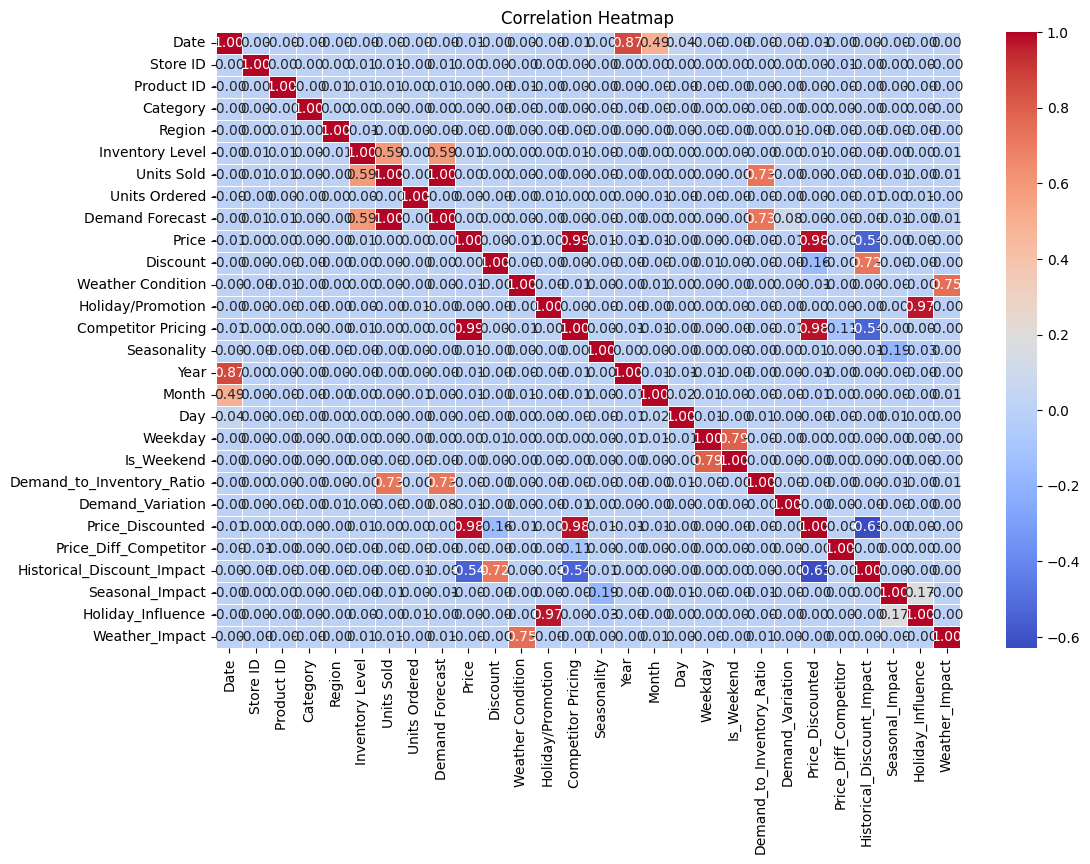

In [29]:
#Calculate the correlation matrix for numerical features
corr_matrix = df_encoded.corr()

# Step 4: Generate a heatmap to visualize feature relationships
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 5. Train Test Split

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

def train_test_splitting(df, target_column):
    df = df.sort_values(by="Date")  # Ensure data is sorted by time

    # Separate features (X) and target (y)
    X = df.drop(columns=[target_column, "Date"])  # Drop target and Date
    y = df[target_column]

    # Split dataset (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    return X_train, X_test, y_train, y_test

## 6. Model Train

*   Linear Regression
*   Decision Tree
*   Random Forest
*   Gradient Boosting
*   XGBoost
*   LightGBM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



def evaluate_model(y_test, y_pred, model_name):
    """Evaluates and prints model performance metrics."""
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n Model: {model_name}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")



def perform_kfold_cv(model, X, y, k=5):
    """Perform K-Fold Cross-Validation on a given model."""
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

    print(f"\nModel: {type(model).__name__}")
    print(f"R² Scores per Fold: {scores}")
    print(f"Mean R² Score: {np.mean(scores):.4f}")
    print(f"Standard Deviation: {np.std(scores):.4f}\n")



def tune_hyperparameters(model, param_grid, X_train, y_train):
    """Performs Randomized Search CV for the given model."""
    random_search = RandomizedSearchCV(model, param_grid, n_iter=10, scoring='r2',
                                       cv=5, verbose=1, n_jobs=-1, random_state=42)
    random_search.fit(X_train, y_train)

    print(f"\nBest Parameters for {type(model).__name__}: {random_search.best_params_}")
    return random_search.best_estimator_



# Define Hyperparameter Grid for Each Model
param_grids = {
    "Decision Tree": {"max_depth": [5, 10, 20, None]},
    "Random Forest": {"n_estimators": [100, 200, 300], "max_depth": [10, 20, None]},
    "Gradient Boosting": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 6]},
    "XGBoost": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 6]},
    "LightGBM": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 6]}
}

# Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_splitting(df_encoded, target_column="Price")

# Apply K-Fold Cross Validation & Hyperparameter Tuning
best_models = {}

for model_name, model in models.items():
    print(f"\n\n Training {model_name}...")

    if model_name in param_grids:  # Perform Hyperparameter Tuning if parameters exist
        model = tune_hyperparameters(model, param_grids[model_name], X_train, y_train)

    perform_kfold_cv(model, X_train, y_train, k=5)  # K-Fold CV
    model.fit(X_train, y_train)  # Train Best Model
    y_pred = model.predict(X_test)  # Predictions

    evaluate_model(y_test, y_pred, model_name)  # Evaluate Performance
    best_models[model_name] = model  # Store Best Model






 Training Linear Regression...

Model: LinearRegression
R² Scores per Fold: [0.99993785 0.99993039 0.9999332  0.9999305  0.99993338]
Mean R² Score: 0.9999
Standard Deviation: 0.0000


 Model: Linear Regression
Mean Absolute Error (MAE): 0.0008
Mean Squared Error (MSE): 0.0000
Root Mean Squared Error (RMSE): 0.0026
R² Score: 0.9999


 Training Decision Tree...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best Parameters for DecisionTreeRegressor: {'max_depth': 20}

Model: DecisionTreeRegressor
R² Scores per Fold: [0.99994292 0.99994006 0.99993971 0.99994514 0.99994076]
Mean R² Score: 0.9999
Standard Deviation: 0.0000


 Model: Decision Tree
Mean Absolute Error (MAE): 0.0013
Mean Squared Error (MSE): 0.0000
Root Mean Squared Error (RMSE): 0.0020
R² Score: 1.0000


 Training Random Forest...
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [ ]:
def plot_learning_curve(model, X_train, y_train, model_name):
    """Generates and plots the learning curve for a given model."""
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores_mean, "o-", color="r", label="Training Loss")
    plt.plot(train_sizes, test_scores_mean, "o-", color="g", label="Validation Loss")
    plt.xlabel("Training Examples")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Learning Curve: {model_name}")
    plt.legend()
    plt.grid()
    plt.show()

# Plot Learning Curves for Best Models
for model_name, model in best_models.items():
    plot_learning_curve(model, X_train, y_train, model_name)


## **Optimum Price Recommendations**


*   Using Content-Based Filtering + Rule-Based Adjustment




In [ ]:
def recommend_price(input_data, features=X_train.columns): # Set features as a parameter with a default value
    """
    Generate a recommended price based on the trained model.
    """
    predicted_price = best_models["Random Forest"].predict(input_data[features])
    recommended_price = np.where(input_data["Demand_to_Inventory_Ratio"] > 1,
                                 predicted_price * 1.1,  # Increase price if demand is high
                                 predicted_price * 0.9)  # Decrease price if demand is low
    return recommended_price

# Generate and display recommendations
sample_data = X_test.copy()
# Adding the 'Price' column back to sample_data from y_test
sample_data["Price"] = y_test.values * 100
sample_data["Recommended_Price"] = recommend_price(sample_data) * 100 # No need to pass features here if using the default
print("\nPrice Recommendations:")
print(sample_data[["Price", "Recommended_Price"]].head(30)) # Changed 'Pricing' to 'Price'


Price Recommendations:
           Price  Recommended_Price
58479  67.161641          60.397325
58480  27.363410          24.621628
58481  11.856722          10.667275
58482  27.828157          25.045375
58483  99.807300          89.319168
58484  89.605532          80.632906
58485  86.182272          77.581387
58487  66.742235          60.107289
58476  96.043981          86.444956
58475  79.381093          71.386092
58490  71.219678          64.020381
58491  18.306506          16.473883
58492  44.819769          40.335616
58493  52.981183          47.734108
58494  25.697121          23.125538
58495  17.864430          16.076797
58496  19.712083          17.743630
58497  92.110633          82.882702
58498  41.611879          37.361766
58489  13.931081          12.537905
58507  22.693267          20.429789
58506  41.974609          37.794491
58505  23.792791          21.411879
58500  72.455226          65.219429
58503  43.946951          39.502233
58502  54.998866          49.538801
5850

In [ ]:
sample_data

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Discount,Weather Condition,...,Demand_to_Inventory_Ratio,Demand_Variation,Price_Discounted,Price_Diff_Competitor,Historical_Discount_Impact,Seasonal_Impact,Holiday_Influence,Weather_Impact,Price,Recommended_Price
58479,3,19,3,1,0.653061,0.632794,0.882022,0.644456,0.25,2,...,0.809873,0.616667,0.664535,0.457610,0.100000,0.4,0.769231,0.25,67.161641,60.397325
58480,4,0,3,0,0.632653,0.180139,0.280899,0.168421,0.75,2,...,0.233498,0.170068,0.234722,0.465781,0.592339,0.4,0.769231,0.25,27.363410,24.621628
58481,4,1,0,3,0.793651,0.630485,0.365169,0.621284,0.50,3,...,0.682508,0.304422,0.111572,0.935649,0.636598,0.4,0.000000,1.00,11.856722,10.667275
58482,4,2,0,0,0.489796,0.457275,0.994382,0.434015,1.00,0,...,0.740535,0.057143,0.218122,0.519918,0.780899,0.0,0.000000,0.25,27.828157,25.045375
58483,4,3,1,1,0.210884,0.080831,0.471910,0.064236,0.75,2,...,0.239419,0.075850,0.868214,0.061287,0.213548,0.0,0.615385,0.25,99.807300,89.319168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,4,15,2,0,0.092971,0.016166,0.595506,0.041314,1.00,2,...,0.076674,0.685714,0.575336,0.631256,0.380783,0.0,0.000000,0.25,71.231013,64.115461
73096,4,16,4,1,0.585034,0.115473,0.449438,0.109534,0.50,0,...,0.158433,0.242517,0.754095,0.376915,0.170252,0.4,0.000000,0.25,81.251417,72.994842
73050,2,10,4,3,0.185941,0.247113,0.140449,0.223279,1.00,0,...,0.792682,0.003401,0.246017,0.003064,0.721683,0.4,0.769231,0.25,31.217411,28.098288
73074,3,14,4,1,0.002268,0.011547,0.713483,0.000000,1.00,1,...,0.099980,0.102721,0.213085,0.826353,0.792645,0.0,0.000000,0.00,27.216051,24.494854


## 8. X-AI

*   SHAP
*   LIME

In [ ]:
!pip install lime shap
import lime
import lime.lime_tabular
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import shap

import xgboost as xgb
from lime import lime_tabular

In [ ]:
shap.initjs()
# Create the SHAP explainer and calculate SHAP values
explainer_rf = shap.TreeExplainer(best_models["Random Forest"])
shap_values_rf = explainer_rf.shap_values(X_train)

# Visualize the first prediction's explanation
shap.force_plot(explainer_rf.expected_value, shap_values_rf[0,:], X_train.iloc[0,:])

In [ ]:
# Create the SHAP explainer
explainer = shap.TreeExplainer(best_models["Random Forest"])
shap_values = explainer.shap_values(X_train)

# Generate SHAP summary plot
shap.summary_plot(shap_values, X_train, plot_type="bar")

# You can also create a detailed SHAP summary plot (beeswarm plot) to see the distribution
shap.summary_plot(shap_values, X_train, plot_type='dot')

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    mode='regression'
)

# Choose a test sample to explain (Index 10 as an example)
sample_index = 10
exp = explainer.explain_instance(X_test.iloc[sample_index].values, best_models["Random Forest"].predict, num_features=5)

# Display the LIME Table Plot
exp.show_in_notebook(show_table=True)

# **Unsupervised Learning**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

##Preprocess

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Assuming df_capped_4 is already defined with the dataset
# Split the features into categorical and numerical
categorical_features = df_capped_4.select_dtypes(include=['object']).columns
numerical_features = df_capped_4.select_dtypes(include=['int64', 'float64']).columns

# Standard scaling for numerical features only
scaler = StandardScaler()
scaled_numerical_data = scaler.fit_transform(df_capped_4[numerical_features])

# One-hot encoding for categorical features only
# The 'sparse' parameter is removed for compatibility with older versions
# If using a newer version, you might need to adjust this
encoder = OneHotEncoder(drop='first')
encoded_categorical_data = encoder.fit_transform(df_capped_4[categorical_features]).toarray()
# toarray() is added to convert the sparse matrix to a dense array if needed

# Concatenate the scaled numerical and encoded categorical data
processed_data = np.hstack([scaled_numerical_data, encoded_categorical_data])

# Convert to DataFrame with appropriate column names
final_columns = numerical_features.tolist() + encoder.get_feature_names_out(categorical_features).tolist()
processed_data_df_capped_4 = pd.DataFrame(processed_data, columns=final_columns)

# Save processed data to CSV
processed_data_df_capped_4.to_csv('processed_data.csv', index=False)

# Display the first few rows of the processed DataFrame
processed_data_df_capped_4.head()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing,Store ID_S002,Store ID_S003,...,Category_Toys,Region_North,Region_South,Region_West,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,-0.334516,-0.085357,-1.052172,-0.053402,-0.831423,1.410350,-0.994625,-0.971931,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.642330,-0.741102,-0.860883,-0.799249,0.256512,-1.413034,-0.994625,0.334995,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.573535,-1.175186,1.052001,-1.292060,-1.571189,-0.707188,1.005404,-1.396883,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.534595,-0.833460,-1.587779,-0.871255,-0.011341,-1.413034,1.005404,0.099801,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,1.327679,-0.297782,-0.267889,-0.241613,-0.832192,0.704504,-0.994625,-0.687103,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
processed_data_df_capped_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Inventory Level          73100 non-null  float64
 1   Units Sold               73100 non-null  float64
 2   Units Ordered            73100 non-null  float64
 3   Demand Forecast          73100 non-null  float64
 4   Price                    73100 non-null  float64
 5   Discount                 73100 non-null  float64
 6   Holiday/Promotion        73100 non-null  float64
 7   Competitor Pricing       73100 non-null  float64
 8   Store ID_S002            73100 non-null  float64
 9   Store ID_S003            73100 non-null  float64
 10  Store ID_S004            73100 non-null  float64
 11  Store ID_S005            73100 non-null  float64
 12  Product ID_P0002         73100 non-null  float64
 13  Product ID_P0003         73100 non-null  float64
 14  Product ID_P0004      

###Apply Clustering

**Elbow Method**
The Elbow Method can help identify the optimal number of clusters for K-Means by plotting the Within-Cluster Sum of Squares (WCSS) for different values of
𝑘
k and looking for an "elbow" point where the rate of decrease sharply diminishes. This point suggests a good balance between cluster compactness and complexity.

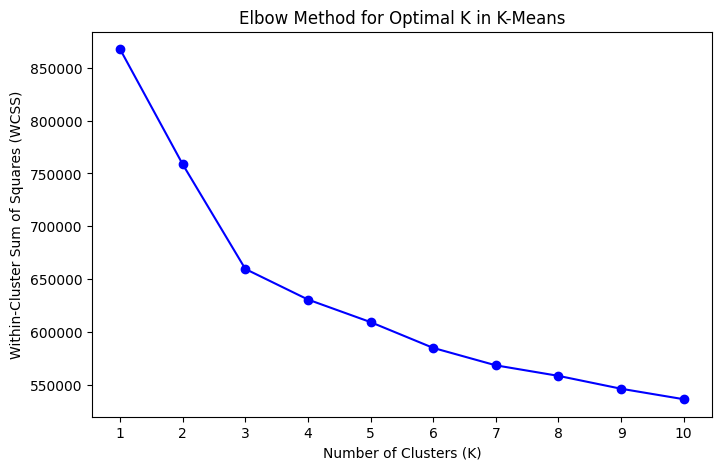

In [ ]:
# Calculate WCSS for a range of K values to use the Elbow Method
wcss = []
k_range = range(1, 11)  # Range of K values from 1 to 10

# Iterate through each k and calculate WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(processed_data_df_capped_4)
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title("Elbow Method for Optimal K in K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.xticks(k_range)
plt.show()


In [ ]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Define number of clusters for K-Means
n_clusters = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
processed_data_df_capped_4['KMeans_Cluster'] = kmeans.fit_predict(processed_data_df_capped_4)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
processed_data_df_capped_4['DBSCAN_Cluster'] = dbscan.fit_predict(processed_data_df_capped_4)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster']))
processed_data_df_capped_4['PCA1'] = pca_result[:, 0]
processed_data_df_capped_4['PCA2'] = pca_result[:, 1]

# Calculate evaluation scores only if DBSCAN has more than one cluster
silhouette_kmeans = silhouette_score(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']),
                                     processed_data_df_capped_4['KMeans_Cluster'])

# Check for the number of clusters in DBSCAN, DBSCAN assigns -1 to noise points, so we count unique labels
unique_dbscan_labels = len(set(processed_data_df_capped_4['DBSCAN_Cluster']) - {-1})  # Exclude noise (-1) label
silhouette_dbscan = None
dbi_dbscan = None

if unique_dbscan_labels > 1:
    silhouette_dbscan = silhouette_score(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']),
                                         processed_data_df_capped_4['DBSCAN_Cluster'])
    dbi_dbscan = davies_bouldin_score(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']),
                                      processed_data_df_capped_4['DBSCAN_Cluster'])
else:
    print("DBSCAN has only one cluster or all points are labeled as noise, skipping DBSCAN evaluation.")

dbi_kmeans = davies_bouldin_score(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']),
                                  processed_data_df_capped_4['KMeans_Cluster'])

# Print evaluation scores
print(f"Silhouette Score (K-Means): {silhouette_kmeans}")
if silhouette_dbscan is not None:
    print(f"Silhouette Score (DBSCAN): {silhouette_dbscan}")
else:
    print("Silhouette Score (DBSCAN): Not available")

if dbi_dbscan is not None:
    print(f"Davies-Bouldin Index (DBSCAN): {dbi_dbscan}")
else:
    print("Davies-Bouldin Index (DBSCAN): Not available")

print(f"Davies-Bouldin Index (K-Means): {dbi_kmeans}")


DBSCAN has only one cluster or all points are labeled as noise, skipping DBSCAN evaluation.
Silhouette Score (K-Means): 0.1249215546550449
Silhouette Score (DBSCAN): Not available
Davies-Bouldin Index (DBSCAN): Not available
Davies-Bouldin Index (K-Means): 2.1846459230640702


DBSCAN (Density-Based Spatial Clustering of Applications with Noise) can label all data points as noise if the eps parameter is too small or the dataset does not contain sufficiently dense clusters. When this happens, the algorithm assigns all points to the same cluster or labels them as noise (-1), making it impossible to compute the evaluation metrics that require multiple clusters.

##PCA

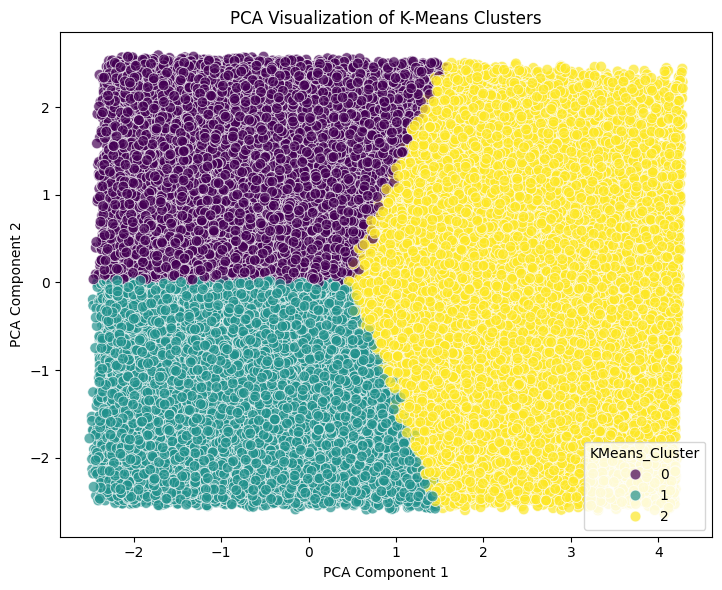

In [ ]:
# Plot PCA visualization for K-Means and DBSCAN clusters
plt.figure(figsize=(14, 6))

# Plot for K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(data=processed_data_df_capped_4, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.tight_layout()
plt.show()


##GMM

Silhouette Score (GMM): 0.0049672964954655075
Davies-Bouldin Index (GMM): 13.017613088101939


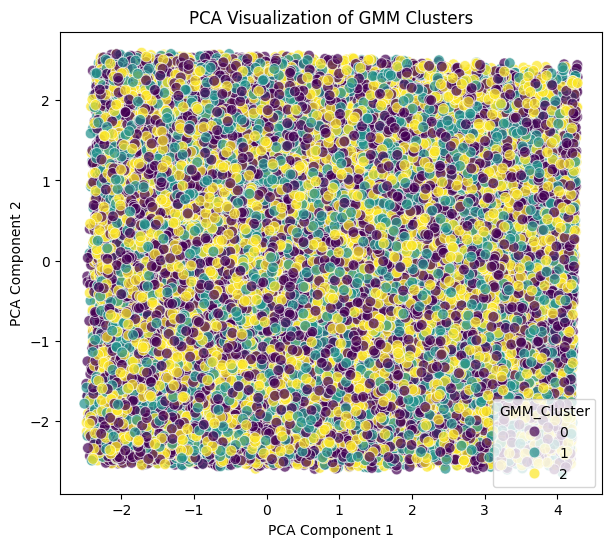

In [ ]:
from sklearn.mixture import GaussianMixture

# Apply Gaussian Mixture Model with the same number of clusters as K-Means (6 clusters)
gmm = GaussianMixture(n_components=3, random_state=42)
processed_data_df_capped_4['GMM_Cluster'] = gmm.fit_predict(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2']))

# Calculate silhouette and Davies-Bouldin scores for GMM
silhouette_gmm = silhouette_score(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster', 'PCA1', 'PCA2']),
                                  processed_data_df_capped_4['GMM_Cluster'])
dbi_gmm = davies_bouldin_score(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster', 'PCA1', 'PCA2']),
                               processed_data_df_capped_4['GMM_Cluster'])

# Print the evaluation scores for GMM
print(f"Silhouette Score (GMM): {silhouette_gmm}")
print(f"Davies-Bouldin Index (GMM): {dbi_gmm}")

# PCA visualization for GMM clusters
plt.figure(figsize=(7, 6))
sns.scatterplot(data=processed_data_df_capped_4, x='PCA1', y='PCA2', hue='GMM_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("PCA Visualization of GMM Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


##Visualization using t-SNE

In [ ]:
from sklearn.manifold import TSNE

# Apply t-SNE for 2D visualization
tsne = TSNE(n_components=3, random_state=42)
tsne_result = tsne.fit_transform(processed_data_df_capped_4.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster', 'GMM_Cluster', 'PCA1', 'PCA2']))


# Add t-SNE results to the DataFrame
processed_data_df_capped_4['tSNE1'] = tsne_result[:, 0]
processed_data_df_capped_4['tSNE2'] = tsne_result[:, 1]

# Plot t-SNE visualization for K-Means, DBSCAN, and GMM clusters
plt.figure(figsize=(18, 6))

# Plot for K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(data=processed_data_df_capped_4, x='tSNE1', y='tSNE2', hue='KMeans_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of K-Means Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Plot for GMM
plt.subplot(1, 2, 2)
sns.scatterplot(data=processed_data_df_capped_4, x='tSNE1', y='tSNE2', hue='GMM_Cluster', palette='viridis', s=60, alpha=0.7)
plt.title("t-SNE Visualization of GMM Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")


plt.tight_layout()
plt.show()
